In [296]:
# bootstrap: raiz do projeto
import os, pathlib
_r = pathlib.Path.cwd()
while not (_r / 'CLAUDE.md').exists() and _r != _r.parent:
    _r = _r.parent
os.chdir(_r)

# Experimento - SARIMAX (valor e quantidade)

Modelo de **series temporais classico** (SARIMA / SARIMAX) aplicado as series diarias de
**valor** e **quantidade** de propostas (etapa 16), usando **todo o historico disponivel**.

Cada area (Valor / Quantidade) traz:
1. **Analises classicas**: serie + medias moveis, decomposicao STL, testes de estacionariedade
   (ADF / KPSS), ACF / PACF (nivel e diferencas).
2. **Selecao de ordem** via `pmdarima.auto_arima` (sazonalidade semanal `m=5` dias uteis).
3. **Ajuste SARIMAX** + diagnostico de residuos (Ljung-Box, QQ, ACF dos residuos).
4. **Avaliacao walk-forward 1-passo** sobre o periodo do backup (mesmo recorte da Pipeline
   Antiga) e **replicacao da Secao 5.D**: `comparar_modelo(...)` com todos os graficos e o
   print comparativo contra a Pipeline Antiga.

Sao avaliados **dois modelos por area** -- `SARIMA` (univariado) e `SARIMAX` (com 1 exogena
do dia anterior) -- cada um em versao **crua** e **corrigida** (mesma correcao de vies
walk-forward, janela 10d, dos notebooks `_vies`).

> Dias uteis: exclui **domingos, sabados e feriados** (seg-sex), para uma sazonalidade
> semanal regular (`m=5`). Feriados via `workadays`.

## Introdução

In [297]:
import warnings, hashlib, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import clickhouse_connect
from workadays import workdays as wd

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
try:
    from scipy.stats import gaussian_kde as _gaussian_kde
    _HAS_SCIPY = True
except ImportError:
    _HAS_SCIPY = False
print('Imports OK | statsmodels', sm.__version__)

Imports OK | statsmodels 0.14.5


## 1 - Configuracao, carga e preparacao dos dados

In [298]:
# ==================== CONFIGURACAO ====================
HOST = '10.101.150.150'; PORT = 8123
USER = 'debora_jesus';  PASS = '3fDsSF1$pe1yDv'

M           = 5     # sazonalidade semanal (dias uteis seg-sex)
MIN_TREINO  = max(2 * M + 10, 25)   # minimo de dias antes de iniciar o walk-forward
NOME_ANTIGO = 'Pipeline Antiga em Producao'
HIST_DIAS   = 540   # "todo o historico": janela ampla (o DB limita o que existir)

os.makedirs('cache', exist_ok=True)

# Garante cobrir todo o periodo dos backups tambem
_mins = []
for _bp, _c in [('resultados/backup_valor.xlsx', 'Dia Referência'),
                ('resultados/backup_qtd.xlsx',   'Data previsao')]:
    try:
        _b = pd.read_excel(_bp); _d = pd.to_datetime(_b[_c], errors='coerce').dropna()
        if len(_d): _mins.append(_d.min())
    except Exception as _e:
        print('aviso ao ler backup', _bp, '->', _e)
if _mins:
    HIST_DIAS = max(HIST_DIAS, (datetime.today() - min(_mins)).days + 90)
print(f'HIST_DIAS={HIST_DIAS} | M={M} | MIN_TREINO={MIN_TREINO}')

# ==================== DIAS ESPECIAIS (somente flag, NAO remove da base) ====================
def _bdays_from(_start, _n):
    """Primeiros _n dias UTEIS (seg-sex, exclui feriado BR) a partir de _start (inclusive)."""
    _out, _d = [], pd.Timestamp(_start).normalize()
    while len(_out) < _n:
        if _d.weekday() < 5 and not wd.is_holiday(_d.date(), country='BR'):
            _out.append(_d)
        _d += pd.Timedelta(days=1)
    return _out

LOG_ERRO_PATH = r'logs\Log_Erro.xlsx'
_mapa_erro = {}   # dia (Timestamp normalizado) -> sistema(s) em erro (dias de impacto, em dias UTEIS)
try:
    _log_erro = pd.read_excel(LOG_ERRO_PATH)
    _log_erro['Data'] = pd.to_datetime(_log_erro['Data'], errors='coerce').dt.normalize()
    _log_erro['Impacto/dias'] = pd.to_numeric(_log_erro['Impacto/dias'], errors='coerce').fillna(1).astype(int)
    for _, _r in _log_erro.dropna(subset=['Data']).iterrows():
        _nome = str(_r['Sistema Erro']).strip()
        for _d in _bdays_from(_r['Data'], max(int(_r['Impacto/dias']), 1)):
            _mapa_erro[_d] = _nome if _d not in _mapa_erro else f'{_mapa_erro[_d]} + {_nome}'
    print(f'Log_Erro: {len(_log_erro)} eventos | dias de impacto (uteis): {len(_mapa_erro)}')
except Exception as _e:
    print(f'[Log_Erro indisponivel] {_e}')
DIAS_ERRO = set(_mapa_erro)

def sistema_erro(d):
    if d is None or pd.isna(d):
        return 'Sem Erro'
    return _mapa_erro.get(pd.Timestamp(d).normalize(), 'Sem Erro')

def eh_vespera_feriado(d):
    """True se o proximo dia UTIL apos d for feriado (d = vespera de feriado)."""
    _d = pd.Timestamp(d).normalize() + pd.Timedelta(days=1)
    while _d.weekday() >= 5:          # pula sabado/domingo
        _d += pd.Timedelta(days=1)
    return bool(wd.is_holiday(_d.date(), country='BR'))


def _bday_anterior(d):
    """Dia UTIL (seg-sex, exclui feriado BR) imediatamente ANTERIOR a d."""
    _d = pd.Timestamp(d).normalize() - pd.Timedelta(days=1)
    while _d.weekday() >= 5 or wd.is_holiday(_d.date(), country='BR'):
        _d -= pd.Timedelta(days=1)
    return _d.normalize()


# ---- Vespera de Carnaval + escopo de vespera "relevante" (alinhado aos _vies) ----
# Removemos das metricas/series (e modelamos como intervencao) apenas as vesperas de
# Natal (24/dez), Ano Novo (31/dez) e Carnaval -- NAO toda vespera de feriado.
def _pascoa(_ano):
    a = _ano % 19; b = _ano // 100; c = _ano % 100; d = b // 4; e = b % 4
    f = (b + 8) // 25; g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30; i = c // 4; k = c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7; m = (a + 11 * h + 22 * l) // 451
    _mes = (h + l - 7 * m + 114) // 31; _dia = ((h + l - 7 * m + 114) % 31) + 1
    return pd.Timestamp(_ano, _mes, _dia)

def _vespera_carnaval(_ano):
    """Ultimo dia UTIL antes da segunda-feira de Carnaval (Pascoa - 48 dias)."""
    _d = _pascoa(_ano) - pd.Timedelta(days=48) - pd.Timedelta(days=1)
    while _d.weekday() >= 5 or wd.is_holiday(_d.date(), country='BR'):
        _d -= pd.Timedelta(days=1)
    return _d.normalize()

DIAS_VESPERA_CARNAVAL = {_vespera_carnaval(_y) for _y in range(2020, 2036)}

def _tipo_vespera(d):
    """'natal'/'ano_novo'/'carnaval' se d for vespera relevante (mesmo escopo dos _vies);
    None senao. Substitui o antigo booleano unico -- os 3 tipos tem magnitude/sinal bem
    diferentes (ex.: Ano Novo cai ~2x mais que Natal), por isso passam a ter dummy proprio
    em vez de 1 unico coeficiente pooled."""
    _dn = pd.Timestamp(d).normalize()
    if _dn.month == 12 and _dn.day == 24:
        return 'natal'
    if _dn.month == 12 and _dn.day == 31:
        return 'ano_novo'
    if _dn in DIAS_VESPERA_CARNAVAL:
        return 'carnaval'
    return None


def _eh_vespera_relevante(d):
    """Vespera de Natal (24/dez), Ano Novo (31/dez) ou Carnaval -- mesmo criterio dos _vies."""
    return _tipo_vespera(d) is not None


def eh_dia_atipico(d):
    """True se d e dia de Log_Erro OU vespera relevante (Natal/Ano Novo/Carnaval)."""
    _dn = pd.Timestamp(d).normalize()
    return bool(_dn in DIAS_ERRO or _eh_vespera_relevante(_dn))

def mask_atipicos(index):
    """Mascara booleana (Log_Erro + vespera 24/31/Carnaval) para um DatetimeIndex/serie de datas."""
    _idx = pd.DatetimeIndex(pd.to_datetime(index)).normalize()
    return pd.Series([(_d in DIAS_ERRO) or _eh_vespera_relevante(_d) for _d in _idx], index=_idx)


def matriz_dummies_atipicos(index):
    """Matriz de dummies 0/1 p/ ajuste tipo outlier aditivo -- 1 COLUNA POR CATEGORIA
    (log_erro, vespera_natal, vespera_ano_novo, vespera_carnaval, pre_vespera_natal,
    pre_vespera_ano_novo, pre_vespera_carnaval) em vez do antigo dummy unico pooled.
    Necessario porque as categorias tem magnitude/sinal bem diferentes (ex.: Ano Novo cai
    ~2x mais que Natal; o dia UTIL anterior a vespera pode ter efeito de sinal OPOSTO --
    rush pre-feriado, ex.: 23/dez sobe enquanto 24/dez cai); 1 coeficiente medio unico
    sub/sobre-corrige cada categoria. So inclui colunas com >=1 dia dentro de `index`
    (evita coluna de zeros / matriz singular)."""
    _idx = pd.DatetimeIndex(pd.to_datetime(index)).normalize()
    _idx_set = set(_idx)
    cols = {'log_erro': [(_d in DIAS_ERRO) for _d in _idx]}
    for _tipo in ('natal', 'ano_novo', 'carnaval'):
        _ves = set(d for d in _idx if _tipo_vespera(d) == _tipo)
        cols[f'vespera_{_tipo}'] = [(_d in _ves) for _d in _idx]
        _pre = {_bday_anterior(d) for d in _ves} & _idx_set
        cols[f'pre_vespera_{_tipo}'] = [(_d in _pre) for _d in _idx]
    df = pd.DataFrame(cols, index=_idx).astype(float)
    return df.loc[:, df.sum() > 0]


# ==================== CACHE DE FUNCOES CARAS (analise_intervencao / avaliar_area) ====================
# Resultado salvo em cache/<nome>_<hash>.pkl. A chave inclui um hash do CODIGO-FONTE das
# funcoes (auto-invalida ao editar) + fingerprint dos dados/parametros. Desligue com
# USAR_CACHE_FUNCS = False, ou apague os .pkl, para forcar recalculo.
USAR_CACHE_FUNCS = True

def _fn_src_hash(fn):
    try:
        import inspect
        return hashlib.md5(inspect.getsource(fn).encode('utf-8')).hexdigest()[:10]
    except Exception:
        return 'nosrc'

def _hash_obj(*parts):
    h = hashlib.md5()
    for p in parts:
        if isinstance(p, (pd.Series, pd.DataFrame)):
            try:
                h.update(pd.util.hash_pandas_object(p, index=True).values.tobytes())
            except Exception:
                h.update(repr(p).encode('utf-8'))
            h.update(repr(list(getattr(p, 'columns', [getattr(p, 'name', '')]))).encode('utf-8'))
        elif p is None:
            h.update(b'__none__')
        else:
            h.update(repr(p).encode('utf-8'))
    return h.hexdigest()[:16]

def _cache_call(nome, key, producer):
    """Le/grava cache/<nome>_<key>.pkl. Se USAR_CACHE_FUNCS=False, sempre recalcula."""
    if not globals().get('USAR_CACHE_FUNCS', True):
        return producer()
    _path = os.path.join('cache', f'{nome}_{key}.pkl')
    if os.path.exists(_path):
        try:
            with open(_path, 'rb') as _f:
                _out = pickle.load(_f)
            print(f'[cache hit] {nome} <- {os.path.basename(_path)}')
            return _out
        except Exception as _e:
            print(f'[cache invalido] {nome}: {_e}')
    _out = producer()
    try:
        with open(_path, 'wb') as _f:
            pickle.dump(_out, _f)
        print(f'[cache saved] {nome} -> {os.path.basename(_path)}')
    except Exception as _e:
        print(f'[cache erro] {nome}: {_e}')
    return _out


HIST_DIAS=602 | M=5 | MIN_TREINO=25
Log_Erro: 17 eventos | dias de impacto (uteis): 31


In [ ]:
# ==================== DADOS (cache 1x/dia; se o ClickHouse estiver
# inacessivel -- ex.: de casa sem VPN -- reaproveita o cache existente mais
# recente em vez de travar) ====================
import sys
sys.path.insert(0, 'scripts')
from cache_utils import carregar_com_cache

query = f"""
SELECT
    toStartOfFifteenMinutes(ultimaalteracao) AS Intervalo,
    SUM(valor) AS valor,
    COUNT(propostaid) AS qntd
FROM crefaz.ft_proposta fp
WHERE
    propostaetapaid = 16
    AND propostadecisaoid IS NULL
    AND toDate(ultimaalteracao) BETWEEN toDate(today() - INTERVAL {HIST_DIAS} DAY) AND toDate(today() - INTERVAL 1 DAY)
GROUP BY Intervalo
"""

query_fila = f"""
WITH cte_total AS (
    SELECT
        prop.propostaid,
        argMax(prop.propostaetapaid, prop.data) AS etapa,
        MAX(toDate(prop.data)) AS Data
    FROM crefazon15m.dbo_propostastatushistorico AS prop
    WHERE prop.data >= today() - INTERVAL {HIST_DIAS} DAY AND prop.data < today()
    GROUP BY prop.propostaid, toDate(prop.data)
)
SELECT tot.Data, COUNT(tot.propostaid) AS QUANTIDADE
FROM cte_total AS tot
WHERE tot.etapa = 15
GROUP BY tot.Data
"""

def _consultar_sarimax():
    _cli = clickhouse_connect.get_client(host=HOST, port=PORT, username=USER, password=PASS)
    return _cli.query_df(query), _cli.query_df(query_fila)

df, df_fila = carregar_com_cache(
    'query_sarimax',
    [pd.Timestamp.today().date(), HIST_DIAS, query, query_fila],
    _consultar_sarimax,
)

df['Intervalo'] = df['Intervalo'].astype(str)
df['data'] = pd.to_datetime(pd.to_datetime(df['Intervalo'].str.split('+').str[0]).dt.date)
df_fila['data'] = pd.to_datetime(df_fila['Data'], yearfirst=True).dt.normalize()
print(f'Propostas: {len(df)} registros | Fila: {len(df_fila)} dias')


### 1.1 - Frame diario util + funcoes de serie temporal

Series **seg-sex sem feriado**. Exogena natural de **D-1**: para *valor* a **fila** (etapa 15);
para *quantidade* o **valor** do dia anterior.

In [300]:
# Frame diario agregado (1 linha por dia) -> df_diario
_dd = df.groupby('data').agg(qntd=('qntd', 'sum'), valor=('valor', 'sum')).reset_index()
# ClickHouse devolve SUM(valor) como decimal.Decimal -> coage tudo p/ float (evita
# TypeError 'float - Decimal' ao padronizar exogenas / ajustar SARIMAX)
_dd['qntd']  = pd.to_numeric(_dd['qntd'],  errors='coerce').astype(float)
_dd['valor'] = pd.to_numeric(_dd['valor'], errors='coerce').astype(float)
_dd = _dd.merge(df_fila.rename(columns={'QUANTIDADE': 'fila'})[['data', 'fila']], on='data', how='left')
_dd['fila'] = pd.to_numeric(_dd['fila'], errors='coerce').astype(float)
df_diario = _dd.sort_values('data').reset_index(drop=True)
print(f'df_diario: {len(df_diario)} dias | {df_diario["data"].min().date()} -> {df_diario["data"].max().date()}')


def montar_serie(target):
    """Serie diaria util (seg-sex, sem feriado) + exogena de D-1 + dummies de dia da
    semana (padrao semanal pelo dia real) + frame util completo."""
    d = df_diario.copy()
    _hol = d['data'].apply(lambda x: bool(wd.is_holiday(x.date(), country='BR')))
    d = d[(d['data'].dt.dayofweek < 5) & (~_hol)].sort_values('data').reset_index(drop=True)
    s = d.set_index('data')[target].astype(float)
    if target == 'valor':
        ex = d.set_index('data')[['fila']].shift(1).rename(columns={'fila': 'fila_d1'})
    else:
        ex = d.set_index('data')[['valor']].shift(1).rename(columns={'valor': 'valor_d1'})
    ex = ex.apply(pd.to_numeric, errors='coerce').astype(float)   # garante float (sem Decimal)
    # Dummies de dia da semana (seg = referencia, drop_first) -- captura o padrao semanal
    # pelo DIA real, robusto aos feriados removidos da grade (que desalinhariam o lag m=5).
    _dow = ex.index.dayofweek
    for _k, _nome in [(1, 'dow_ter'), (2, 'dow_qua'), (3, 'dow_qui'), (4, 'dow_sex')]:
        ex[_nome] = (_dow == _k).astype(float)
    idx = ex.dropna().index
    return s.loc[idx], ex.loc[idx], d


def selecionar_ordem(serie, exog=None, m=M):
    """auto_arima sazonal -> (order, seasonal_order, aic). d=None: auto_arima decide livre
    (via KPSS na serie bruta)."""
    mod = pm.auto_arima(serie, X=exog, seasonal=True, m=m, d=None, stepwise=True,
                        suppress_warnings=True, error_action='ignore',
                        max_p=3, max_q=3, max_P=2, max_Q=2, information_criterion='aic')
    return mod.order, mod.seasonal_order, float(mod.aic())


def ajustar_sarimax(serie, order, seas, exog=None):
    return SARIMAX(serie, exog=exog, order=order, seasonal_order=seas,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)


def walk_forward(serie, order, seas, exog, datas_eval, exog_int=None):
    """Previsao 1-passo refit a cada dia em datas_eval (treino = tudo antes do dia).
    Exogena padronizada com estatisticas do treino (z-score) para estabilizar o ajuste.
    exog_int: regressores de intervencao (0/1, NAO padronizados) alinhados ao index da
    serie; colunas constantes no treino sao descartadas (evita matriz singular)."""
    rows, _err = [], None
    for dt in datas_eval:
        loc = serie.index.get_loc(dt)
        if loc < MIN_TREINO:
            continue
        y_tr = serie.iloc[:loc]
        _ptr, _pfc = [], []
        if exog is not None:
            x_tr = exog.iloc[:loc]
            _mu, _sd = x_tr.mean(), x_tr.std(ddof=0).replace(0, 1.0)
            _ptr.append((x_tr - _mu) / _sd)
            _pfc.append((exog.iloc[[loc]] - _mu) / _sd)
        if exog_int is not None and getattr(exog_int, 'shape', (0, 0))[1]:
            xi_tr = exog_int.iloc[:loc]
            _keep = xi_tr.columns[(xi_tr.std(ddof=0) > 0).values]   # so regressores com variacao no treino
            if len(_keep):
                _ptr.append(xi_tr[_keep].astype(float))
                _pfc.append(exog_int.iloc[[loc]][_keep].astype(float))
        x_tr = pd.concat(_ptr, axis=1) if _ptr else None
        x_fc = pd.concat(_pfc, axis=1) if _pfc else None
        try:
            r = SARIMAX(y_tr, exog=x_tr, order=order, seasonal_order=seas,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            yhat = float(np.asarray(r.forecast(1, exog=x_fc))[0])
        except Exception as e:
            _err = e
            continue
        rows.append({'Dia Prevista': dt, 'Valor Previsto': yhat,
                     'Valor Realizado': float(serie.iloc[loc])})
    # mantem as colunas mesmo vazio (evita KeyError a jusante)
    out = pd.DataFrame(rows, columns=['Dia Prevista', 'Valor Previsto', 'Valor Realizado'])
    if out.empty:
        print(f'  [walk_forward] 0 previsoes (exog={None if exog is None else list(exog.columns)}, '
              f'int={None if exog_int is None else list(getattr(exog_int, "columns", []))}) '
              f'-- ultimo erro: {type(_err).__name__ if _err else None}: {_err}')
    out['Valor Previsto']  = pd.to_numeric(out['Valor Previsto'],  errors='coerce')
    out['Valor Realizado'] = pd.to_numeric(out['Valor Realizado'], errors='coerce')
    out['Erro'] = out['Valor Previsto'] - out['Valor Realizado']
    out['MAPE (%)'] = ((out['Erro'].abs() /
                        out['Valor Realizado'].abs().replace(0, np.nan)) * 100).round(2)
    return out


def _linha_rank(g):
    g = g.dropna(subset=['Valor Previsto', 'Valor Realizado'])
    r = pd.to_numeric(g['Valor Realizado'], errors='coerce').astype(float)
    p = pd.to_numeric(g['Valor Previsto'],  errors='coerce').astype(float)
    dif = r - p
    ape = (p - r).abs() / r.abs().replace(0, np.nan) * 100
    ssr = float(((r - p) ** 2).sum()); sst = float(((r - r.mean()) ** 2).sum())
    return {
        'MAPE Medio (%)':   round(float(ape.mean()), 2),
        'RMSPE (%)':        round(float(np.sqrt(np.mean(np.square(ape.dropna())))), 2),
        'R2':               round(1 - ssr / sst, 3) if sst else np.nan,
        'Vies (real-prev)': round(float(dif.mean()), 1),
        '|Vies|':           round(abs(float(dif.mean())), 1),
        'MAE':              round(float(dif.abs().mean()), 1),
        'DP Erro':          round(float(dif.std(ddof=0)), 1),
        'Mediana (%)':      round(float(ape.median()), 2),
        'N':                int(len(g)),
    }


def _avaliar_area_impl(target, serie, exog, order, seas, backup_path, date_col, d_full,
                 exog_int_u=None, exog_int_x=None, eventos=None, interv_lr=None):
    """Monta _df_db (SARIMA/SARIMAX cru+corrigido + Pipeline Antiga) e o ranking."""
    realizados = d_full.set_index('data')[target].astype(float).to_dict()
    bkp = pd.read_excel(backup_path)
    bkp[date_col] = pd.to_datetime(bkp[date_col], errors='coerce').dt.normalize()
    _vp = 'Valor Previsto' if 'Valor Previsto' in bkp.columns else 'Valor previsto'
    bkp['_vp'] = pd.to_numeric(bkp[_vp], errors='coerce')
    bkp = bkp.dropna(subset=[date_col, '_vp'])
    bkp = bkp[bkp[date_col].dt.dayofweek < 5]
    ant = pd.DataFrame({
        'Modelo':          NOME_ANTIGO,
        'Dia Prevista':    bkp[date_col].values,
        'Valor Previsto':  bkp['_vp'].round(1).values,
        'Valor Realizado': [realizados.get(pd.Timestamp(x), np.nan) for x in bkp[date_col]],
    }).dropna(subset=['Valor Realizado'])
    ant = ant.drop_duplicates('Dia Prevista', keep='last')   # backup pode ter datas repetidas
    ant['Erro'] = ant['Valor Previsto'] - ant['Valor Realizado']
    ant['MAPE (%)'] = ((ant['Valor Previsto'] - ant['Valor Realizado']).abs() /
                       ant['Valor Realizado'].abs().replace(0, np.nan) * 100).round(2)

    datas_eval = sorted(set(serie.index) & set(pd.to_datetime(ant['Dia Prevista'])))
    _n_overlap = len(datas_eval)
    # Remove dias atipicos (Log_Erro + vespera) da AVALIACAO: permanecem na serie de
    # treino (modelados pelos regressores de intervencao), mas saem das metricas/plots.
    datas_eval = [d for d in datas_eval if not eh_dia_atipico(d)]
    print(f'[{target}] datas de avaliacao: overlap={_n_overlap} | '
          f'apos remover atipicos (Log_Erro+vespera)={len(datas_eval)}')

    # --- Alinhamento maca-com-maca: restringe as datas EXATAMENTE as avaliadas nos _vies ---
    # (base comum dos ~94 modelos, pos-atipicos), lidas do .pkl exportado por aquele notebook.
    _arq_vies = {'valor': r'resultados\datas_avaliadas_valor.pkl',
                 'qntd':  r'resultados\datas_avaliadas_qtd.pkl'}.get(target)
    if _arq_vies and os.path.exists(_arq_vies):
        _dv = set(pd.DatetimeIndex(pd.to_datetime(pd.read_pickle(_arq_vies))).normalize())
        _n_pre = len(datas_eval)
        datas_eval = [d for d in datas_eval if pd.Timestamp(d).normalize() in _dv]
        print(f'[{target}] restrito as datas dos _vies ({os.path.basename(_arq_vies)}): '
              f'{_n_pre} -> {len(datas_eval)}')
    else:
        print(f'[{target}] SEM restricao _vies (arquivo ausente: {_arq_vies}) -- rode o '
              f'notebook _vies correspondente p/ gerar as datas')
    if datas_eval:
        print(f'[{target}] PERIODO avaliado: {pd.Timestamp(min(datas_eval)).date()} -> '
              f'{pd.Timestamp(max(datas_eval)).date()} | N={len(datas_eval)}')
    det_u = walk_forward(serie, order, seas, None, datas_eval, exog_int=exog_int_u); det_u['Modelo'] = 'SARIMA'
    det_x = walk_forward(serie, order, seas, exog, datas_eval, exog_int=exog_int_x); det_x['Modelo'] = 'SARIMAX'
    # LOG-RETORNO (mesma janela): modela r_t=ln(y_t/y_{t-1}) + dummies de intervencao e
    # inverte p/ nivel. Ordem propria por auto_arima; classes da classificacao SARIMA.
    _extra_lr = []
    if eventos is not None and interv_lr is not None:
        _olr, _slr, _ = selecionar_ordem(serie_logret(serie))
        _cls_lr = dict(zip(interv_lr['Evento'], interv_lr['Classe']))
        det_lr = walk_forward_logret(serie, _olr, _slr, eventos, _cls_lr, datas_eval)
        det_lr['Modelo'] = 'LOG-RETORNO'
        if det_lr.empty:
            print(f'[{target}] AVISO: LOG-RETORNO sem previsoes -- excluido do ranking')
        else:
            _extra_lr = [det_lr]

    _vazios = [k for k, v in {'SARIMA': det_u, 'SARIMAX': det_x}.items() if v.empty]
    if _vazios:
        print(f'[{target}] AVISO: sem previsoes (excluidos do ranking): {_vazios}')

    _df_db = pd.concat([det_u, det_x] + _extra_lr + [ant], ignore_index=True, sort=False)
    _df_db['Dia Prevista'] = pd.to_datetime(_df_db['Dia Prevista'])
    # Remove dias atipicos tambem da Pipeline Antiga / linhas remanescentes (metricas e plots)
    _m_at = _df_db['Dia Prevista'].map(eh_dia_atipico).astype(bool)
    if int(_m_at.sum()):
        print(f'[{target}] linhas em dias atipicos removidas do _df_db: {int(_m_at.sum())}')
    _df_db = _df_db[~_m_at].copy()
    # restringe as datas comuns a TODOS os modelos (comparacao justa)
    _cnt = (_df_db.dropna(subset=['Valor Previsto', 'Valor Realizado'])
            .groupby('Dia Prevista')['Modelo'].nunique())
    _ok = _cnt[_cnt == _df_db['Modelo'].nunique()].index
    _df_db = _df_db[_df_db['Dia Prevista'].isin(_ok)].copy()
    print(f'[{target}] datas comuns a todos os modelos: {len(_ok)}')

    ranking = pd.DataFrame({m: _linha_rank(g) for m, g in _df_db.groupby('Modelo')}).T
    ranking = ranking.sort_values('RMSPE (%)')
    return _df_db, ranking

def avaliar_area(target, serie, exog, order, seas, backup_path, date_col, d_full,
                 exog_int_u=None, exog_int_x=None, eventos=None, interv_lr=None):
    """Wrapper com cache em disco (cache/avaliar_area_<target>_*.pkl) de _avaliar_area_impl.
       O walk-forward (N refits/dia) e caro; reusa enquanto dados/ordem/exog/backup/codigo
       nao mudarem. Forcar recalculo: USAR_CACHE_FUNCS=False ou apague o .pkl."""
    try:
        _bkp_fp = (os.path.getmtime(backup_path), os.path.getsize(backup_path))
    except OSError:
        _bkp_fp = None
    _arq_vies = {'valor': r'resultados\datas_avaliadas_valor.pkl',
                 'qntd':  r'resultados\datas_avaliadas_qtd.pkl'}.get(target)
    try:
        _vies_fp = (os.path.getmtime(_arq_vies), os.path.getsize(_arq_vies)) if _arq_vies and os.path.exists(_arq_vies) else None
    except OSError:
        _vies_fp = None
    _gl = (MIN_TREINO, NOME_ANTIGO,
           tuple(sorted(str(_d) for _d in DIAS_ERRO)))
    _diag = {
        'codigo':     _hash_obj(_fn_src_hash(_avaliar_area_impl), _fn_src_hash(walk_forward),
                                 _fn_src_hash(_linha_rank)),
        'serie':      _hash_obj(serie),
        'exog':       _hash_obj(exog),
        'exog_int_u': _hash_obj(exog_int_u),
        'exog_int_x': _hash_obj(exog_int_x),
        'order_seas': _hash_obj(order, seas),
        'd_full':     _hash_obj(d_full),
        'backup_fp':  _hash_obj(str(backup_path), date_col, _bkp_fp),
        'vies_fp':    _hash_obj(_vies_fp),
        'globals':    _hash_obj(_gl),
    }
    print(f'[avaliar_area_{target}] hash por componente (compare com a execucao anterior p/ achar o que mudou): '
          + ' | '.join(f'{k}={v}' for k, v in _diag.items()))
    _evk = (tuple((e['tipo'], e['rotulo'], str(e['inicio']),
                   tuple(str(x) for x in e['datas'])) for e in eventos) if eventos else None)
    _ivk = (tuple(zip(interv_lr['Evento'], interv_lr['Classe'])) if interv_lr is not None else None)
    _key = _hash_obj(_fn_src_hash(_avaliar_area_impl), _fn_src_hash(walk_forward),
                     _fn_src_hash(_linha_rank),
                     _fn_src_hash(walk_forward_logret), _fn_src_hash(serie_logret),
                     target, serie, exog, exog_int_u, exog_int_x, order, seas,
                     str(backup_path), date_col, d_full, _bkp_fp, _vies_fp, _gl, _evk, _ivk)
    return _cache_call(f'avaliar_area_{target}', _key,
                       lambda: _avaliar_area_impl(target, serie, exog, order, seas,
                                                  backup_path, date_col, d_full,
                                                  exog_int_u, exog_int_x, eventos, interv_lr))


def analise_cointegracao(serie_v, serie_q, nomes=('valor', 'qntd'), maxlags=12, ajustar_intervencao=True):
    """Testa cointegracao entre valor e quantidade nos NIVEIS.
    Cointegracao pressupoe series I(1) (nao-estacionarias em nivel, estacionarias na 1a
    diferenca). A diferenciacao destroi a relacao de longo prazo -> o teste e nos niveis;
    a estacionariedade das diferencas e apenas o pre-requisito I(1).
    Interpretacao: se valor e qtd sao cointegrados com vetor (1, -beta), entao o
    'ticket medio' (~valor/qtd) e estacionario -> proporcionalidade estavel no longo prazo.

    IMPORTANTE: o teste de Johansen e sensivel ao lag order do VAR. Esta versao seleciona
    o lag via criterio de informacao (AIC/BIC/HQ) antes de rodar o Johansen, e testa
    autocorrelacao residual (whiteness) para validar a escolha -- lag insuficiente infla
    a estatistica de traco e gera rejeicoes espurias de H0.

    ajustar_intervencao: se True (padrao), antes de qualquer teste remove de cada serie o
    efeito de PULSO dos dias atipicos (Log_Erro + vespera Natal/Ano Novo/Carnaval + dia
    anterior a cada vespera, via matriz_dummies_atipicos): regride o nivel em
    [const, dummy_1, dummy_2, ...] -- 1 COLUNA POR CATEGORIA, nao mais 1 unico dummy pooled
    -- e subtrai a contribuicao de cada dummy (ajuste tipo outlier aditivo -- preserva nivel
    e tendencia, so remove o choque pontual do dia). O pooled antigo sub/sobre-corrigia
    categorias com magnitude/sinal bem diferentes (ex.: Ano Novo cai ~2x mais que Natal).
    coint_johansen/select_coint_rank desta versao do statsmodels nao aceitam exogena, entao
    o ajuste e feito nos niveis ANTES de ADF/KPSS, Engle-Granger, selecao de lag do VAR e
    Johansen -- sem isso esses choques pontuais (nao fazem parte do equilibrio de longo
    prazo) podem inflar ou mascarar os testes. Passe False para reproduzir o comportamento
    antigo (testes nos niveis brutos).
    """
    from statsmodels.tsa.stattools import coint
    from statsmodels.tsa.vector_ar.vecm import coint_johansen
    from statsmodels.tsa.api import VAR

    d = pd.concat([serie_v.rename(nomes[0]), serie_q.rename(nomes[1])], axis=1).dropna()
    print(f'=== Cointegracao {nomes[0]} x {nomes[1]} | n={len(d)} ===')

    n_atip = 0
    dm_any = None
    if ajustar_intervencao:
        X_dm = matriz_dummies_atipicos(d.index)
        if X_dm.shape[1]:
            dm_any = X_dm.sum(axis=1) > 0
            n_atip = int(dm_any.sum())
            for col in d.columns:
                _r = sm.OLS(d[col], sm.add_constant(X_dm)).fit()
                d[col] = d[col] - X_dm.dot(_r.params[X_dm.columns])
            _cats = ', '.join(f'{c}={int(X_dm[c].sum())}' for c in X_dm.columns)
            print(f'[ajuste intervencao] {n_atip} dias atipicos tiveram o efeito de pulso removido '
                  f'dos niveis antes dos testes de cointegracao -- 1 coeficiente PROPRIO por '
                  f'categoria, nao mais 1 unico pooled ({_cats}; nivel/tendencia preservados).')
        else:
            print('[ajuste intervencao] nenhum dia atipico no periodo -- niveis inalterados.')
    else:
        print('[ajuste intervencao] DESLIGADO (ajustar_intervencao=False) -- testes nos niveis brutos.')

    yv, yq = d[nomes[0]], d[nomes[1]]

    def _ordem(x):
        x = pd.Series(x).dropna()
        try:    pl = adfuller(x, autolag='AIC')[1]
        except Exception: pl = np.nan
        try:    pd_ = adfuller(x.diff().dropna(), autolag='AIC')[1]
        except Exception: pd_ = np.nan
        dd = 'I(0) estac. em nivel' if pl < 0.05 else ('I(1)' if pd_ < 0.05 else 'I(2)+ ?')
        return pl, pd_, dd
    for _n, _s in [(nomes[0], yv), (nomes[1], yq)]:
        pl, pd_, dd = _ordem(_s)
        print(f'  {_n:8s} ADF nivel p={pl:.4f} | ADF 1a diff p={pd_:.4f} -> {dd}')
    print('  (cointegracao classica pressupoe AMBAS as series I(1))')

    # Engle-Granger
    t_eg, p_eg, crit = coint(yv, yq)
    print(f'\n[Engle-Granger] estat={t_eg:.3f} | p={p_eg:.4f} | criticos 1/5/10%={np.round(crit, 3)}')
    print('  H0 = SEM cointegracao  ->',
          'REJEITA: ha cointegracao' if p_eg < 0.05 else 'NAO rejeita: sem cointegracao')
    _ols = sm.OLS(yv, sm.add_constant(yq)).fit()
    beta = float(_ols.params[nomes[1]]); resid = _ols.resid
    print(f'  Relacao de longo prazo: {nomes[0]} = {_ols.params["const"]:.1f} + {beta:.3f}*{nomes[1]}  (beta ~ ticket medio)')

    # --- Selecao de lag order (VAR nos niveis) ---
    print('\n[Selecao de lag] VAR.select_order nos niveis:')
    _var = VAR(d.values)
    try:
        _maxlags_ok = min(maxlags, len(d) // 10)  # evita estourar graus de liberdade em amostras pequenas
        _sel = _var.select_order(maxlags=max(_maxlags_ok, 1))
        print(_sel.summary())
        k_var_aic = _sel.aic
        k_var_bic = _sel.bic
        # k_ar_diff do Johansen = ordem do VAR em niveis - 1 (VECM tem k-1 termos diferenciados)
        k_ar_diff = max(k_var_aic - 1, 0)
        print(f'  -> lag VAR (AIC)={k_var_aic} | lag VAR (BIC)={k_var_bic} | k_ar_diff usado no Johansen={k_ar_diff}')
    except Exception as e:
        print(f'  Falha na selecao automatica ({e}); usando k_ar_diff=1 como fallback')
        k_ar_diff = 1

    # --- Teste de whiteness dos residuos do VAR ajustado ---
    try:
        _var_fit = _var.fit(k_ar_diff + 1)
        _wt = _var_fit.test_whiteness(nlags=min(10, len(d) // 5))
        print(f'\n[Whiteness residuos VAR] estat={_wt.test_statistic:.2f} | p={_wt.pvalue:.4f} ->',
              'OK: sem autocorrelacao residual' if _wt.pvalue > 0.05 else
              'ATENCAO: autocorrelacao residual ainda presente (considere aumentar lag)')
    except Exception as e:
        print(f'  Whiteness test falhou: {e}')

    # Johansen (trace) -- det_order=0: constante restrita ao espaco de cointegracao,
    # consistente com o intercepto usado no OLS do Engle-Granger acima
    try:
        jo = coint_johansen(d.values, det_order=0, k_ar_diff=k_ar_diff)
        print('\n[Johansen] teste do traco:')
        for r in range(2):
            print(f'  H0 r<={r}: traco={jo.lr1[r]:.2f} vs crit5%={jo.cvt[r, 1]:.2f} ->',
                  'rejeita' if jo.lr1[r] > jo.cvt[r, 1] else 'nao rejeita')
        _nrel = int(sum(jo.lr1[r] > jo.cvt[r, 1] for r in range(2)))
        print(f'  -> nº de relacoes de cointegracao estimadas: {_nrel}')
        if _nrel == 2:
            print('  ATENCAO: rank completo (=2) num sistema bivariado implica VAR em niveis ja estacionario,')
            print('  o que contradiz os ADFs individuais I(1). Verifique whiteness acima e/ou lag order.')
    except Exception as e:
        print('Johansen falhou:', e)

    # --- Johansen com tendencia deterministica ---
    # det_order=0: so constante (assume series sem tendencia, so nivel medio deslocado)
    # det_order=1: tendencia linear deterministica incluida na relacao de cointegracao
    #   (equivale ao caso "H1*" de Johansen: intercepto + tendencia restritos ao espaco de cointegracao)
    try:
        jo_trend = coint_johansen(d.values, det_order=1, k_ar_diff=k_ar_diff)
        print('\n[Johansen com tendencia deterministica] teste do traco:')
        for r in range(2):
            print(f'  H0 r<={r}: traco={jo_trend.lr1[r]:.2f} vs crit5%={jo_trend.cvt[r, 1]:.2f} ->',
                  'rejeita' if jo_trend.lr1[r] > jo_trend.cvt[r, 1] else 'nao rejeita')
        _nrel_trend = int(sum(jo_trend.lr1[r] > jo_trend.cvt[r, 1] for r in range(2)))
        print(f'  -> nº de relacoes de cointegracao estimadas (com tendencia): {_nrel_trend}')
    except Exception as e:
        print('Johansen (com tendencia) falhou:', e)

    # --- ADF nos niveis com tendencia (regression='ct') ---
    # Se a serie tem trend deterministico, o ADF default (regression='c', so constante)
    # tende a nao rejeitar H0 quando na verdade a serie e trend-estacionaria (I(0) em torno de tendencia)
    print('\n[ADF com tendencia deterministica -- regression="ct"]')
    for _n, _s in [(nomes[0], yv), (nomes[1], yq)]:
        try:
            p_ct = adfuller(_s.dropna(), autolag='AIC', regression='ct')[1]
            print(f'  {_n:8s} ADF (const+trend) nivel p={p_ct:.4f} ->',
                  'estacionario em torno de tendencia' if p_ct < 0.05 else 'ainda nao-estacionario (trend nao resolve sozinho)')
        except Exception as e:
            print(f'  {_n:8s} falhou: {e}')

    # --- Ticket medio (valor/qntd): estacionario? tambem com tendencia ---
    ticket = (yv / yq.replace(0, np.nan)).dropna()
    try:    p_t = adfuller(ticket, autolag='AIC')[1]
    except Exception: p_t = np.nan
    print(f'\n[Ticket medio = {nomes[0]}/{nomes[1]}] ADF p={p_t:.4f} ->',
          'estacionario (proporcionalidade estavel)' if p_t < 0.05 else 'nao-estacionario')
    try:
        p_t_ct = adfuller(ticket, autolag='AIC', regression='ct')[1]
        print(f'[Ticket medio com tendencia] ADF (const+trend) p={p_t_ct:.4f} ->',
              'estacionario em torno de tendencia' if p_t_ct < 0.05 else 'nao-estacionario mesmo com trend')
    except Exception as e:
        print(f'  Ticket medio (trend) falhou: {e}')

    # Graficos: niveis padronizados (com marcacao dos dias atipicos ajustados) + residuo de cointegracao
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    axes[0].plot(d.index, (yv - yv.mean()) / yv.std(), color='#1f77b4', lw=1.2, label=f'{nomes[0]} (z)')
    axes[0].plot(d.index, (yq - yq.mean()) / yq.std(), color='#2ca02c', lw=1.2, label=f'{nomes[1]} (z)')
    if ajustar_intervencao and n_atip:
        _lbl = 'dia atipico (ajustado)'
        for _dt in d.index[dm_any]:
            axes[0].axvline(_dt, color='#d62728', lw=0.8, alpha=0.3, label=_lbl); _lbl = None
    axes[0].set_title('Niveis padronizados (z-score)' + (' -- ajustado p/ intervencao' if ajustar_intervencao and n_atip else ''),
                      fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(d.index, resid, color='#9467bd', lw=1.1)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title(f'Residuo de cointegracao (Engle-Granger): {nomes[0]} - ({_ols.params["const"]:.1f} + {beta:.3f}*{nomes[1]})',
                      fontweight='bold')
    axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    return {'p_eg': p_eg, 'beta': beta, 'resid': resid, 'ticket': ticket,
           'n_dias_atipicos_ajustados': n_atip}

df_diario: 519 dias | 2024-11-08 -> 2026-07-02


### 1.2 - Funcoes de visualizacao da 5.D (reaproveitadas dos notebooks `_vies`)

In [301]:
# ============================================================
# FUNCOES DE VISUALIZACAO (reutilizadas em 5.A, 5.B e 5.C)
# ============================================================
try:
    from scipy.stats import gaussian_kde as _gaussian_kde
    _HAS_SCIPY = True
except ImportError:
    _HAS_SCIPY = False

# ============================================================
# PALETA DE CORES (alto contraste) -- usada por todos os _plot_*
# ------------------------------------------------------------
# Pipeline Antiga sempre em vermelho; candidatos puxam de uma paleta
# qualitativa bem separada (sem os pares claro/escuro do tab20, sem
# vermelho e sem preto -- reservados a Antiga e ao Realizado).
# ============================================================
_COR_ANTIGA = '#d62728'   # vermelho forte (sempre a Pipeline Antiga)
_PALETA_MODELOS = [
    '#1f77b4',  # azul
    '#2ca02c',  # verde
    '#9467bd',  # roxo
    '#ff7f0e',  # laranja
    '#17becf',  # ciano
    '#8c564b',  # marrom
    '#e377c2',  # rosa
    '#bcbd22',  # oliva
]
def _cor_modelos(modelos):
    """Mapa nome->cor estavel: Antiga em vermelho; demais na paleta, na ordem."""
    cores, k = {}, 0
    for m in modelos:
        if m == NOME_ANTIGO:
            cores[m] = _COR_ANTIGA
        else:
            cores[m] = _PALETA_MODELOS[k % len(_PALETA_MODELOS)]
            k += 1
    return cores

def _plot_serie_temporal(df_det, modelos, title='Serie Temporal', figsize=(18, 6)):
    _sub_all = df_det[df_det['Modelo'].isin(modelos)].copy()
    fig, ax = plt.subplots(figsize=figsize)
    _real = _sub_all.drop_duplicates('Dia Prevista').sort_values('Dia Prevista')
    ax.plot(_real['Dia Prevista'], _real['Valor Realizado'].astype(float),
            color='black', lw=2.5, marker='o', ms=4, zorder=5, label='Realizado')
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        sub = _sub_all[_sub_all['Modelo'] == nome].sort_values('Dia Prevista')
        if sub.empty: continue
        _is_ref = (nome == NOME_ANTIGO)
        ax.plot(sub['Dia Prevista'], sub['Valor Previsto'].astype(float),
                lw=2.0 if _is_ref else 1.2,
                linestyle='-.' if _is_ref else '--', marker='o', ms=4 if _is_ref else 3,
                alpha=0.95 if _is_ref else 0.65,
                color=_cores[nome], label=nome)
    ax.set_xlabel('Data'); ax.set_ylabel(globals().get('_UNID', ''))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_mape_temporal(df_det, modelos, title='MAPE ao Longo do Tempo', figsize=(18, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        sub = df_det[df_det['Modelo'] == nome].sort_values('Dia Prevista').dropna(subset=['MAPE (%)'])
        if sub.empty: continue
        _is_ref = (nome == NOME_ANTIGO)
        ax.plot(sub['Dia Prevista'], sub['MAPE (%)'],
                lw=2.0 if _is_ref else 1.2,
                marker='o', ms=4 if _is_ref else 3,
                alpha=1.0 if _is_ref else 0.65,
                color=_cores[nome], label=nome)
    ax.axhline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axhline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlabel('Data'); ax.set_ylabel('MAPE (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_dist_erro(df_det, modelos, title='Distribuicao do Erro (Previsto - Realizado)', figsize=(14, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        erros = df_det[df_det['Modelo'] == nome]['Erro'].dropna()
        if len(erros) < 3: continue
        color = _cores[nome]
        ax.hist(erros, bins=20, alpha=0.18, color=color, density=True)
        if _HAS_SCIPY:
            try:
                _xs  = np.linspace(erros.min(), erros.max(), 250)
                _kde = _gaussian_kde(erros)
                ax.plot(_xs, _kde(_xs), lw=1.8, color=color, label=nome)
            except Exception:
                ax.axvline(erros.mean(), lw=1.2, color=color, linestyle='--', label=nome)
        else:
            _cnts, _edges = np.histogram(erros, bins=20, density=True)
            _mids = (_edges[:-1] + _edges[1:]) / 2
            ax.plot(_mids, _cnts, lw=1.5, color=color, label=nome)
    ax.axvline(0, color='black', linestyle='-', lw=1.8, label='Erro = 0')
    ax.set_xlabel('Erro (Previsto - Realizado)'); ax.set_ylabel('Densidade')
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_dist_ape(df_det, modelos, title='Distribuicao do APE (|erro %| por dia)', figsize=(14, 6)):
    """Histograma + densidade do APE diario (coluna 'MAPE (%)') por modelo. APE >= 0;
    referencias em 5% (meta) e 10% (limite). Mesmo estilo do _plot_dist_erro."""
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for nome in modelos:
        ape = df_det[df_det['Modelo'] == nome]['MAPE (%)'].dropna().astype(float)
        if len(ape) < 3:
            continue
        color = _cores[nome]
        ax.hist(ape, bins=20, alpha=0.18, color=color, density=True)
        if _HAS_SCIPY:
            try:
                _xs  = np.linspace(0, float(ape.max()), 250)
                _kde = _gaussian_kde(ape)
                ax.plot(_xs, _kde(_xs), lw=1.8, color=color, label=nome)
            except Exception:
                ax.axvline(ape.mean(), lw=1.2, color=color, linestyle='--', label=nome)
        else:
            _cnts, _edges = np.histogram(ape, bins=20, density=True)
            _mids = (_edges[:-1] + _edges[1:]) / 2
            ax.plot(_mids, _cnts, lw=1.5, color=color, label=nome)
    ax.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axvline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlim(left=0)
    ax.set_xlabel('APE diario (%)'); ax.set_ylabel('Densidade')
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()


def _plot_outliers(df_det, modelos, title='Outliers - Distribuicao do MAPE por Modelo', figsize=(14, 7)):
    _pares = [(df_det[df_det['Modelo'] == n]['MAPE (%)'].dropna().values, n) for n in modelos]
    _pares = [(d, l) for d, l in _pares if len(d) > 0]
    if not _pares: return
    _pares.sort(key=lambda x: np.median(x[0]))
    _data, _labels = zip(*_pares)
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(_data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#aed6f1', alpha=0.7),
                    medianprops=dict(color='#1a5276', lw=2.0),
                    whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                    flierprops=dict(marker='o', ms=4, alpha=0.5,
                                    markerfacecolor='#e74c3c', markeredgewidth=0))
    if NOME_ANTIGO in _labels:
        _idx = list(_labels).index(NOME_ANTIGO)
        bp['boxes'][_idx].set_facecolor('#f9d5a7')
        bp['medians'][_idx].set_color('#7d3c00')
    ax.set_yticklabels(_labels, fontsize=8)
    ax.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axvline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlabel('MAPE (%)')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()


# ============================================================
# NOVAS FUNCOES DE VISUALIZACAO (usadas em 5.C e 5.D)
# ------------------------------------------------------------
# _recorte_mes      : filtra a base para um unico mes (default marco)
# _plot_rmspe_temporal : RMSPE rolling ao longo do tempo
# _plot_vies_temporal  : vies diario (Realizado - Previsto) ao longo do tempo
# _plot_rmspe_bar      : RMSPE por modelo (substitui o boxplot de MAPE na 5.C)
# ============================================================
def _recorte_mes(df_det, mes=3, ano=None):
    """Filtra df_det para um unico mes. Se ano=None, usa o ano mais recente
    presente para aquele mes (evita misturar marco de anos diferentes)."""
    d  = df_det.copy()
    dp = pd.to_datetime(d['Dia Prevista'])
    if ano is None:
        _anos = sorted(dp[dp.dt.month == mes].dt.year.unique())
        if not len(_anos):
            return d.iloc[0:0]
        ano = int(_anos[-1])
    return d[(dp.dt.month == mes) & (dp.dt.year == ano)].copy()

def _plot_rmspe_temporal(df_det, modelos, title='RMSPE (rolling) ao Longo do Tempo',
                         figsize=(18, 6), win=None):
    """RMSPE em janela movel: sqrt(media movel do APE^2). Penaliza erros grandes
    mais do que o MAPE. Uma linha por modelo (janela = 10 dias se win=None)."""
    win = int(win or 10)
    _minp = max(2, win // 3)
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        sub = df_det[df_det['Modelo'] == nome].sort_values('Dia Prevista').dropna(subset=['MAPE (%)'])
        if sub.empty: continue
        _ape2  = sub['MAPE (%)'].astype(float) ** 2
        _rmspe = np.sqrt(_ape2.rolling(win, min_periods=_minp).mean())
        _is_ref = (nome == NOME_ANTIGO)
        ax.plot(sub['Dia Prevista'], _rmspe,
                lw=2.0 if _is_ref else 1.2, marker='o', ms=4 if _is_ref else 3,
                alpha=1.0 if _is_ref else 0.65, color=_cores[nome], label=nome)
    ax.axhline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axhline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlabel('Data'); ax.set_ylabel(f'RMSPE (%) -- janela {win}d')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_vies_temporal(df_det, modelos, title='Vies ao Longo do Tempo', figsize=(18, 6)):
    """Vies diario (Realizado - Previsto) ao longo do tempo. >0 subestima, <0 superestima.
    Uma linha por modelo + linha de referencia em 0."""
    _unid = globals().get('_UNID', '')
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        sub = (df_det[df_det['Modelo'] == nome].sort_values('Dia Prevista')
               .dropna(subset=['Valor Previsto', 'Valor Realizado']))
        if sub.empty: continue
        _vies = (pd.to_numeric(sub['Valor Realizado'], errors='coerce').astype(float) -
                 pd.to_numeric(sub['Valor Previsto'],  errors='coerce').astype(float))
        _is_ref = (nome == NOME_ANTIGO)
        ax.plot(sub['Dia Prevista'], _vies,
                lw=2.0 if _is_ref else 1.2, marker='o', ms=4 if _is_ref else 3,
                alpha=1.0 if _is_ref else 0.65, color=_cores[nome], label=nome)
    ax.axhline(0, color='black', linestyle='-', lw=1.8, label='Vies = 0 (ideal)')
    ax.set_xlabel('Data')
    ax.set_ylabel('Vies (Realizado - Previsto)' + (f' -- {_unid}' if _unid else ''))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_rmspe_bar(df_det, modelos, title='RMSPE por Modelo', figsize=(14, 7)):
    """Barras horizontais do RMSPE por modelo (menor = melhor, ordenado).
    Substitui o boxplot de MAPE na 5.C porque o RMSPE e um escalar por modelo."""
    _vals = {}
    for nome in modelos:
        _ape = df_det[df_det['Modelo'] == nome]['MAPE (%)'].dropna().astype(float)
        if len(_ape) == 0: continue
        _vals[nome] = float(np.sqrt(np.mean(_ape ** 2)))
    if not _vals: return
    _items  = sorted(_vals.items(), key=lambda kv: kv[1])
    _labels = [k for k, _ in _items]
    _data   = [v for _, v in _items]
    fig, ax = plt.subplots(figsize=figsize)
    _cores_bar = _cor_modelos(_labels)
    _colors = [_cores_bar[l] for l in _labels]
    ax.barh(range(len(_labels)), _data, color=_colors, alpha=0.85)
    for i, v in enumerate(_data):
        ax.text(v, i, f' {v:.2f}%', va='center', fontsize=8)
    ax.set_yticks(range(len(_labels))); ax.set_yticklabels(_labels, fontsize=8)
    ax.invert_yaxis()   # melhor (menor RMSPE) no topo
    ax.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axvline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlabel('RMSPE (%)')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

# ============================================================

def _plot_tradeoff_vies_var(ranking, modelos, title='Trade-off Vies x Variancia',
                            figsize=(10, 9), col_vies='|Vies|', col_disp='DP Erro',
                            ranking_orig=None, equal_aspect=True, iso=None,
                            anchor_origin=None, xmax=None):
    """Trade-off vies x variancia por modelo (um ponto = um modelo).
    Decomposicao do erro quadratico medio: MSE = Vies^2 + Var(erro), logo
    RMSE = sqrt(|Vies|^2 + DP^2) = distancia euclidiana do ponto a origem.
      eixo x = |Vies| medio   (componente sistematica / vies)
      eixo y = DP do erro      (raiz da variancia / dispersao)
    ranking_orig  : se fornecido, plota tambem os modelos SEM correcao (vazados)
                    ligados por seta ao ponto corrigido.
    equal_aspect  : True  -> eixos na mesma escala, ancorados em 0, iso-linhas de RMSE.
                    False -> eixos independentes escalados pela dispersao (zoom).
    iso           : desenha as iso-linhas de RMSE (default = equal_aspect).
    anchor_origin : ancora os eixos no zero (default = equal_aspect)."""
    if iso is None:            iso = equal_aspect
    if anchor_origin is None:  anchor_origin = equal_aspect
    _faltam = [c for c in (col_vies, col_disp) if c not in ranking.columns]
    if _faltam:
        print(f'[tradeoff] colunas ausentes no ranking: {_faltam} -- grafico omitido')
        return
    _mods = [m for m in modelos if m in ranking.index]

    def _xy(rk, m):
        if rk is None or m not in rk.index:
            return None
        try:
            x = abs(float(rk.loc[m, col_vies])); y = float(rk.loc[m, col_disp])
        except (TypeError, ValueError):
            return None
        return (x, y) if (np.isfinite(x) and np.isfinite(y)) else None

    _corr = [(m, *p) for m in _mods for p in [_xy(ranking, m)] if p is not None]
    if not _corr:
        print('[tradeoff] sem dados validos -- grafico omitido'); return
    _has_orig = ranking_orig is not None and all(c in ranking_orig.columns for c in (col_vies, col_disp))
    _orig = [(m, *p) for m in _mods for p in [_xy(ranking_orig, m)] if (_has_orig and p is not None)]

    _cmap  = plt.cm.tab20
    _color = _cor_modelos(_mods)
    _allx  = [p[1] for p in _corr] + [p[1] for p in _orig]
    _ally  = [p[2] for p in _corr] + [p[2] for p in _orig]
    _rmse  = [np.hypot(p[1], p[2]) for p in _corr]
    _rmax  = max(_rmse) if _rmse else max(_allx + _ally + [1.0])

    fig, ax = plt.subplots(figsize=figsize)

    # iso-linhas de RMSE constante (so fazem sentido com eixos na mesma escala)
    if iso:
        _theta = np.linspace(0, np.pi / 2, 80)
        for _r in np.linspace(_rmax * 0.25, _rmax * 1.05, 4):
            ax.plot(_r * np.cos(_theta), _r * np.sin(_theta), color='#cccccc', lw=0.8, ls='--', zorder=1)
            ax.text(_r * np.cos(np.pi / 4), _r * np.sin(np.pi / 4), f' RMSE {_r:,.0f}',
                    color='#999999', fontsize=7, ha='left', va='bottom', zorder=1)

    # setas mostrando o efeito da correcao (sem correcao -> corrigido)
    _pos_corr = {m: (x, y) for m, x, y in _corr}
    for m, ox, oy in _orig:
        if m in _pos_corr:
            cx, cy = _pos_corr[m]
            ax.annotate('', xy=(cx, cy), xytext=(ox, oy),
                        arrowprops=dict(arrowstyle='->', color=_color[m], lw=1.0, alpha=0.5), zorder=2)

    # pontos SEM correcao (marcador vazado)
    for m, x, y in _orig:
        _is_ref = (m == NOME_ANTIGO)
        ax.scatter(x, y, s=170 if _is_ref else 110, facecolors='none', edgecolors=_color[m],
                   lw=1.4, marker='D' if _is_ref else 'o', zorder=3)

    # pontos COM correcao (preenchido) + rotulo
    for m, x, y in _corr:
        _is_ref = (m == NOME_ANTIGO)
        ax.scatter(x, y, s=200 if _is_ref else 120, color=_color[m],
                   edgecolor='black', lw=1.3 if _is_ref else 0.6,
                   marker='D' if _is_ref else 'o', zorder=4,
                   label=f'{m}  (RMSE {np.hypot(x, y):,.0f} | vies {x:,.0f} | dp {y:,.0f})')
        ax.annotate(m, (x, y), textcoords='offset points', xytext=(7, 4), fontsize=7, zorder=5)

    # limites / escala
    def _rng(vals, pad=0.12):
        lo, hi = float(min(vals)), float(max(vals))
        if hi <= lo:
            _d = (abs(hi) * 0.1) or 1.0; lo, hi = lo - _d, hi + _d
        _m = (hi - lo) * pad
        return lo - _m, hi + _m

    if equal_aspect:
        _lim = max(_allx + _ally + [_rmax]) * 1.15
        ax.set_xlim(0, _lim); ax.set_ylim(0, _lim)
        ax.set_aspect('equal', adjustable='box')
    elif anchor_origin:
        ax.set_xlim(0, (xmax if xmax is not None else max(_allx) * 1.15) or 1.0)
        ax.set_ylim(0, (max(_ally) * 1.15) or 1.0)
    else:
        # eixos independentes, cada um escalado pela dispersao real dos seus dados
        if xmax is not None:
            ax.set_xlim(0, xmax)
        else:
            ax.set_xlim(*_rng(_allx))
        ax.set_ylim(*_rng(_ally))

    # indicador de direcao de melhora (origem = ideal)
    if iso:
        ax.annotate('melhor', xy=(0, 0), xytext=(_rmax * 0.16, _rmax * 0.16),
                    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.8),
                    color='#27ae60', fontsize=10, fontweight='bold', zorder=5)
    else:
        ax.annotate('melhor', xy=(0.03, 0.03), xytext=(0.17, 0.17), xycoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.8),
                    color='#27ae60', fontsize=10, fontweight='bold', zorder=5)

    # legenda auxiliar de estilo (preenchido = com correcao ; vazado = sem)
    if _orig:
        from matplotlib.lines import Line2D as _L2D
        _aux = [_L2D([0], [0], marker='o', color='gray', markerfacecolor='gray', ls='', label='com correcao'),
                _L2D([0], [0], marker='o', color='gray', markerfacecolor='none', ls='', label='sem correcao')]
        ax.add_artist(ax.legend(handles=_aux, fontsize=7, loc='lower right', title='estilo'))

    ax.set_xlabel('|Vies| medio  (componente sistematica)')
    ax.set_ylabel('DP do erro = raiz da variancia  (dispersao)')
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, loc='upper right')
    plt.tight_layout(); plt.show()

In [302]:
def _com_modelo(df, nome='Modelo'):
    """Move o indice (nome do modelo) para uma coluna -- exibicao das tabelas."""
    out = df.copy()
    out.index.name = nome
    return out.reset_index()


# ============================================================
# HELPERS DAS 4 PARTES (comparar_modelo / comparar_todos_modelos)
# ------------------------------------------------------------
# _recorte_desde_mes    : filtra a base de <mes>/<ano> em diante (default: janeiro
#                         do ano mais recente presente -> "janeiro em diante").
# _quadro_metricas_periodo : tabela de metricas (uma linha por modelo, nome numa
#                         COLUNA 'Modelo') sobre o recorte informado; imprime/exibe.
# ============================================================
def _recorte_desde_mes(df_det, mes=1, ano=None):
    """Filtra df_det de <mes>/<ano> em diante. ano=None usa o ano mais recente
    presente na base (recorte 'de janeiro em diante')."""
    d  = df_det.copy()
    dp = pd.to_datetime(d['Dia Prevista'])
    if not len(dp):
        return d.iloc[0:0]
    if ano is None:
        ano = int(dp.dt.year.max())
    _corte = pd.Timestamp(year=ano, month=mes, day=1)
    return d[dp >= _corte].copy()


def _quadro_metricas_periodo(df_det, modelos, periodo_label):
    """Quadro de metricas do periodo: uma linha por modelo (nome na COLUNA 'Modelo',
    nunca no indice) usando o mesmo bloco de metricas dos rankings. Exibe e retorna."""
    _linhas = {}
    for _nome in modelos:
        _b = _metricas_bloco(df_det[df_det['Modelo'] == _nome])
        if _b is not None:
            _linhas[_nome] = _b
    if not _linhas:
        print(f'   (sem dados de metricas no periodo: {periodo_label})')
        return None
    _df = pd.DataFrame(_linhas).T
    _df.index.name = 'Modelo'
    _df = _df.reset_index()
    print(f'\n-- Metricas do periodo -- {periodo_label}:')
    display(_df)
    return _df


# ============================================================
# 5.D - COMPARACAO INDIVIDUAL DE UM MODELO (automatizada)
# ------------------------------------------------------------
# comparar_modelo(nome): reproduz toda a sequencia de graficos da 5.C para
# UM unico modelo (vs Realizado vs Pipeline Antiga) e imprime as metricas
# comparativas contra a Pipeline Antiga.
# ============================================================
def comparar_modelo(nome, mes_recorte=3, df_det=None, ranking=None, ranking_orig=None):
    """5.D individual estruturada em 4 partes (modelo vs Realizado vs Pipeline Antiga):
      Parte 1 - historico completo   : serie/MAPE/vies ao longo do tempo + quadro de metricas
      Parte 2 - janeiro em diante     : mesmos graficos + quadro do periodo
      Parte 3 - recorte de <mes_recorte> (default marco): mesmos graficos + quadro do periodo
      Parte 4 - distribuicoes, RMSPE, trade-off, evolucao mensal e comparativo (base completa)."""
    df_det  = _df_db          if df_det  is None else df_det
    ranking = df_ranking_int  if ranking is None else ranking
    if ranking_orig is None:
        ranking_orig = globals().get('df_ranking_orig')
    _disp = sorted(df_det['Modelo'].unique())
    if nome not in _disp:
        print(f'Modelo "{nome}" nao encontrado. Disponiveis:')
        for _m in _disp:
            print(f'  - {_m}')
        return
    _sel = [nome] + ([NOME_ANTIGO] if nome != NOME_ANTIGO and NOME_ANTIGO in _disp else [])

    # ---- Partes 1-3: mesma sequencia de graficos temporais em recortes distintos ----
    def _parte(_dsub, _lab):
        if not _dsub['Dia Prevista'].nunique():
            print(f'\n### 5.D - {nome} | {_lab}: sem dias no periodo -- omitido')
            return
        print(f'\n{"=" * 84}\n### 5.D - {nome} | {_lab}\n{"=" * 84}')
        _plot_serie_temporal(_dsub, _sel,
                             title=f'5.D - {nome} ({_lab}): Serie - Previsto vs Realizado vs Pipeline Antiga')
        _plot_mape_temporal(_dsub, _sel, title=f'5.D - {nome} ({_lab}): MAPE ao Longo do Tempo')
        _plot_vies_temporal(_dsub, _sel, title=f'5.D - {nome} ({_lab}): Vies ao Longo do Tempo')
        _quadro_metricas_periodo(_dsub, _sel, _lab)

    _mes_lab = 'marco' if mes_recorte == 3 else f'mes {mes_recorte}'
    _parte(df_det,                                'Parte 1 - Historico completo')
    _parte(_recorte_desde_mes(df_det, mes=1),     'Parte 2 - Janeiro em diante')
    _parte(_recorte_mes(df_det, mes=mes_recorte), f'Parte 3 - Recorte de {_mes_lab}')

    # ---- Parte 4: distribuicoes / RMSPE / trade-off (base completa) ----
    print(f'\n{"=" * 84}\n### 5.D - {nome} | Parte 4 - Distribuicoes, RMSPE e trade-off (base completa)\n{"=" * 84}')
    _plot_dist_erro(df_det, _sel,      title=f'5.D - {nome}: Distribuicao do Erro')
    _plot_outliers(df_det, _sel,       title=f'5.D - {nome}: Boxplot do APE - {nome} vs Pipeline Antiga')
    _plot_rmspe_bar(df_det, _sel,      title=f'5.D - {nome}: RMSPE - Modelo vs Pipeline Antiga')
    _plot_tradeoff_vies_var(ranking, _sel,
                            title=f'5.D - {nome}: Trade-off Vies x Variancia (escala completa)')
    if ranking_orig is not None:
        _plot_tradeoff_vies_var(ranking, _sel, ranking_orig=ranking_orig, equal_aspect=False,
                                title=f'5.D - {nome}: Trade-off Vies x Variancia (eixo X reescalado, com/sem correcao)')

    # ---- Evolucao mensal das metricas (mes a mes) -- modelo vs Pipeline Antiga ----
    try:
        print(f'\n-- Metricas por mes -- {nome}:')
        display(metricas_por_mes(nome, df_det=df_det))
        plot_metricas_mes(nome, ['MAPE Medio (%)', 'RMSPE (%)', 'Vies (real-prev)', 'R2'],
                          df_det=df_det, comparar_antiga=True, subplots=True)
    except Exception as _e:
        print(f'[metricas por mes] falhou: {_e}')

    # ---- Metricas comparativas (modelo vs Pipeline Antiga) ----
    if NOME_ANTIGO not in ranking.index or nome not in ranking.index:
        print('[metricas] modelo ou Pipeline Antiga ausente no ranking -- comparativo omitido')
        return
    _met   = ['MAPE Medio (%)', 'RMSPE (%)', 'R2', 'Vies (real-prev)', '|Vies|',
              'MAE', 'DP Erro', 'Mediana (%)', 'N']
    _menor = {'MAPE Medio (%)', 'RMSPE (%)', '|Vies|', 'MAE', 'DP Erro', 'Mediana (%)'}  # menor = melhor
    _maior = {'R2'}                                                                       # maior = melhor
    _rm, _ra = ranking.loc[nome], ranking.loc[NOME_ANTIGO]
    print('=' * 84)
    print(f'COMPARATIVO  |  {nome}   vs   {NOME_ANTIGO}')
    print('=' * 84)
    print(f'{"Metrica":<18}{"Modelo":>16}{"Pipeline Antiga":>18}{"Delta":>14}   Resultado')
    print('-' * 84)
    for _c in _met:
        if _c not in ranking.columns:
            continue
        _vm, _va = _rm[_c], _ra[_c]
        try:
            _d = float(_vm) - float(_va)
            if _c in _menor:
                _res = 'melhor' if _d < 0 else ('igual' if _d == 0 else 'pior')
            elif _c in _maior:
                _res = 'melhor' if _d > 0 else ('igual' if _d == 0 else 'pior')
            else:
                _res = ''
            _ds = f'{_d:+.2f}'
        except (TypeError, ValueError):
            _ds, _res = '-', ''
        print(f'{_c:<18}{str(_vm):>16}{str(_va):>18}{_ds:>14}   {_res}')
    print('=' * 84)


def comparar_todos_modelos(_df_db, ranking, unidade, titulo='5.C', ranking_orig=None):
    """Comparacao estilo 5.C de TODOS os modelos, estruturada em 4 partes:
      Parte 1 - historico completo   : serie/MAPE/vies ao longo do tempo + quadro de metricas
      Parte 2 - janeiro em diante     : mesmos graficos + quadro do periodo
      Parte 3 - recorte de marco      : mesmos graficos + quadro do periodo
      Parte 4 - distribuicoes, RMSPE e trade-off vies x variancia (base completa)."""
    global _UNID
    _UNID = unidade
    modelos = list(ranking.index)
    print(f'{titulo} - comparacao de todos os modelos:')
    display(_com_modelo(ranking))

    # ---- Partes 1-3: serie/MAPE/vies ao longo do tempo em recortes distintos ----
    def _parte(_dsub, _lab):
        if not _dsub['Dia Prevista'].nunique():
            print(f'\n### {titulo} | {_lab}: sem dias no periodo -- omitido')
            return
        print(f'\n{"=" * 84}\n### {titulo} | {_lab}\n{"=" * 84}')
        _plot_serie_temporal(_dsub, modelos, title=f'{titulo} - Serie: todos vs Realizado ({_lab})')
        _plot_mape_temporal(_dsub, modelos, title=f'{titulo} - MAPE ao longo do tempo ({_lab})')
        _plot_vies_temporal(_dsub, modelos, title=f'{titulo} - Vies ao longo do tempo ({_lab})')
        _quadro_metricas_periodo(_dsub, modelos, _lab)

    _parte(_df_db,                            'Parte 1 - Historico completo')
    _parte(_recorte_desde_mes(_df_db, mes=1), 'Parte 2 - Janeiro em diante')
    _parte(_recorte_mes(_df_db, mes=3),       'Parte 3 - Recorte de marco')

    # ---- Parte 4: distribuicoes / RMSPE / trade-off (base completa) ----
    print(f'\n{"=" * 84}\n### {titulo} | Parte 4 - Distribuicoes, RMSPE e trade-off (base completa)\n{"=" * 84}')
    _plot_dist_erro(_df_db, modelos, title=f'{titulo} - Distribuicao do erro')
    _plot_dist_ape(_df_db, modelos, title=f'{titulo} - Distribuicao do APE (|erro %| por dia)')
    _plot_outliers(_df_db, modelos, title=f'{titulo} - Boxplot do APE por modelo (ordenado pela mediana)')
    _plot_rmspe_bar(_df_db, modelos, title=f'{titulo} - RMSPE por modelo')
    _plot_tradeoff_vies_var(ranking, modelos, ranking_orig=ranking_orig,
                            title=f'{titulo} - Trade-off Vies x Variancia (escala completa)')
    _plot_tradeoff_vies_var(ranking, modelos, ranking_orig=ranking_orig, equal_aspect=False,
                            title=f'{titulo} - Trade-off Vies x Variancia (eixo X reescalado)')


# ============================================================
# METRICAS DE RANKING POR MES (um modelo, mes a mes) -- importado dos _vies
# ------------------------------------------------------------
# Quebra o mesmo bloco de metricas por mes-calendario da base ('Dia Prevista').
# Usado nas avaliacoes individuais (comparar_modelo): evolucao mensal do modelo
# vs Pipeline Antiga.
# ============================================================
def _metricas_bloco(_g):
    """Bloco de metricas (MAPE/RMSPE/R2/Vies/MAE/DP...) sobre um subconjunto de linhas."""
    _g  = _g.dropna(subset=['Valor Previsto', 'Valor Realizado'])
    _mp = pd.to_numeric(_g['MAPE (%)'], errors='coerce').dropna().tolist()
    if not _mp:
        return None
    _r   = pd.to_numeric(_g['Valor Realizado'], errors='coerce').astype(float)
    _p   = pd.to_numeric(_g['Valor Previsto'],  errors='coerce').astype(float)
    _dif = _r - _p
    _ssr = float(((_r - _p) ** 2).sum()); _sst = float(((_r - _r.mean()) ** 2).sum())
    _n   = len(_mp)
    return {
        'MAPE Medio (%)':   round(float(np.mean(_mp)), 2),
        'RMSPE (%)':        round(float(np.sqrt(np.mean(np.square(_mp)))), 2),
        'R2':               round(1 - _ssr / _sst, 3) if _sst != 0 else np.nan,
        'Vies (real-prev)': round(float(_dif.mean()), 1),
        '|Vies|':           round(abs(float(_dif.mean())), 1),
        'Vies % (MPE)':     round(float(((_r - _p) / _r.replace(0, np.nan)).mean() * 100), 2),
        'MAE':              round(float(_dif.abs().mean()), 1),
        'DP Erro':          round(float(_dif.std(ddof=0)), 1),
        'CV Erro (%)':      round(float(_dif.std(ddof=0) / _r.mean() * 100), 2) if float(_r.mean()) != 0 else np.nan,
        'Mediana (%)':      round(float(np.median(_mp)), 2),
        'Min (%)':          round(float(np.min(_mp)), 2),
        'Max (%)':          round(float(np.max(_mp)), 2),
        '< 5%':             f"{sum(m <  5 for m in _mp)}/{_n}",
        '< 10%':            f"{sum(m < 10 for m in _mp)}/{_n}",
        'N':                _n,
    }


def metricas_por_mes(modelo, df_det=None, incluir_total=True):
    """Metricas de ranking mes a mes para UM modelo (nome numa COLUNA 'Modelo', nunca no
    indice). df_det default = _df_db da area corrente; a linha 'TOTAL' agrega todos os meses."""
    if df_det is None:
        df_det = _df_db
    _s = df_det[df_det['Modelo'] == modelo].copy()
    if _s.empty:
        raise ValueError(f"Modelo '{modelo}' nao encontrado. Disponiveis: {sorted(df_det['Modelo'].unique())}")
    _s['Dia Prevista'] = pd.to_datetime(_s['Dia Prevista'])
    _s['Mes'] = _s['Dia Prevista'].dt.to_period('M').astype(str)
    _linhas = {}
    for _mes, _g in _s.groupby('Mes'):
        _b = _metricas_bloco(_g)
        if _b is not None:
            _linhas[_mes] = _b
    if incluir_total:
        _b = _metricas_bloco(_s)
        if _b is not None:
            _linhas['TOTAL'] = _b
    _df = pd.DataFrame(_linhas).T
    _df.index.name = 'Mes'; _df = _df.reset_index()
    _df.insert(0, 'Modelo', modelo)
    return _df


_METRICAS_PLOT = ['MAPE Medio (%)', 'RMSPE (%)', 'R2', 'Vies (real-prev)',
                  '|Vies|', 'Vies % (MPE)', 'MAE', 'DP Erro', 'CV Erro (%)',
                  'Mediana (%)', 'Min (%)', 'Max (%)', 'N']


def plot_metricas_mes(modelo, metricas=('MAPE Medio (%)',), df_det=None,
                      comparar_antiga=True, subplots=True, figsize=None):
    """Evolucao mensal das metricas de UM modelo (eixo X = meses). Se comparar_antiga,
    sobrepoe a Pipeline Antiga (tracejada) na mesma metrica. A linha 'TOTAL' fica de fora."""
    if isinstance(metricas, str):
        metricas = [metricas]
    metricas = list(metricas)
    _inv = [m for m in metricas if m not in _METRICAS_PLOT]
    if _inv:
        raise ValueError(f'Metrica(s) invalida(s): {_inv}. Disponiveis: {_METRICAS_PLOT}')
    _src = _df_db if df_det is None else df_det
    _fontes = [(modelo, '-')]
    if comparar_antiga and modelo != NOME_ANTIGO and NOME_ANTIGO in _src['Modelo'].unique():
        _fontes.append((NOME_ANTIGO, '--'))
    _dados = {}
    for _nome, _ls in _fontes:
        _d = metricas_por_mes(_nome, df_det=_src, incluir_total=False)
        for _m in metricas:
            _d[_m] = pd.to_numeric(_d[_m], errors='coerce')
        _dados[_nome] = _d.set_index('Mes')
    _x = sorted(set().union(*[set(_d.index) for _d in _dados.values()]))
    _ls_de = {_nome: _ls for _nome, _ls in _fontes}
    _zero  = ('Vies (real-prev)', 'Vies % (MPE)')
    _multi = len(_fontes) > 1
    _ser   = lambda _nome, _m: _dados[_nome].reindex(_x)[_m]
    if subplots:
        _n = len(metricas)
        fig, axes = plt.subplots(_n, 1, sharex=True,
                                 figsize=figsize or (max(7, len(_x) * 0.9), 2.6 * _n))
        axes = np.atleast_1d(axes)
        for _ax, _m in zip(axes, metricas):
            for _nome in _dados:
                _ax.plot(_x, _ser(_nome, _m), marker='o', ls=_ls_de[_nome], label=_nome)
            _ax.set_ylabel(_m); _ax.grid(True, alpha=0.3)
            if _m in _zero:
                _ax.axhline(0, color='red', lw=0.8, ls=':', alpha=0.6)
            _ax.legend(fontsize=8)
        axes[0].set_title(f'5.D - Evolucao mensal das metricas -- {modelo}')
        axes[-1].set_xlabel('Mes')
    else:
        _cores = plt.rcParams['axes.prop_cycle'].by_key()['color']
        fig, _ax = plt.subplots(figsize=figsize or (max(7, len(_x) * 0.9), 5))
        for _i, _m in enumerate(metricas):
            for _nome in _dados:
                _ax.plot(_x, _ser(_nome, _m), marker='o', color=_cores[_i % len(_cores)],
                         ls=_ls_de[_nome], label=f'{_m} ({_nome})' if _multi else _m)
        if any(_m in _zero for _m in metricas):
            _ax.axhline(0, color='red', lw=0.8, ls=':', alpha=0.6)
        _ax.set_xlabel('Mes'); _ax.set_ylabel('Valor')
        _ax.set_title(f'5.D - Evolucao mensal das metricas -- {modelo}')
        _ax.grid(True, alpha=0.3); _ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    _out = []
    for _nome in _dados:
        _t = _dados[_nome].reindex(_x)[metricas].copy()
        _t.insert(0, 'Fonte', _nome)
        _out.append(_t)
    return pd.concat(_out).reset_index()


print("comparar_modelo / comparar_todos_modelos / metricas_por_mes / plot_metricas_mes OK")

comparar_modelo / comparar_todos_modelos / metricas_por_mes / plot_metricas_mes OK


In [303]:
# ============================================================
# FUNCOES DE INTERVENCAO (movidas para ca: usadas ja nas Secoes 3/4,
# ANTES da avaliacao e da correcao de vies)
# ------------------------------------------------------------
# Intervencoes sao perturbacoes TEMPORARIAS (erro operacional / vespera de feriado):
# nao ha degrau (mudanca permanente de nivel). Cada evento dura "Impacto/dias" dias
# UTEIS e e modelado como impulso ABRUPTO ou GRADUAL nessa janela.
# ============================================================
def montar_eventos(serie):
    """Eventos de intervencao restritos ao periodo da serie:
       - Log_Erro: 1 evento por linha (datas = janela de dias UTEIS de impacto, ordenada);
       - Vesperas relevantes (Natal/Ano Novo/Carnaval): 1 evento POR TIPO -- nao mais
         agregadas num unico dummy, porque os 3 tipos tem magnitude/sinal bem diferentes
         (ex.: Ano Novo cai ~2x mais que Natal) e um coeficiente pooled sub/sobre-corrige
         cada um -- + 1 evento (sempre incluido, nao opcional) para o dia UTIL imediatamente
         ANTERIOR a cada vespera: o rush pre-feriado pode ter efeito de sinal OPOSTO ao da
         vespera em si (ex.: 23/dez sobe enquanto 24/dez cai), entao entra como dummy
         proprio em vez de ser ignorado ou misturado no mesmo coeficiente."""
    idx = pd.DatetimeIndex(serie.index)
    eventos = []
    try:
        _le = pd.read_excel(LOG_ERRO_PATH)
        _le['Data'] = pd.to_datetime(_le['Data'], errors='coerce').dt.normalize()
        _le['Impacto/dias'] = pd.to_numeric(_le['Impacto/dias'], errors='coerce').fillna(1).astype(int)
        for _, r in _le.dropna(subset=['Data']).iterrows():
            _n = max(int(r['Impacto/dias']), 1)
            dias = [d for d in _bdays_from(r['Data'], _n) if d in idx]
            if dias:
                eventos.append({'tipo': 'log_erro',
                                'rotulo': f"{str(r['Sistema Erro']).strip()} ({r['Data'].date()})",
                                'datas': pd.DatetimeIndex(dias), 'inicio': min(dias),
                                'impacto_dias': _n})
    except Exception as e:
        print('[eventos] Log_Erro indisponivel:', e)
    _nomes_vespera = {'natal': 'Natal', 'ano_novo': 'Ano Novo', 'carnaval': 'Carnaval'}
    for _tipo, _nome in _nomes_vespera.items():
        _ves = sorted(d for d in idx if _tipo_vespera(d) == _tipo)
        if _ves:
            eventos.append({'tipo': 'vespera', 'rotulo': f'vespera {_nome} (n={len(_ves)})',
                            'datas': pd.DatetimeIndex(_ves), 'inicio': min(_ves),
                            'impacto_dias': 1})
        _pre = sorted({_bday_anterior(d) for d in _ves} & set(idx))
        if _pre:
            eventos.append({'tipo': 'vespera',
                            'rotulo': f'dia anterior a vespera de {_nome} (n={len(_pre)})',
                            'datas': pd.DatetimeIndex(_pre), 'inicio': min(_pre),
                            'impacto_dias': 1})
    eventos.sort(key=lambda e: e['inicio'])
    return eventos


def _reg_abrupto(index, ev):
    """Impulso ABRUPTO: efeito constante (1.0) em todos os dias de impacto; retorno abrupto a 0."""
    s = pd.Series(0.0, index=pd.DatetimeIndex(index))
    s.loc[s.index.isin(ev['datas'])] = 1.0
    return s


def _reg_gradual(index, ev):
    """Impulso GRADUAL: efeito maximo no 1o dia decaindo linearmente ao longo da janela de
    impacto (Impacto/dias). Peso w_k = (n - k)/n no k-esimo dia util de impacto (dia 1 -> 1.0,
    ultimo -> 1/n). Para janelas de 1 dia coincide com o abrupto."""
    index = pd.DatetimeIndex(index)
    datas = list(pd.DatetimeIndex(ev['datas']).sort_values())
    n = len(datas)
    s = pd.Series(0.0, index=index)
    if n == 0:
        return s
    for k, d in enumerate(datas):
        if d in s.index:
            s.loc[d] = (n - k) / n
    return s


def _reg_rebote(index, ev):
    """Impulso BIFASICO (dip + rebote): 2 regressores livres -- 1o dia util de impacto
    ('rebote_dia1') e os dias seguintes da janela ('rebote_pos'), com coeficientes estimados
    independentemente (permite sinais opostos: queda no dia 1, rebote acima do nivel medio no(s)
    dia(s) seguinte(s)). So faz sentido para eventos de janela contigua com >=2 dias (log_erro)."""
    index = pd.DatetimeIndex(index)
    datas = list(pd.DatetimeIndex(ev['datas']).sort_values())
    dia1 = pd.Series(0.0, index=index)
    pos = pd.Series(0.0, index=index)
    if datas and datas[0] in dia1.index:
        dia1.loc[datas[0]] = 1.0
    for d in datas[1:]:
        if d in pos.index:
            pos.loc[d] = 1.0
    return pd.DataFrame({'rebote_dia1': dia1, 'rebote_pos': pos})


def _fit_intervencao(serie, order, seas, reg, nome_reg, base_exog=None):
    """Ajusta SARIMAX(serie, exog=[base_exog, reg]) -> coef/p/aic do(s) regressor(es) de
    intervencao. `reg`/`nome_reg`: Series+str (1 regressor, ex.: abrupto/gradual) ou
    DataFrame+lista de nomes (>=2 regressores, ex.: rebote_dia1/rebote_pos)."""
    multi = isinstance(reg, pd.DataFrame)
    nomes = list(nome_reg) if multi else [nome_reg]
    X = reg.copy() if multi else reg.to_frame(nome_reg)
    if base_exog is not None:
        X = pd.concat([base_exog, X], axis=1)
    try:
        m = SARIMAX(serie, exog=X.astype(float), order=order, seasonal_order=seas,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        coefs = {n: float(m.params[n]) for n in nomes}
        ps = {n: float(m.pvalues[n]) for n in nomes}
        return {'coef': coefs if multi else coefs[nomes[0]],
                'p': ps if multi else ps[nomes[0]], 'aic': float(m.aic)}
    except Exception as e:
        _nan = {n: np.nan for n in nomes} if multi else np.nan
        return {'coef': _nan, 'p': _nan, 'aic': np.inf, 'erro': str(e)}


def _analise_intervencao_impl(serie, order, seas, eventos, exog=None, alpha=0.05, verbose=False):
    """Para cada evento ajusta um modelo com IMPULSO ABRUPTO, outro com IMPULSO GRADUAL e,
       se aplicavel, outro BIFASICO (dip + rebote), e classifica o efeito (sem degrau -- as
       intervencoes sao temporarias):
         abrupto = efeito constante nos dias de impacto (retorno abrupto a 0);
         gradual = efeito decaindo linearmente ao longo da janela de impacto (Impacto/dias);
         rebote  = 1o dia de impacto com efeito de sinal oposto ao(s) dia(s) seguinte(s) da
                   janela (ex.: erro joga a serie pra baixo no dia 1 e o backlog processado no(s)
                   dia(s) seguinte(s) joga acima do nivel medio) -- so testado p/ log_erro com
                   janela contigua de >=2 dias.
       Eventos de 1 dia e o evento agregado de vesperas so admitem 'abrupto'
       (gradual/rebote seriam identicos/sem sentido). Entre os candidatos significativos
       (p<alpha) vence o de menor AIC; empate -> abrupto (modelo mais simples)."""
    base_exog = None if exog is None else exog.astype(float).copy()
    rows = []
    for k, ev in enumerate(eventos, 1):
        datas, inicio = ev['datas'], ev['inicio']
        n_dias = len(datas)
        ra = _fit_intervencao(serie, order, seas, _reg_abrupto(serie.index, ev), 'abrupto', base_exog)
        _tem_gradual = (n_dias > 1) and (ev['tipo'] != 'vespera')
        if _tem_gradual:
            rg = _fit_intervencao(serie, order, seas, _reg_gradual(serie.index, ev), 'gradual', base_exog)
        else:
            rg = {'coef': np.nan, 'p': np.nan, 'aic': np.inf}
        _tem_rebote = (n_dias > 1) and (ev['tipo'] == 'log_erro')
        if _tem_rebote:
            rr = _fit_intervencao(serie, order, seas, _reg_rebote(serie.index, ev),
                                  ['rebote_dia1', 'rebote_pos'], base_exog)
        else:
            rr = {'coef': {'rebote_dia1': np.nan, 'rebote_pos': np.nan},
                  'p': {'rebote_dia1': np.nan, 'rebote_pos': np.nan}, 'aic': np.inf}
        sig_a = bool(np.isfinite(ra['p']) and ra['p'] < alpha)
        sig_g = bool(np.isfinite(rg['p']) and rg['p'] < alpha)
        _p_r1, _p_r2 = rr['p']['rebote_dia1'], rr['p']['rebote_pos']
        _c_r1, _c_r2 = rr['coef']['rebote_dia1'], rr['coef']['rebote_pos']
        sig_r = bool(_tem_rebote and np.isfinite(_p_r1) and np.isfinite(_p_r2)
                     and (_p_r1 < alpha) and (_p_r2 < alpha)
                     and np.sign(_c_r1) != np.sign(_c_r2))
        candidatos = []
        if sig_a: candidatos.append(('abrupto', ra['aic']))
        if sig_g: candidatos.append(('gradual', rg['aic']))
        if sig_r: candidatos.append(('rebote', rr['aic']))
        classe = min(candidatos, key=lambda t: t[1])[0] if candidatos else 'nao signif.'
        rows.append({'Evento': ev['rotulo'], 'Tipo': ev['tipo'], 'Inicio': inicio.date(),
                     'n_dias': n_dias, 'Impacto/dias': ev.get('impacto_dias', n_dias),
                     'coef_abrupto': round(ra['coef'], 1), 'p_abrupto': round(ra['p'], 4), 'AIC_abrupto': round(ra['aic'], 1),
                     'coef_gradual': (round(rg['coef'], 1) if np.isfinite(rg['coef']) else np.nan),
                     'p_gradual':    (round(rg['p'], 4)    if np.isfinite(rg['p'])    else np.nan),
                     'AIC_gradual':  (round(rg['aic'], 1)  if np.isfinite(rg['aic'])  else np.nan),
                     'coef_rebote_dia1': (round(_c_r1, 1) if np.isfinite(_c_r1) else np.nan),
                     'coef_rebote_pos':  (round(_c_r2, 1) if np.isfinite(_c_r2) else np.nan),
                     'p_rebote_dia1':    (round(_p_r1, 4) if np.isfinite(_p_r1) else np.nan),
                     'p_rebote_pos':     (round(_p_r2, 4) if np.isfinite(_p_r2) else np.nan),
                     'AIC_rebote':       (round(rr['aic'], 1) if np.isfinite(rr['aic']) else np.nan),
                     'Classe': classe})
        if verbose:
            print(f'  [{k}/{len(eventos)}] {ev["rotulo"]:<34} -> {classe}')
    return pd.DataFrame(rows)


def analise_intervencao(serie, order, seas, eventos, exog=None, alpha=0.05, verbose=False):
    """Wrapper com cache em disco (cache/analise_intervencao_*.pkl) de _analise_intervencao_impl.
       Cada evento custa 1-2 ajustes SARIMAX; reusa enquanto serie/exog/ordem/eventos/codigo
       nao mudarem. Forcar recalculo: USAR_CACHE_FUNCS=False ou apague o .pkl."""
    _evk = tuple((e['tipo'], e['rotulo'], str(e['inicio']),
                  tuple(str(x) for x in e['datas'])) for e in eventos)
    _key = _hash_obj(_fn_src_hash(_analise_intervencao_impl), _fn_src_hash(_fit_intervencao),
                     _fn_src_hash(_reg_abrupto), _fn_src_hash(_reg_gradual), _fn_src_hash(_reg_rebote),
                     serie, exog, order, seas, _evk, alpha)
    return _cache_call('analise_intervencao', _key,
                       lambda: _analise_intervencao_impl(serie, order, seas, eventos, exog, alpha, verbose))


def _plot_intervencao(df_int, title='Intervencao: efeito por evento', figsize=(14, 7)):
    """Barra horizontal do efeito (coef da classe vencedora) por evento, colorido por classe."""
    if df_int is None or df_int.empty:
        print('[intervencao] sem eventos'); return
    _cor = {'abrupto': '#1f77b4', 'gradual': '#d62728', 'rebote': '#8c564b', 'nao signif.': '#bbbbbb'}
    d = df_int.copy()
    d['efeito'] = np.select(
        [d['Classe'] == 'gradual', d['Classe'] == 'abrupto', d['Classe'] == 'rebote'],
        [d['coef_gradual'], d['coef_abrupto'], d.get('coef_rebote_dia1', 0.0)], default=0.0)
    d = d.sort_values('Inicio')
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(range(len(d)), d['efeito'], color=[_cor.get(c, '#bbbbbb') for c in d['Classe']], alpha=0.85)
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d['Evento'], fontsize=7)
    ax.invert_yaxis(); ax.axvline(0, color='black', lw=1.0)
    from matplotlib.patches import Patch as _P
    ax.legend(handles=[_P(color=v, label=k) for k, v in _cor.items()], fontsize=8, loc='lower right')
    ax.set_xlabel('Efeito estimado (coef. da classe vencedora; p/ rebote = efeito do dia 1)')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()


def matriz_intervencao(index, eventos, classes):
    """Matriz exogena de intervencoes (impulso abrupto / gradual) para um dado index temporal.
       classes: dict rotulo -> 'abrupto'/'gradual'/'nao signif.' (saida de analise_intervencao).
       Em um index FUTURO os impulsos passados ficam zerados (efeito temporario ja terminou)."""
    index = pd.DatetimeIndex(index)
    cols = {}
    for ev in eventos:
        cl = classes.get(ev['rotulo'], 'abrupto')
        if cl == 'nao signif.':
            continue
        if cl == 'rebote':
            _r = _reg_rebote(index, ev)
            cols[f"{ev['tipo']}_rebote_dia1_{ev['inicio']}"] = _r['rebote_dia1']
            cols[f"{ev['tipo']}_rebote_pos_{ev['inicio']}"] = _r['rebote_pos']
            continue
        s = _reg_gradual(index, ev) if cl == 'gradual' else _reg_abrupto(index, ev)
        cols[f"{ev['tipo']}_{cl}_{ev['inicio']}"] = s
    return pd.DataFrame(cols, index=index) if cols else pd.DataFrame(index=index)


def ajustar_com_intervencao(serie, order, seas, eventos, classes, exog=None):
    """Ajuste univariado (SARIMA/SARIMAX) que INCORPORA as intervencoes como exogenas.
       classes: dict rotulo -> 'abrupto'/'gradual' (saida de analise_intervencao)."""
    X = matriz_intervencao(serie.index, eventos, classes)
    if exog is not None:
        X = pd.concat([exog.astype(float), X], axis=1) if X.shape[1] else exog.astype(float)
    X = None if X.shape[1] == 0 else X.astype(float)
    return ajustar_sarimax(serie, order, seas, X)

print('Funcoes de intervencao OK (impulso abrupto/gradual/rebote | montar_eventos / analise_intervencao / matriz_intervencao / ajustar_com_intervencao)')


# ----- residuo PRE vs POS intervencao (diagnostico reutilizavel; usado em 3.A/4.A e 7.A) -----
# ============================================================
# 6 - RESIDUO PRE vs POS INTERVENCAO (diagnostico reutilizavel)
# ============================================================
def _resid_stats(res, nome):
    r = pd.Series(res.resid).dropna()
    out = {'Modelo': nome, 'n': int(len(r)),
           'AIC': round(float(res.aic), 1), 'BIC': round(float(res.bic), 1),
           'DP residuo': round(float(r.std(ddof=0)), 2),
           'MAE residuo': round(float(r.abs().mean()), 2)}
    try:
        _lb = acorr_ljungbox(r, lags=[10, 20], return_df=True)
        out['LB p(10)'] = round(float(_lb['lb_pvalue'].iloc[0]), 4)
        out['LB p(20)'] = round(float(_lb['lb_pvalue'].iloc[1]), 4)
    except Exception:
        out['LB p(10)'] = out['LB p(20)'] = np.nan
    try:
        from scipy.stats import jarque_bera as _jb
        out['JB p (normal.)'] = round(float(_jb(r)[1]), 4)
    except Exception:
        out['JB p (normal.)'] = np.nan
    return out


def analise_residuo_pre_pos(nome, res_pre, res_pos, eventos, lags=(10, 20)):
    """Compara o residuo do ajuste SEM intervencao (pre) vs COM intervencao (pos).
       No painel 'pre' marca os pontos de intervencao (Log_Erro vs vespera de feriado)."""
    print('=' * 84)
    print(f'RESIDUO PRE x POS INTERVENCAO -- {nome}')
    print('=' * 84)
    r_pre = pd.Series(res_pre.resid).dropna()
    r_pos = pd.Series(res_pos.resid).dropna()
    _d_erro = pd.DatetimeIndex(sorted({d for ev in eventos if ev['tipo'] == 'log_erro' for d in ev['datas']}))
    _d_vesp = pd.DatetimeIndex(sorted({d for ev in eventos if ev['tipo'] == 'vespera'  for d in ev['datas']}))

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    axes[0].plot(r_pre.index, r_pre.values, color='#9467bd', lw=1.0, label='residuo (pre)')
    axes[0].axhline(0, color='black', lw=0.8)
    _le = 'Log_Erro'
    for _d in _d_erro:
        if _d in r_pre.index:
            axes[0].axvline(_d, color='#d62728', lw=1.0, alpha=0.45, label=_le); _le = None
    _lv = 'vespera feriado'
    for _d in _d_vesp:
        if _d in r_pre.index:
            axes[0].axvline(_d, color='#ff7f0e', lw=1.0, ls='--', alpha=0.45, label=_lv); _lv = None
    axes[0].set_title(f'{nome}: residuo PRE intervencao (pontos de intervencao marcados)', fontweight='bold')
    axes[0].legend(fontsize=8, ncol=3); axes[0].grid(alpha=0.3)
    axes[1].plot(r_pos.index, r_pos.values, color='#2ca02c', lw=1.0, label='residuo (pos)')
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title(f'{nome}: residuo POS intervencao', fontweight='bold')
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    _lg = int(min(30, max(5, min(len(r_pre), len(r_pos)) // 2 - 1)))
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    plot_acf(r_pre, lags=_lg, ax=axes[0]); axes[0].set_title(f'ACF residuo PRE -- {nome}')
    plot_acf(r_pos, lags=_lg, ax=axes[1]); axes[1].set_title(f'ACF residuo POS -- {nome}')
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.hist(r_pre, bins=25, density=True, color='#9467bd', alpha=0.45, label='pre')
    ax.hist(r_pos, bins=25, density=True, color='#2ca02c', alpha=0.45, label='pos')
    ax.axvline(0, color='black', lw=1.0)
    ax.set_title(f'{nome}: distribuicao do residuo (pre vs pos)', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

    _tab = pd.DataFrame([_resid_stats(res_pre, 'PRE (sem intervencao)'),
                         _resid_stats(res_pos, 'POS (com intervencao)')])
    print('Resumo do residuo (pre vs pos):')
    display(_tab)
    return _tab


def analise_classifica_intervencao(serie, order, seas, eventos, nome='', exog=None, m=M, alpha=0.05, res_pre=None):
    """Analise classica (medias moveis, STL, ADF/KPSS, ACF/PACF) + analise de intervencao:
    classifica cada evento (SARIMA e, se `exog` for passado, tambem SARIMAX) em abrupto/gradual/
    nao signif. via analise_intervencao, mostra o efeito por evento (_plot_intervencao) e onde
    cada intervencao cai no historico, e compara o residuo do ajuste SEM intervencao (pre) x
    COM intervencao (pos) via analise_residuo_pre_pos.

    order/seas: saida de selecionar_ordem(serie) -- a classificacao da intervencao ajusta um
    SARIMAX por evento, entao precisa da ordem ja escolhida (chame depois da Estimacao).
    res_pre: ajuste SARIMA baseline (sem intervencao) ja calculado na Estimacao (ex.: res_v/
    res_q); se None, ajusta aqui (ajustar_sarimax(serie, order, seas, None)).

    Retorna dict com tudo reaproveitado nas secoes seguintes: res_pre, res_pos_sarima,
    interv_sarima/classes_sarima/X_int_sarima, interv_sarimax/classes_sarimax/X_int_sarimax
    (None se exog nao for passado), resid_pre_pos.
    """
    # ---------- 1) Analise classica: serie + medias moveis, diferencas, STL, ADF/KPSS, ACF/PACF ----------
    print(f'=== Analise classica: {nome} | n={len(serie)} | '
          f'{serie.index.min().date()} -> {serie.index.max().date()} ===')
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(serie.index, serie.values, color='#1f77b4', lw=1.1, label='Serie')
    ax.plot(serie.index, serie.rolling(m).mean(),     color='#d62728', lw=2.0, label=f'MM {m}d')
    ax.plot(serie.index, serie.rolling(4 * m).mean(), color='#2ca02c', lw=2.0, label=f'MM {4*m}d')
    ax.set_title(f'{nome}: serie e medias moveis', fontweight='bold')
    if eventos:   # marca os pontos onde houve intervencao (visao "pre")
        _de = pd.DatetimeIndex(sorted({d for ev in eventos if ev['tipo'] == 'log_erro' for d in ev['datas']}))
        _dv = pd.DatetimeIndex(sorted({d for ev in eventos if ev['tipo'] == 'vespera'  for d in ev['datas']}))
        _le = 'Log_Erro (intervencao)'
        for _d in _de:
            if _d in serie.index:
                ax.axvline(_d, color='#d62728', lw=0.9, alpha=0.35, label=_le); _le = None
        _lv = 'vespera feriado (intervencao)'
        for _d in _dv:
            if _d in serie.index:
                ax.axvline(_d, color='#ff7f0e', lw=0.9, ls='--', alpha=0.35, label=_lv); _lv = None
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
    # serie diferenciada: 1a diferenca (d=1) e diferenca sazonal (D=1, s=m)
    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
    axes[0].plot(serie.index, serie.diff(), color='#9467bd', lw=1.0)
    axes[0].axhline(0, color='black', lw=0.8)
    axes[0].set_title(f'{nome}: 1a diferenca (d=1)', fontweight='bold'); axes[0].grid(alpha=0.3)
    axes[1].plot(serie.index, serie.diff(m), color='#ff7f0e', lw=1.0)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title(f'{nome}: diferenca sazonal (D=1, s={m})', fontweight='bold'); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    try:
        _f = STL(serie, period=m, robust=True).fit().plot()
        _f.set_size_inches(14, 9); plt.suptitle(f'{nome}: decomposicao STL (periodo={m})', y=1.01, fontweight='bold')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print('STL falhou:', e)

    # Ajuste de intervencao (outlier aditivo, igual ao usado em analise_cointegracao/Secao 2):
    # regride o nivel em [const, dummies_atipicos] -- 1 coluna por categoria (Log_Erro,
    # vespera Natal/Ano Novo/Carnaval e dia anterior a cada vespera), nao mais 1 unico dummy
    # pooled -- e tira o efeito de cada dummy; so para comparar o ADF antes/depois, nao
    # substitui `serie` nos demais graficos/testes desta funcao.
    _X_dm = matriz_dummies_atipicos(serie.index)
    _n_atip = int((_X_dm.sum(axis=1) > 0).sum()) if _X_dm.shape[1] else 0
    if _n_atip:
        _r_adj = sm.OLS(serie.astype(float), sm.add_constant(_X_dm)).fit()
        serie_adj = serie - _X_dm.dot(_r_adj.params[_X_dm.columns])
    else:
        serie_adj = serie.copy()

    def _stat(x, x_adj, lbl):
        x = pd.Series(x).dropna()
        try:    _adf = adfuller(x, autolag='AIC')[1]
        except Exception: _adf = np.nan
        try:    _kp = kpss(x, nlags='auto')[1]
        except Exception: _kp = np.nan
        x_adj = pd.Series(x_adj).dropna()
        try:    _adf_adj = adfuller(x_adj, autolag='AIC')[1]
        except Exception: _adf_adj = np.nan
        _a  = 'estacionaria' if _adf     < 0.05 else 'NAO estac.'
        _a2 = 'estacionaria' if _adf_adj < 0.05 else 'NAO estac.'
        _k  = 'NAO estac.'   if _kp      < 0.05 else 'estacionaria'
        print(f'  {lbl:18s} ADF bruto p={_adf:.4f} ({_a})  |  ADF ajustado p={_adf_adj:.4f} ({_a2})  |  KPSS (bruto) p={_kp:.4f} ({_k})')

    print(f'Estacionariedade (ADF H0=raiz unitaria | KPSS H0=estacionaria) -- ADF bruto x ajustado p/ '
          f'intervencao ({_n_atip} dias atipicos: Log_Erro + vespera Natal/AnoNovo/Carnaval):')
    _stat(serie, serie_adj, 'nivel')
    _stat(serie.diff(), serie_adj.diff(), '1a diferenca')
    _stat(serie.diff(m), serie_adj.diff(m), f'diff sazonal({m})')

    _lags = min(40, len(serie) // 2 - 1)
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    plot_acf(serie.dropna(),          lags=_lags, ax=axes[0, 0]); axes[0, 0].set_title('ACF nivel')
    plot_pacf(serie.dropna(),         lags=_lags, method='ywm', ax=axes[0, 1]); axes[0, 1].set_title('PACF nivel')
    plot_acf(serie.diff().dropna(),   lags=_lags, ax=axes[1, 0]); axes[1, 0].set_title('ACF 1a diferenca')
    plot_pacf(serie.diff().dropna(),  lags=_lags, method='ywm', ax=axes[1, 1]); axes[1, 1].set_title('PACF 1a diferenca')
    plt.tight_layout(); plt.show()

    # ---------- 2) Classificacao da intervencao (SARIMA e, se houver exog, tambem SARIMAX) ----------
    interv_sarima = analise_intervencao(serie, order, seas, eventos, exog=None, alpha=alpha)
    classes_sarima = dict(zip(interv_sarima['Evento'], interv_sarima['Classe']))
    X_int_sarima = matriz_intervencao(serie.index, eventos, classes_sarima)

    interv_sarimax = classes_sarimax = X_int_sarimax = None
    if exog is not None:
        interv_sarimax = analise_intervencao(serie, order, seas, eventos, exog=exog, alpha=alpha)
        classes_sarimax = dict(zip(interv_sarimax['Evento'], interv_sarimax['Classe']))
        X_int_sarimax = matriz_intervencao(serie.index, eventos, classes_sarimax)
        print(f'\n{nome} | SARIMA {interv_sarima["Classe"].value_counts().to_dict()} '
              f'-> {X_int_sarima.shape[1]} regressores | '
              f'SARIMAX {interv_sarimax["Classe"].value_counts().to_dict()} '
              f'-> {X_int_sarimax.shape[1]} regressores')
    else:
        print(f'\n{nome} | SARIMA {interv_sarima["Classe"].value_counts().to_dict()} '
              f'-> {X_int_sarima.shape[1]} regressores')

    _tab_efeito = interv_sarimax if interv_sarimax is not None else interv_sarima
    _tag_efeito = 'SARIMAX' if interv_sarimax is not None else 'SARIMA'
    print(f'\nTabela de intervencao -- {nome} / {_tag_efeito}:'); display(_tab_efeito)
    _plot_intervencao(_tab_efeito, title=f'{nome}: efeito da intervencao por evento ({_tag_efeito})')

    # ---------- 3) Onde cada intervencao cai no historico (classificacao SARIMA x SARIMAX) ----------
    _cor_int = {'abrupto': '#1f77b4', 'gradual': '#d62728', 'rebote': '#8c564b', 'nao signif.': '#9467bd'}

    def _plot_intervencao_tempo(ax, df_int, title):
        cls_por_rotulo = dict(zip(df_int['Evento'], df_int['Classe']))
        cont = df_int['Classe'].value_counts().to_dict()
        ax.plot(serie.index, serie.values, color='#444444', lw=0.9, alpha=0.7, zorder=1)
        pts = {c: [] for c in _cor_int}
        for ev in eventos:
            cl = cls_por_rotulo.get(ev['rotulo'], 'nao signif.')
            for d in pd.DatetimeIndex(ev['datas']):
                if d in serie.index:
                    pts[cl].append(d)
        for cl in ['nao signif.', 'gradual', 'abrupto', 'rebote']:   # significativos plotados por cima
            dias = pd.DatetimeIndex(sorted(set(pts[cl])))
            if len(dias):
                ax.scatter(dias, serie.reindex(dias).values, s=55, color=_cor_int[cl],
                          edgecolor='white', linewidth=0.6, zorder=3,
                          label=f'{cl} ({cont.get(cl, 0)} eventos, {len(dias)} dias)')
        ax.set_title(title, fontweight='bold', fontsize=10)
        ax.grid(alpha=0.25)
        ax.legend(loc='upper left', fontsize=8, framealpha=0.9)

    if interv_sarimax is not None:
        fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
        _plot_intervencao_tempo(axes[0], interv_sarima,  f'{nome} | classificacao com base SARIMA (sem exogena)')
        _plot_intervencao_tempo(axes[1], interv_sarimax, f'{nome} | classificacao com base SARIMAX (com exogena)')
        axes[1].set_xlabel('Data')
        _eixos = axes
    else:
        fig, ax_unico = plt.subplots(1, 1, figsize=(15, 4.5))
        _plot_intervencao_tempo(ax_unico, interv_sarima, f'{nome} | classificacao com base SARIMA (sem exogena)')
        ax_unico.set_xlabel('Data')
        _eixos = [ax_unico]
    for _ax in _eixos:
        _ax.set_ylabel(nome)
    fig.suptitle(f'Intervencoes classificadas ao longo do historico ({nome})', fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

    # ---------- 4) Residuo PRE (sem intervencao) x POS (com intervencao) ----------
    if res_pre is None:
        res_pre = ajustar_sarimax(serie, order, seas, None)
    res_pos_sarima = ajustar_com_intervencao(serie, order, seas, eventos, classes_sarima, exog=None)
    resid_pre_pos = analise_residuo_pre_pos(f'{nome} -- SARIMA', res_pre, res_pos_sarima, eventos)
    try:
        res_pos_sarima.plot_diagnostics(figsize=(14, 9))
        plt.suptitle(f'{nome}: plot_diagnostics (POS intervencao)', y=1.02, fontweight='bold')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print('plot_diagnostics (pos intervencao):', e)
    print(f'\nLjung-Box (POS intervencao) -- {nome} (H0 = residuos sem autocorrelacao):')
    print(acorr_ljungbox(res_pos_sarima.resid, lags=[10, 20], return_df=True))

    return {'res_pre': res_pre, 'res_pos_sarima': res_pos_sarima,
           'interv_sarima': interv_sarima, 'classes_sarima': classes_sarima, 'X_int_sarima': X_int_sarima,
           'interv_sarimax': interv_sarimax, 'classes_sarimax': classes_sarimax, 'X_int_sarimax': X_int_sarimax,
           'resid_pre_pos': resid_pre_pos}


# ----- LOG-RETORNO: r_t=ln(y_t/y_{t-1}) + intervencao; modelo testado em avaliar_area -----
def serie_logret(s):
    """Log-retorno r_t = ln(y_t/y_{t-1}). Requer y>0; zeros/invalidos viram NaN e caem."""
    lr = np.log(s.astype(float).replace(0, np.nan)).diff()
    return lr.replace([np.inf, -np.inf], np.nan).dropna()


def _det_metrics(out):
    out['Valor Previsto']  = pd.to_numeric(out['Valor Previsto'],  errors='coerce')
    out['Valor Realizado'] = pd.to_numeric(out['Valor Realizado'], errors='coerce')
    out['Erro'] = out['Valor Previsto'] - out['Valor Realizado']
    out['MAPE (%)'] = ((out['Erro'].abs() /
                        out['Valor Realizado'].abs().replace(0, np.nan)) * 100).round(2)
    return out


def walk_forward_logret(serie, order, seas, eventos, classes, datas_eval):
    """Walk-forward 1-passo em LOG-RETORNO + dummies de intervencao (exog); inverte p/ nivel
       yhat_t = y_{t-1}*exp(rhat_t). Sem vazamento (retorno e dummies conhecidos em D-1)."""
    lr = serie_logret(serie)
    Xint = matriz_intervencao(lr.index, eventos, classes)
    Xint = Xint.loc[:, Xint.sum() != 0] if not Xint.empty else Xint
    has_x = (Xint is not None) and (Xint.shape[1] > 0)
    X = Xint.astype(float) if has_x else None
    rows, _err = [], None
    for dt in pd.to_datetime(datas_eval):
        if dt not in lr.index:
            continue
        loc = lr.index.get_loc(dt)
        if loc < MIN_TREINO:
            continue
        try:
            r = SARIMAX(lr.iloc[:loc], exog=(X.iloc[:loc] if has_x else None),
                        order=order, seasonal_order=seas,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            rhat = float(np.asarray(r.forecast(1, exog=(X.iloc[[loc]] if has_x else None)))[0])
        except Exception as e:
            _err = e; continue
        y_prev = float(serie.iloc[serie.index.get_loc(dt) - 1])   # nivel do dia util anterior
        rows.append({'Dia Prevista': dt, 'Valor Previsto': y_prev * np.exp(rhat),
                     'Valor Realizado': float(serie.loc[dt])})
    out = pd.DataFrame(rows, columns=['Dia Prevista', 'Valor Previsto', 'Valor Realizado'])
    if out.empty:
        print(f'  [walk_forward_logret] 0 previsoes -- ultimo erro: '
              f'{type(_err).__name__ if _err else None}: {_err}')
    return _det_metrics(out)

Funcoes de intervencao OK (impulso abrupto/gradual/rebote | montar_eventos / analise_intervencao / matriz_intervencao / ajustar_com_intervencao)


In [ ]:
# ============================================================
# OUTRAS FUNCOES DE TRANSFERENCIA (Box-Tiao) -- alternativas ao par abrupto/gradual/rebote
# ------------------------------------------------------------
# As classicas funcoes de transferencia de intervencao (Box & Tiao) descrevem a resposta da
# serie a um indicador I_t (o mesmo indicador do "abrupto": 1 nos dias de impacto do evento, 0
# fora) filtrado por um operador racional em B (lag). Testamos aqui as formas QUE NAO estao
# cobertas pelo par abrupto/gradual/rebote acima -- (b) pulso atrasado com decaimento
# geometrico, (c) degrau permanente, (d) decaimento + degrau, (e) pico + decaimento e (f)
# convergencia gradual para um novo nivel -- e reaproveitamos (a) abrupto (ja calculado em
# analise_intervencao) so para comparacao no mesmo quadro. Os coeficientes omega sao estimados
# por SARIMAX; o parametro livre delta (decaimento geometrico, 0<delta<1) e escolhido por
# grid-search (menor AIC), nao fixado a priori.
# ============================================================
_DELTAS_GRID = np.round(np.arange(0.1, 0.95, 0.1), 2)


def _filtro_ar1(ind, delta):
    """v_t = delta*v_(t-1) + ind_t -- pulso que decai geometricamente a partir do proprio dia
    do evento (usado nas funcoes d, e, f)."""
    x = ind.to_numpy(dtype=float)
    v = np.zeros(len(x))
    acc = 0.0
    for i in range(len(x)):
        acc = delta * acc + x[i]
        v[i] = acc
    return pd.Series(v, index=ind.index)


def _filtro_delay_ar1(ind, delta):
    """d_t = delta*d_(t-1) + ind_(t-1) -- pulso atrasado 1 dia que decai geometricamente
    (funcao b)."""
    x = ind.to_numpy(dtype=float)
    d = np.zeros(len(x))
    acc = 0.0
    for i in range(len(x)):
        acc = delta * acc + (x[i - 1] if i > 0 else 0.0)
        d[i] = acc
    return pd.Series(d, index=ind.index)


def _filtro_degrau(ind):
    """s_t = s_(t-1) + ind_t -- soma acumulada: degrau permanente a partir do 1o dia do evento
    (funcao c; tambem 2o termo da funcao d)."""
    return ind.cumsum()


def _filtro_dupla(ind, delta):
    """Soma acumulada de _filtro_ar1 -- convergencia gradual e suave para um novo nivel
    permanente, sem salto abrupto (funcao f)."""
    return _filtro_ar1(ind, delta).cumsum()


def _reg_b(index, ev, delta):
    return _filtro_delay_ar1(_reg_abrupto(index, ev), delta)


def _reg_c(index, ev):
    return _filtro_degrau(_reg_abrupto(index, ev))


def _reg_d(index, ev, delta):
    ind = _reg_abrupto(index, ev)
    return pd.DataFrame({'d_decai': _filtro_ar1(ind, delta), 'd_degrau': _filtro_degrau(ind)})


def _reg_e(index, ev, delta):
    ind = _reg_abrupto(index, ev)
    return pd.DataFrame({'e_pulso': ind, 'e_decai': _filtro_ar1(ind, delta)})


def _reg_f(index, ev, delta):
    return _filtro_dupla(_reg_abrupto(index, ev), delta)


def _fit_transferencia_delta(serie, order, seas, ev, builder, nomes, base_exog, deltas=_DELTAS_GRID):
    """Grid-search do parametro delta: ajusta 1 SARIMAX por valor de delta e fica com o de
    menor AIC (mesmo criterio usado depois para escolher entre as funcoes)."""
    melhor, melhor_delta = None, None
    for delta in deltas:
        reg = builder(serie.index, ev, delta)
        r = _fit_intervencao(serie, order, seas, reg, nomes, base_exog)
        if melhor is None or r['aic'] < melhor['aic']:
            melhor, melhor_delta = r, float(delta)
    return melhor, melhor_delta


def _analise_transferencia_impl(serie, order, seas, eventos, exog=None, alpha=0.05, verbose=False):
    """Para cada evento, ajusta as funcoes (b) pulso atrasado+decaimento, (c) degrau
    permanente, (d) decaimento+degrau, (e) pico+decaimento e (f) convergencia gradual (delta
    por grid-search), e reaproveita (a) abrupto (identico ao de analise_intervencao) so para
    comparacao. Classifica o evento na funcao de menor AIC entre as significativas (p<alpha em
    TODOS os coeficientes da funcao); sem nenhuma significativa -> 'nao signif.'. Empate ->
    ordem de simplicidade a > c > b > f > d > e (menos parametros livres primeiro)."""
    base_exog = None if exog is None else exog.astype(float).copy()
    ordem_simplicidade = {'a': 0, 'c': 1, 'b': 2, 'f': 3, 'd': 4, 'e': 5}
    rows = []
    for k, ev in enumerate(eventos, 1):
        ra = _fit_intervencao(serie, order, seas, _reg_abrupto(serie.index, ev), 'abrupto', base_exog)
        rc = _fit_intervencao(serie, order, seas, _reg_c(serie.index, ev), 'degrau', base_exog)
        rb, delta_b = _fit_transferencia_delta(serie, order, seas, ev, _reg_b, 'atrasado_decai', base_exog)
        rf, delta_f = _fit_transferencia_delta(serie, order, seas, ev, _reg_f, 'convergencia', base_exog)
        rd, delta_d = _fit_transferencia_delta(serie, order, seas, ev, _reg_d, ['d_decai', 'd_degrau'], base_exog)
        re_, delta_e = _fit_transferencia_delta(serie, order, seas, ev, _reg_e, ['e_pulso', 'e_decai'], base_exog)

        def _sig(r, nomes=None):
            if nomes is None:
                return bool(np.isfinite(r['p']) and r['p'] < alpha)
            return bool(all(np.isfinite(r['p'][n]) and r['p'][n] < alpha for n in nomes))

        candidatos = []
        if _sig(ra):                           candidatos.append(('a', ra['aic']))
        if _sig(rc):                           candidatos.append(('c', rc['aic']))
        if _sig(rb):                           candidatos.append(('b', rb['aic']))
        if _sig(rf):                           candidatos.append(('f', rf['aic']))
        if _sig(rd, ['d_decai', 'd_degrau']):  candidatos.append(('d', rd['aic']))
        if _sig(re_, ['e_pulso', 'e_decai']):  candidatos.append(('e', re_['aic']))
        classe = (min(candidatos, key=lambda t: (t[1], ordem_simplicidade[t[0]]))[0]
                 if candidatos else 'nao signif.')

        rows.append({
            'Evento': ev['rotulo'], 'Tipo': ev['tipo'], 'Inicio': ev['inicio'].date(),
            'coef_a_abrupto': round(ra['coef'], 2), 'p_a': round(ra['p'], 4), 'AIC_a': round(ra['aic'], 1),
            'coef_c_degrau': round(rc['coef'], 2), 'p_c': round(rc['p'], 4), 'AIC_c': round(rc['aic'], 1),
            'coef_b_atrasado': round(rb['coef'], 2), 'p_b': round(rb['p'], 4), 'AIC_b': round(rb['aic'], 1), 'delta_b': delta_b,
            'coef_f_converg': round(rf['coef'], 2), 'p_f': round(rf['p'], 4), 'AIC_f': round(rf['aic'], 1), 'delta_f': delta_f,
            'coef_d_decai': round(rd['coef']['d_decai'], 2), 'coef_d_degrau': round(rd['coef']['d_degrau'], 2),
            'p_d_decai': round(rd['p']['d_decai'], 4), 'p_d_degrau': round(rd['p']['d_degrau'], 4),
            'AIC_d': round(rd['aic'], 1), 'delta_d': delta_d,
            'coef_e_pulso': round(re_['coef']['e_pulso'], 2), 'coef_e_decai': round(re_['coef']['e_decai'], 2),
            'p_e_pulso': round(re_['p']['e_pulso'], 4), 'p_e_decai': round(re_['p']['e_decai'], 4),
            'AIC_e': round(re_['aic'], 1), 'delta_e': delta_e,
            'Classe_vencedora': classe})
        if verbose:
            print(f'  [{k}/{len(eventos)}] {ev["rotulo"]:<34} -> {classe}')
    return pd.DataFrame(rows)


def analise_transferencia(serie, order, seas, eventos, exog=None, alpha=0.05, verbose=False):
    """Wrapper com cache em disco (cache/analise_transferencia_*.pkl) de
       _analise_transferencia_impl. Forcar recalculo: USAR_CACHE_FUNCS=False ou apague o .pkl."""
    _evk = tuple((e['tipo'], e['rotulo'], str(e['inicio']),
                  tuple(str(x) for x in e['datas'])) for e in eventos)
    _key = _hash_obj(_fn_src_hash(_analise_transferencia_impl), _fn_src_hash(_fit_intervencao),
                     _fn_src_hash(_reg_b), _fn_src_hash(_reg_c), _fn_src_hash(_reg_d),
                     _fn_src_hash(_reg_e), _fn_src_hash(_reg_f), tuple(_DELTAS_GRID.tolist()),
                     serie, exog, order, seas, _evk, alpha)
    return _cache_call('analise_transferencia', _key,
                       lambda: _analise_transferencia_impl(serie, order, seas, eventos, exog, alpha, verbose))


def _plot_transferencia(df_trf, title='Outras funcoes de transferencia: funcao vencedora por evento', figsize=(14, 7)):
    """Barra horizontal do efeito principal (coef da funcao vencedora) por evento, colorido
       pela funcao (a-f)."""
    if df_trf is None or df_trf.empty:
        print('[transferencia] sem eventos'); return
    _cor = {'a': '#1f77b4', 'b': '#9467bd', 'c': '#2ca02c', 'd': '#d62728',
           'e': '#e377c2', 'f': '#ff7f0e', 'nao signif.': '#bbbbbb'}
    _col_efeito = {'a': 'coef_a_abrupto', 'b': 'coef_b_atrasado', 'c': 'coef_c_degrau',
                  'd': 'coef_d_decai', 'e': 'coef_e_pulso', 'f': 'coef_f_converg'}
    d = df_trf.copy()
    d['efeito'] = [d.loc[i, _col_efeito[c]] if c in _col_efeito else 0.0
                  for i, c in zip(d.index, d['Classe_vencedora'])]
    d = d.sort_values('Inicio')
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(range(len(d)), d['efeito'], color=[_cor.get(c, '#bbbbbb') for c in d['Classe_vencedora']], alpha=0.85)
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d['Evento'], fontsize=7)
    ax.invert_yaxis(); ax.axvline(0, color='black', lw=1.0)
    from matplotlib.patches import Patch as _P
    _rotulo = {'a': 'a) abrupto', 'b': 'b) atrasado+decai', 'c': 'c) degrau', 'd': 'd) decai+degrau',
              'e': 'e) pico+decai', 'f': 'f) convergencia', 'nao signif.': 'nao signif.'}
    ax.legend(handles=[_P(color=v, label=_rotulo[k]) for k, v in _cor.items()], fontsize=8, loc='lower right')
    ax.set_xlabel('Efeito estimado (coef. principal da funcao vencedora)')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

print('Funcoes de outras transferencias OK (b/c/d/e/f | analise_transferencia / _plot_transferencia)')


### 1.3 - Series diarias (valor e quantidade)

Constroi as series diarias (`serie_v`, `serie_q`), exogenas de D-1, `dfull_*` e os eventos de intervencao. Ficam prontas aqui porque sao consumidas ja pela Secao 2 (cointegracao) e depois pelas areas 3 (valor) e 4 (quantidade).

In [304]:
serie_v, exog_v, dfull_v = montar_serie('valor')

# Flags de dias especiais em dfull_v -- apenas marcados, NAO removidos da base
dfull_v['vespera_feriado'] = dfull_v['data'].apply(eh_vespera_feriado)
dfull_v['dia_log_erro']    = dfull_v['data'].dt.normalize().isin(DIAS_ERRO)
dfull_v['sistema_erro']    = dfull_v['data'].apply(sistema_erro)
dfull_v['dia_especial']    = dfull_v['vespera_feriado'] | dfull_v['dia_log_erro']

print(f'Serie VALOR: {len(serie_v)} dias uteis | exogena: {list(exog_v.columns)}')
print(f'Dias especiais em dfull_v: vespera_feriado={int(dfull_v["vespera_feriado"].sum())} | '
      f'log_erro={int(dfull_v["dia_log_erro"].sum())} | total={int(dfull_v["dia_especial"].sum())}')
eventos_v = montar_eventos(serie_v)
print(f'Eventos de intervencao no periodo (VALOR): {len(eventos_v)}')
dfull_v.tail()

Serie VALOR: 410 dias uteis | exogena: ['fila_d1', 'dow_ter', 'dow_qua', 'dow_qui', 'dow_sex']
Dias especiais em dfull_v: vespera_feriado=16 | log_erro=31 | total=46
Eventos de intervencao no periodo (VALOR): 18


,data,qntd,valor,fila,vespera_feriado,dia_log_erro,sistema_erro,dia_especial
406,2026-06-26,3338.00,6711955.47,115.00,False,False,Sem Erro,False
407,2026-06-29,2988.00,6356650.11,40.00,False,False,Sem Erro,False
408,2026-06-30,2517.00,5061545.74,77.00,False,False,Sem Erro,False
409,2026-07-01,2764.00,5312098.63,142.00,False,False,Sem Erro,False
410,2026-07-02,2771.00,5324361.42,43.00,False,False,Sem Erro,False


In [305]:
serie_q, exog_q, dfull_q = montar_serie('qntd')
print(f'Serie QTD: {len(serie_q)} dias uteis | exogena: {list(exog_q.columns)}')
eventos_q = montar_eventos(serie_q)
print(f'Eventos de intervencao no periodo (QTD): {len(eventos_q)}')
serie_q.tail()

Serie QTD: 410 dias uteis | exogena: ['valor_d1', 'dow_ter', 'dow_qua', 'dow_qui', 'dow_sex']
Eventos de intervencao no periodo (QTD): 18


data
2026-06-26   3338.00
2026-06-29   2988.00
2026-06-30   2517.00
2026-07-01   2764.00
2026-07-02   2771.00
Name: qntd, dtype: float64

## 2 - Cointegracao: valor x quantidade

**Cointegracao testa-se nos NIVEIS, nao nas series diferenciadas.** A diferenciacao destroi
a relacao de longo prazo -- o fato de valor e quantidade ficarem estacionarias ao diferenciar
e justamente o **pre-requisito I(1)** para existir cointegracao.

- **Engle-Granger** e **Johansen** sobre os niveis: existe uma combinacao linear estacionaria
  (equilibrio de longo prazo)?
- Interpretacao economica: se cointegradas com vetor `(1, -beta)`, o **ticket medio**
  (~`valor/qtd`) e estacionario -> proporcionalidade estavel. Tambem testamos o ticket direto.
- **Se cointegradas** -> um **VECM** (ou SARIMAX usando o erro de equilibrio defasado como
  exogena) explora o longo prazo. **Se nao** -> modelar nas diferencas / cada serie isolada.

=== Cointegracao valor x qntd | n=410 ===
[ajuste intervencao] 37 dias atipicos (Log_Erro + vespera Natal/AnoNovo/Carnaval) tiveram o efeito de pulso removido dos niveis antes dos testes de cointegracao (outlier aditivo; nivel/tendencia preservados).
  valor    ADF nivel p=0.0598 | ADF 1a diff p=0.0000 -> I(1)
  qntd     ADF nivel p=0.0005 | ADF 1a diff p=0.0000 -> I(0) estac. em nivel
  (cointegracao classica pressupoe AMBAS as series I(1))

[Engle-Granger] estat=-0.600 | p=0.9564 | criticos 1/5/10%=[-3.923 -3.351 -3.055]
  H0 = SEM cointegracao  -> NAO rejeita: sem cointegracao
  Relacao de longo prazo: valor = -1536713.2 + 2220.457*qntd  (beta ~ ticket medio)

[Selecao de lag] VAR.select_order nos niveis:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        37.92       37.94   2.947e+16       37.93
1        35.88       35.94   3.809e+15       35.90
2        35.74       35.84 

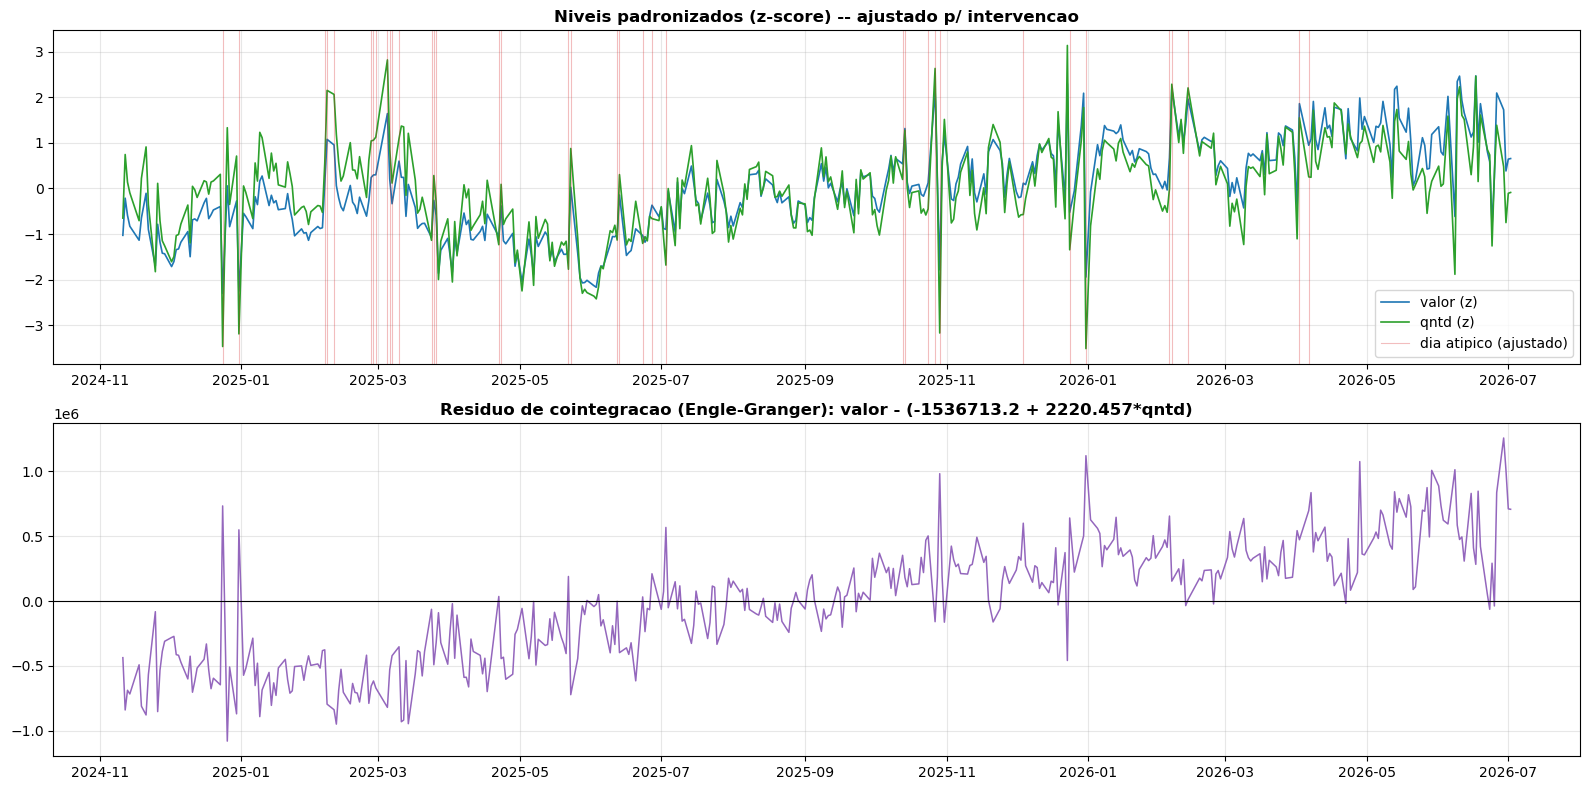

{'p_eg': np.float64(0.9563754055796039),
 'beta': 2220.456898606906,
 'resid': data
 2024-11-11   -437546.34
 2024-11-12   -841357.12
 2024-11-13   -689190.35
 2024-11-14   -717861.68
 2024-11-18   -492562.92
                 ...    
 2026-06-26    836783.54
 2026-06-29   1258638.10
 2026-06-30   1009368.93
 2026-07-01    711468.96
 2026-07-02    708188.56
 Length: 410, dtype: float64,
 'ticket': data
 2024-11-11   1447.75
 2024-11-12   1451.10
 2024-11-13   1441.62
 2024-11-14   1405.94
 2024-11-18   1419.32
                ...  
 2026-06-26   2010.77
 2026-06-29   2127.39
 2026-06-30   2010.94
 2026-07-01   1921.89
 2026-07-02   1921.46
 Length: 410, dtype: float64,
 'n_dias_atipicos_ajustados': 37}

In [390]:
analise_cointegracao(serie_v, serie_q, nomes=('valor', 'qntd'))

In [ ]:
def etl_pipeline():
    spark.conf.set("spark.sql.session.timeZone", "UTC")
    
    tz_sp = timezone(timedelta(hours=-3))
    hj = datetime.now(tz_sp)
    hj_str = hj.strftime('%Y-%m-%d')

    dim_calendario = spark.table("clickhouse.mis_s3.dim_calendario")
    
    row = dim_calendario.filter(
            (F.col("data") < F.to_date(F.lit(hj_str))) &
            (F.col("feriado") == 0) &
            (F.col("numerosemanadia") != 1)
        ) \
        .orderBy(F.col("data").desc()) \
        .select("data") \
        .first()
    data_referencia = row["data"]
    data_min = data_referencia - timedelta(days=45)

    data_referencia_str = data_referencia.strftime('%Y-%m-%d')
    data_min_str = data_min.strftime('%Y-%m-%d')

    # === DATAFRAME 1: Propostas (Ingestão e Agrupamento da Etapa 16) ===
    ft_proposta = spark.table("clickhouse.crefaz.ft_proposta")

    ft_proposta = ft_proposta.filter(
        (F.col("propostaetapaid") == 16) &
        (F.col("propostadecisaoid").isNull()) &
        (F.col("ultimaalteracao").cast("date").between(
            F.date_sub(F.current_date(), 55),
            F.date_sub(F.current_date(), 1)
        ))
    )

    interval_expr = F.to_timestamp(
        F.from_unixtime((F.unix_timestamp("ultimaalteracao") / 900).cast("long") * 900)
    ).alias("Intervalo")

    ft_proposta = ft_proposta.groupBy(interval_expr).agg(
        F.sum("valor").alias("valor"),
        F.count("propostaid").alias("qntd")
    )

    ft_proposta = ft_proposta.withColumn(
        "data_hora",
        F.to_timestamp(F.split(F.col("Intervalo").cast("string"), "\\+").getItem(0))
    ).withColumn(
        "data",
        F.to_date("data_hora")
    )

    ft_proposta = ft_proposta.filter(
        (F.col("data") <= F.to_date(F.lit(data_referencia_str))) &
        (F.col("data") > F.to_date(F.lit(data_min_str)))
    )

    ft_proposta = ft_proposta.groupBy("data").agg(
        F.sum("qntd").alias("qntd"),
        F.sum("valor").alias("valor")
    )

    ft_proposta = ft_proposta.withColumn("qntd", F.col("qntd").cast("integer"))

    # === DATAFRAME 2: Fila (Quantidade de Propostas na Etapa 15) ===
    dbo_propostastatushistorico = spark.table("clickhouse.crefazon15m.dbo_propostastatushistorico")

    dbo_propostastatushistorico = dbo_propostastatushistorico.filter(
        (F.col("data") > F.date_sub(F.current_date(), 65)) &
        (F.col("data") < F.current_date())
    )

    dbo_propostastatushistorico = dbo_propostastatushistorico.groupBy(
        "propostaid",
        F.to_date("data").alias("Data")
    ).agg(
        F.max(F.struct("data", "id", "propostaetapaid")).alias("max_struct")
    ).select(
        "Data",
        "propostaid",
        F.col("max_struct.propostaetapaid").alias("etapa")
    )

    dbo_propostastatushistorico = dbo_propostastatushistorico.filter(F.col("etapa") == 15) \
                    .groupBy("Data") \
                    .agg(F.count("propostaid").alias("QUANTIDADE"))

    dbo_propostastatushistorico = dbo_propostastatushistorico.withColumnRenamed("Data", "data")

    # === JOIN: Cruzamento dos dados de Propostas (DF 1) com o Histórico de Fila (DF 2) ===
    df_merged = ft_proposta.join(dbo_propostastatushistorico, on="data", how="left")

    # Mesma tabela (cálculo dos lags de predição, sem lag fictício em lag_0, lag_1 e lag_7) -> mantém o nome
    window_spec = Window.orderBy("data")
    df_merged = df_merged \
        .withColumn("lag_0", F.col("qntd")) \
        .withColumn("lag_1", F.col("valor")) \
        .withColumn("lag_2", F.lag("valor", 1).over(window_spec)) \
        .withColumn("lag_3", F.lag("valor", 2).over(window_spec)) \
        .withColumn("lag_4", F.lag("valor", 3).over(window_spec)) \
        .withColumn("lag_5", F.lag("valor", 4).over(window_spec)) \
        .withColumn("lag_6", F.lag("valor", 5).over(window_spec)) \
        .withColumn("lag_7", F.col("QUANTIDADE"))

    df_merged = df_merged.dropna().orderBy("data").drop('data', 'qntd', 'valor', 'QUANTIDADE')

    return df_merged.toPandas()

def model_construct():
    # === load model ===
    path_model = 's3://crefaz-temp-sa-east-1-794038227804-hml/engdados/felipe_zandonadi/projects/modelo_treinado-2026-05-26.pkl'

    if path_model.startswith("s3://"):
        parsed_url = urlparse(path_model)
        bucket_name = parsed_url.netloc
        model_key = parsed_url.path.lstrip("/")

        s3_client = boto3.client("s3")
        response = s3_client.get_object(Bucket=bucket_name, Key=model_key)
        model = joblib.load(io.BytesIO(response["Body"].read()))
    else:
        model = joblib.load(path_model)

    return model

def ml_pipeline(model, df):
    # Seleciona o registro mais recente (ontem)
    ultima_linha = df.tail(1).copy()

    # O dia_semana para a predição deve ser o dia de HOJE
    tz_sp = timezone(timedelta(hours=-3))
    hoje = datetime.now(tz_sp)
    ultima_linha['dia_semana'] = hoje.weekday()  # Monday=0, Sunday=6

    # Garante a ordem exata das features esperada pelo modelo
    cols_model = ['dia_semana', 'lag_0', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7']
    ultima_linha = ultima_linha[cols_model]

    prediction = model.predict(ultima_linha)

    return prediction[0]


 

## 3 - AREA VALOR

### 3.A Estimação

In [307]:
serie_v

data
2024-11-11   3699007.83
2024-11-12   4485361.95
2024-11-13   4120162.26
2024-11-14   3891649.81
2024-11-18   3595141.20
                ...    
2026-06-26   6711955.47
2026-06-29   6356650.11
2026-06-30   5061545.74
2026-07-01   5312098.63
2026-07-02   5324361.42
Name: valor, Length: 410, dtype: float64

Ordem (auto_arima, univariado): SARIMA(0, 1, 1) x (0, 0, 2, 5)  | AIC=12054.0
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7908      0.030    -26.167      0.000      -0.850      -0.732
ma.S.L5       -0.1066      0.045     -2.355      0.019      -0.195      -0.018
ma.S.L10      -0.0735      0.055     -1.328      0.184      -0.182       0.035
sigma2      3.519e+11   4.38e-14   8.03e+24      0.000    3.52e+11    3.52e+11


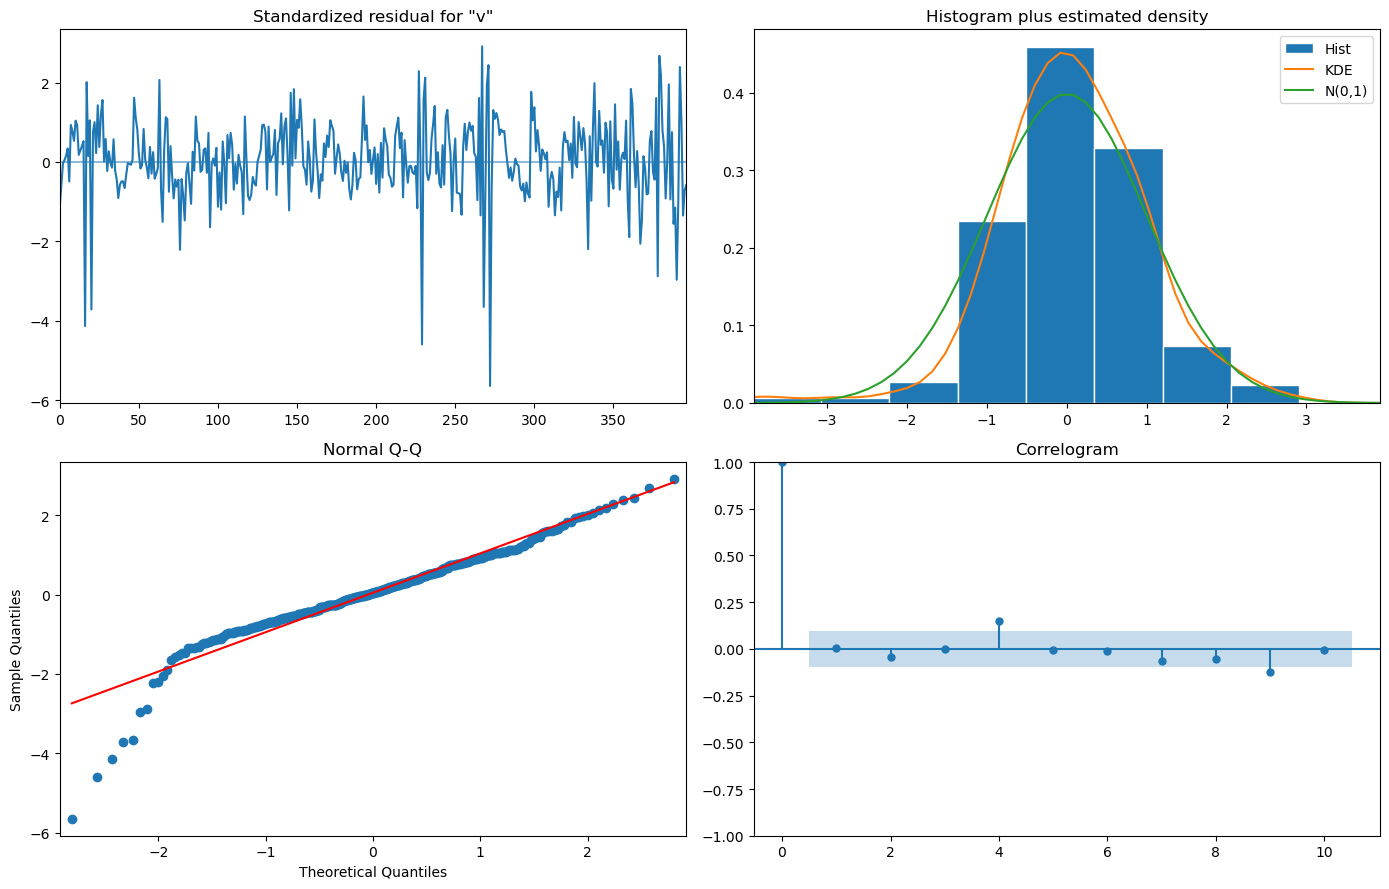

Ljung-Box (H0 = residuos sem autocorrelacao):
    lb_stat  lb_pvalue
10    18.01       0.05
20    39.91       0.01


In [308]:
order_v, seas_v, aic_v = selecionar_ordem(serie_v)
print(f'Ordem (auto_arima, univariado): SARIMA{order_v} x {seas_v}  | AIC={aic_v:.1f}')
res_v = ajustar_sarimax(serie_v, order_v, seas_v, None)
print(res_v.summary().tables[1])
try:
    res_v.plot_diagnostics(figsize=(14, 9)); plt.tight_layout(); plt.show()
except Exception as e:
    print('diagnostics:', e)
print('Ljung-Box (H0 = residuos sem autocorrelacao):')
print(acorr_ljungbox(res_v.resid, lags=[10, 20], return_df=True))

### Analise de intervencao (efeito por evento + residuo pre/pos)

Efeito dos **dias especiais** (eventos do `Log_Erro` e vesperas de feriado) sobre a serie de
valor, via **regressores de intervencao** (Box-Tiao) ja montados acima. Cada evento e
classificado em **abrupto** (efeito transitorio, constante nos dias de impacto) ou **gradual**
(efeito decaindo ao longo da janela de impacto), escolhendo por significancia (p<0.05) e menor
AIC; sem efeito significativo -> `nao signif.`. Abaixo: tabela por evento, barra de efeito
(SARIMAX) e comparacao do **residuo PRE x POS** intervencao (ajuste SARIMA univariado).

=== Analise classica: Valor (R$) | n=410 | 2024-11-11 -> 2026-07-02 ===


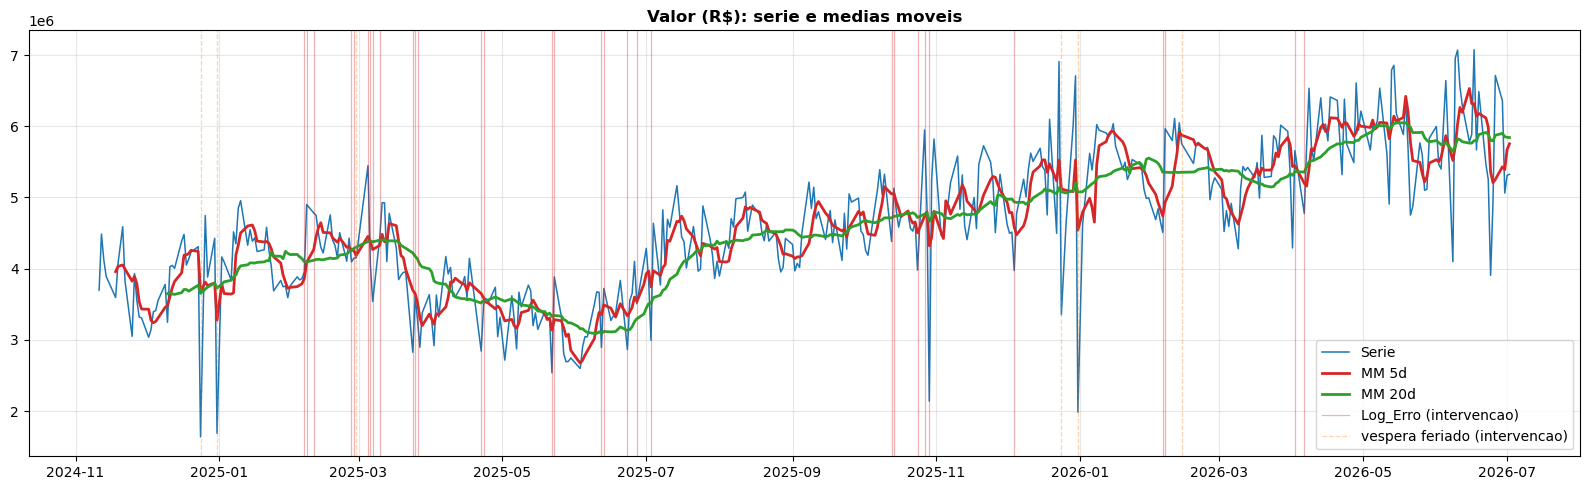

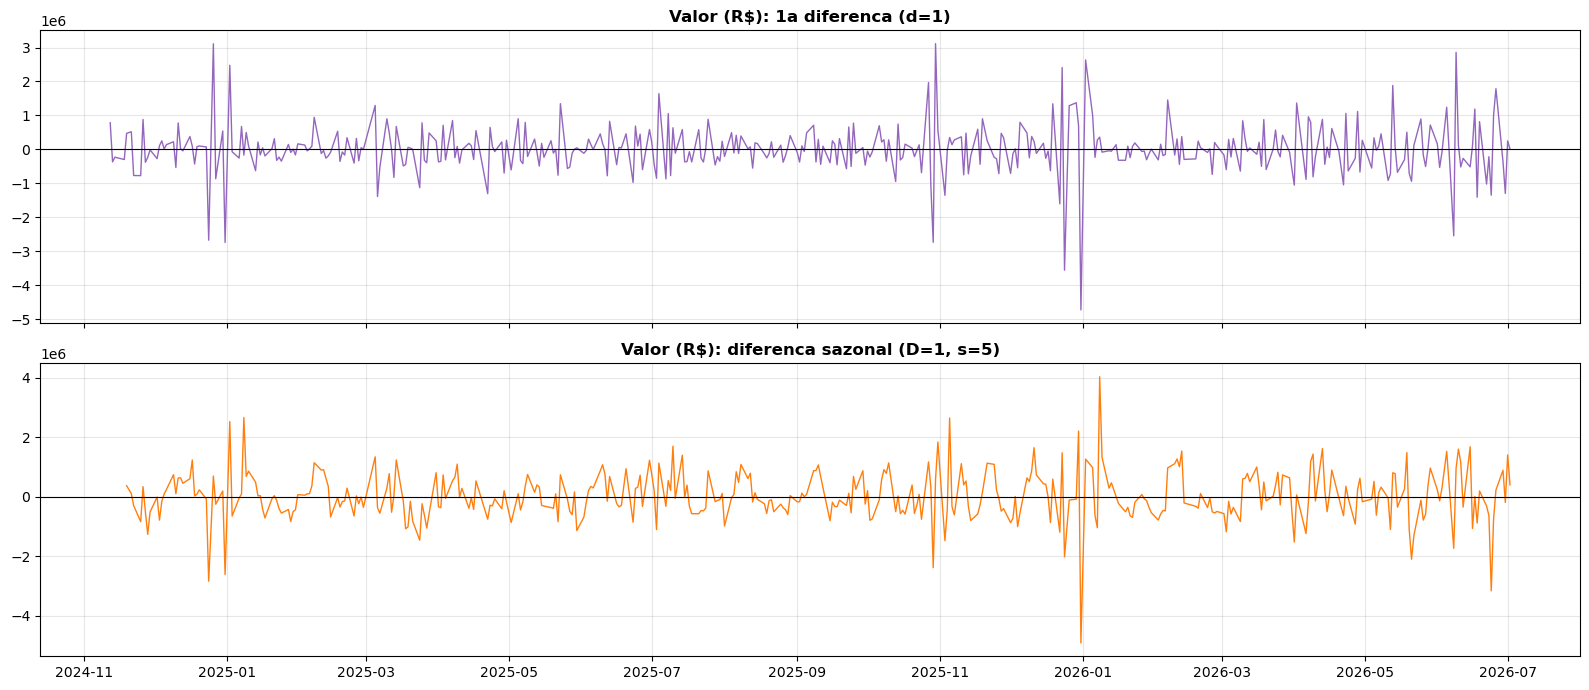

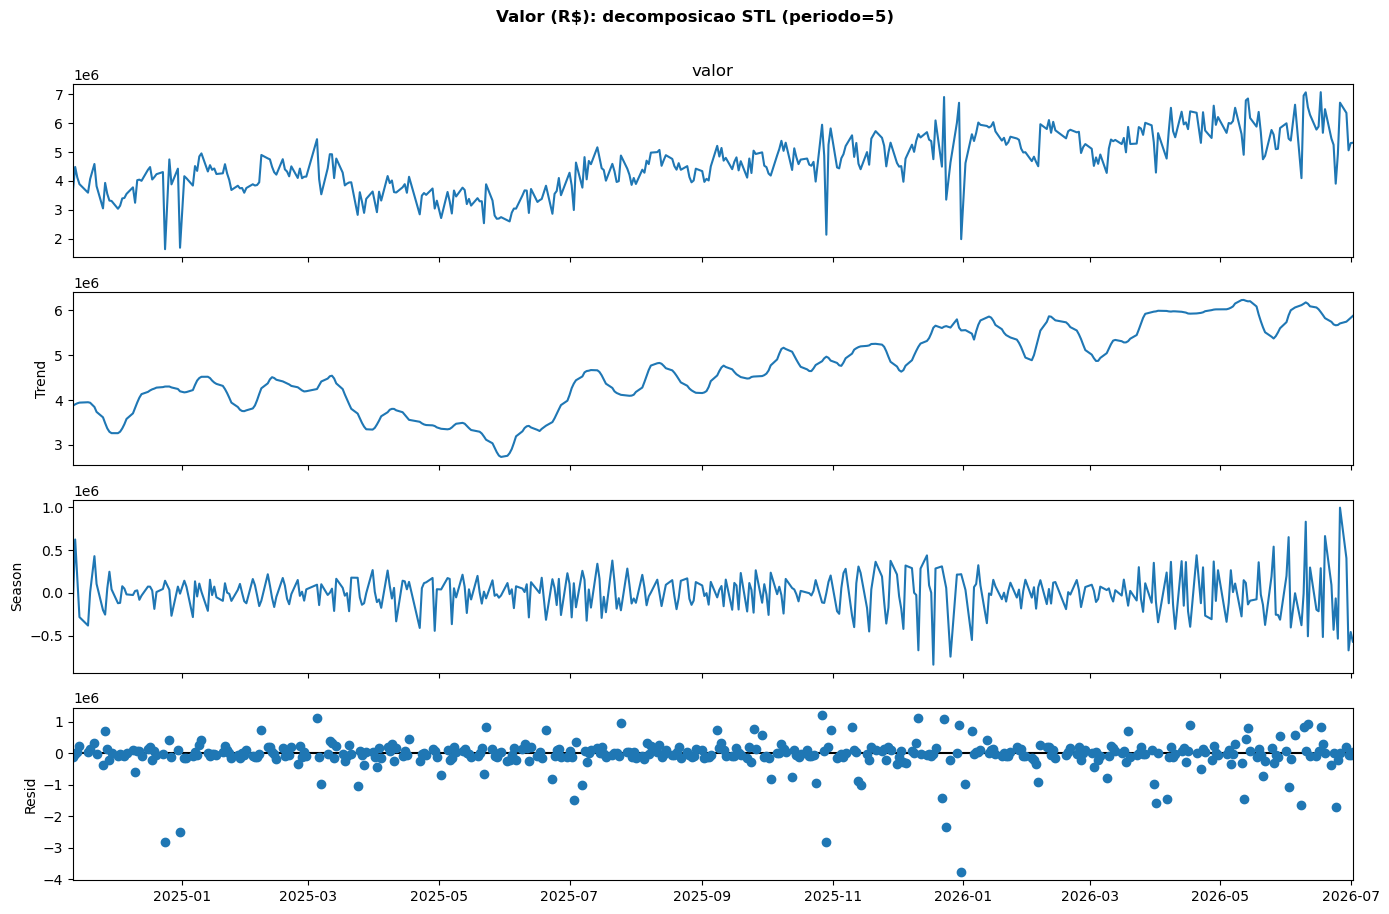

Estacionariedade (ADF H0=raiz unitaria | KPSS H0=estacionaria) -- ADF bruto x ajustado p/ intervencao (37 dias atipicos: Log_Erro + vespera Natal/AnoNovo/Carnaval):
  nivel              ADF bruto p=0.8322 (NAO estac.)  |  ADF ajustado p=0.0598 (NAO estac.)  |  KPSS (bruto) p=0.0100 (NAO estac.)
  1a diferenca       ADF bruto p=0.0000 (estacionaria)  |  ADF ajustado p=0.0000 (estacionaria)  |  KPSS (bruto) p=0.1000 (estacionaria)
  diff sazonal(5)    ADF bruto p=0.0000 (estacionaria)  |  ADF ajustado p=0.0000 (estacionaria)  |  KPSS (bruto) p=0.1000 (estacionaria)


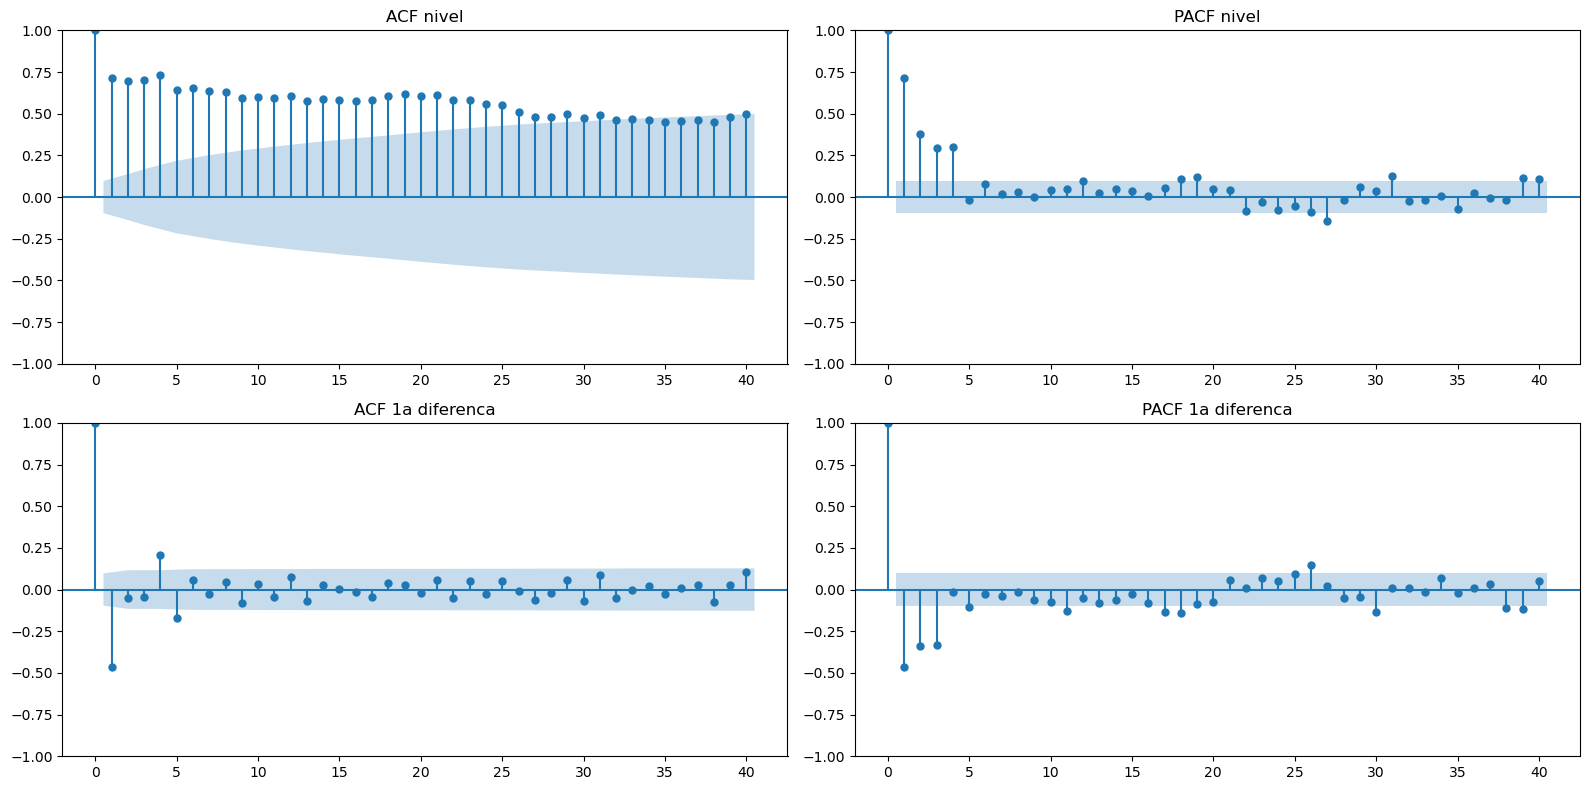

[cache hit] analise_intervencao <- analise_intervencao_7af28be57aa21e70.pkl
[cache hit] analise_intervencao <- analise_intervencao_bc76be301fc3e1c3.pkl

Valor (R$) | SARIMA {'abrupto': 6, 'gradual': 6, 'nao signif.': 4, 'rebote': 2} -> 16 regressores | SARIMAX {'gradual': 7, 'abrupto': 5, 'nao signif.': 4, 'rebote': 2} -> 16 regressores

Tabela de intervencao -- Valor (R$) / SARIMAX:


,Evento,Tipo,Inicio,n_dias,Impacto/dias,coef_abrupto,p_abrupto,AIC_abrupto,coef_gradual,p_gradual,AIC_gradual,coef_rebote_dia1,coef_rebote_pos,p_rebote_dia1,p_rebote_pos,AIC_rebote,Classe
0,vespera relevante Natal/AnoNovo/Carnaval (n=6),vespera,2024-12-24,6,1,-2003258.00,0.00,11618.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,abrupto
1,BrSCAM (2025-02-06),log_erro,2025-02-06,3,3,54402.40,0.91,11682.30,-153105.30,0.83,11682.90,-222891.20,331171.00,0.04,0.59,11682.90,nao signif.
2,CrefazOn (2025-02-26),log_erro,2025-02-26,2,2,48626.50,0.95,11682.60,16976.80,0.00,11682.50,17038.60,80245.30,0.00,0.00,11684.60,gradual
3,Carnaval (2025-03-05),log_erro,2025-03-05,2,2,1118150.00,0.00,11680.30,1771447.00,0.01,11678.00,1771394.90,472516.00,0.03,0.44,11678.10,gradual
4,Bacen - Fila Pagamento (2025-03-07),log_erro,2025-03-07,2,2,-512873.30,0.27,11681.00,-904844.10,0.00,11680.10,-904533.40,-119295.50,0.00,0.00,11681.70,gradual
5,Enel - Mega (2025-03-24),log_erro,2025-03-24,3,3,-359552.50,0.25,11681.00,-926912.20,0.12,11679.90,-920272.50,198444.10,0.18,0.64,11681.90,nao signif.
6,CrefazOn (2025-04-22),log_erro,2025-04-22,2,2,-670331.20,0.23,11681.60,-1141361.40,0.00,11680.70,-1141415.50,-205314.30,0.00,0.00,11681.70,gradual
7,Kamunda- Enel (2025-05-22),log_erro,2025-05-22,2,2,-186022.40,0.65,11682.70,-848465.70,0.00,11683.20,-849076.80,477231.40,0.00,0.00,11682.20,rebote
8,Unico - CrefazOn (2025-06-12),log_erro,2025-06-12,2,2,-280611.10,0.71,11682.20,-689536.90,0.00,11682.20,-690086.10,129050.70,0.00,0.00,11683.70,gradual
9,Code-Mega (2025-06-23),log_erro,2025-06-23,1,1,-794735.30,0.00,11680.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,abrupto


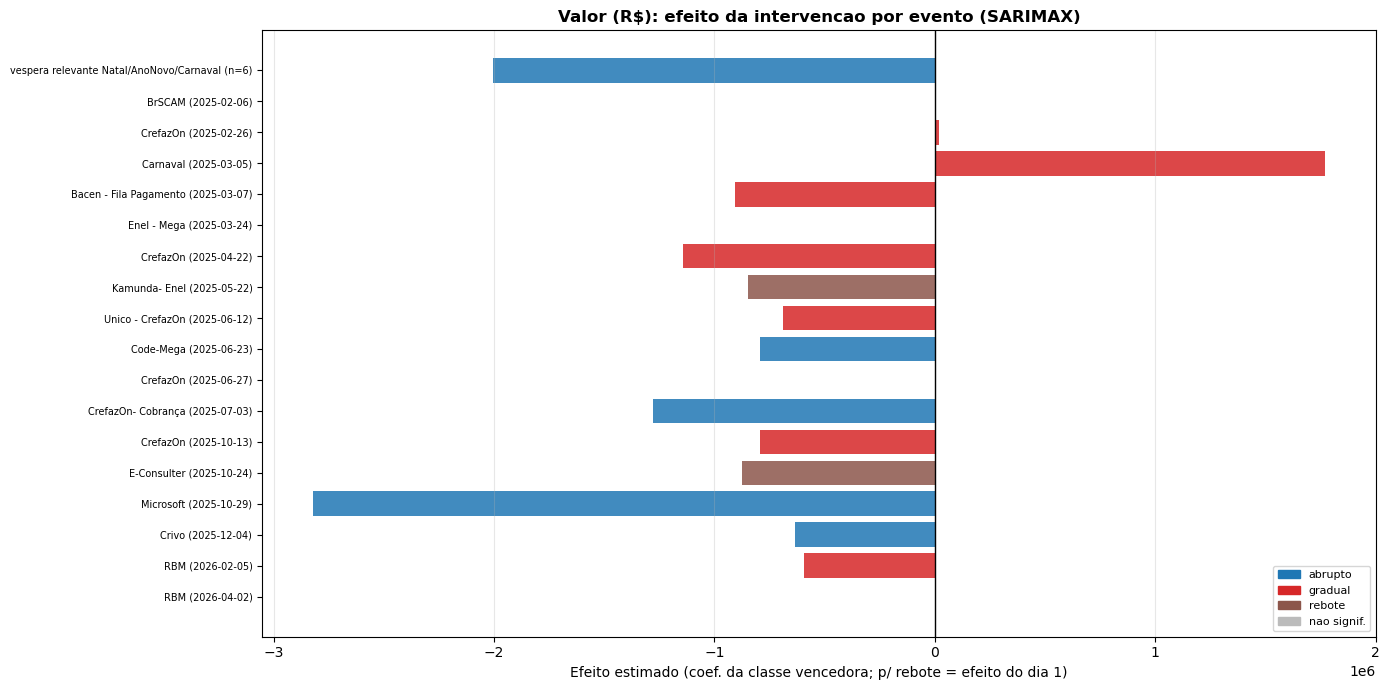

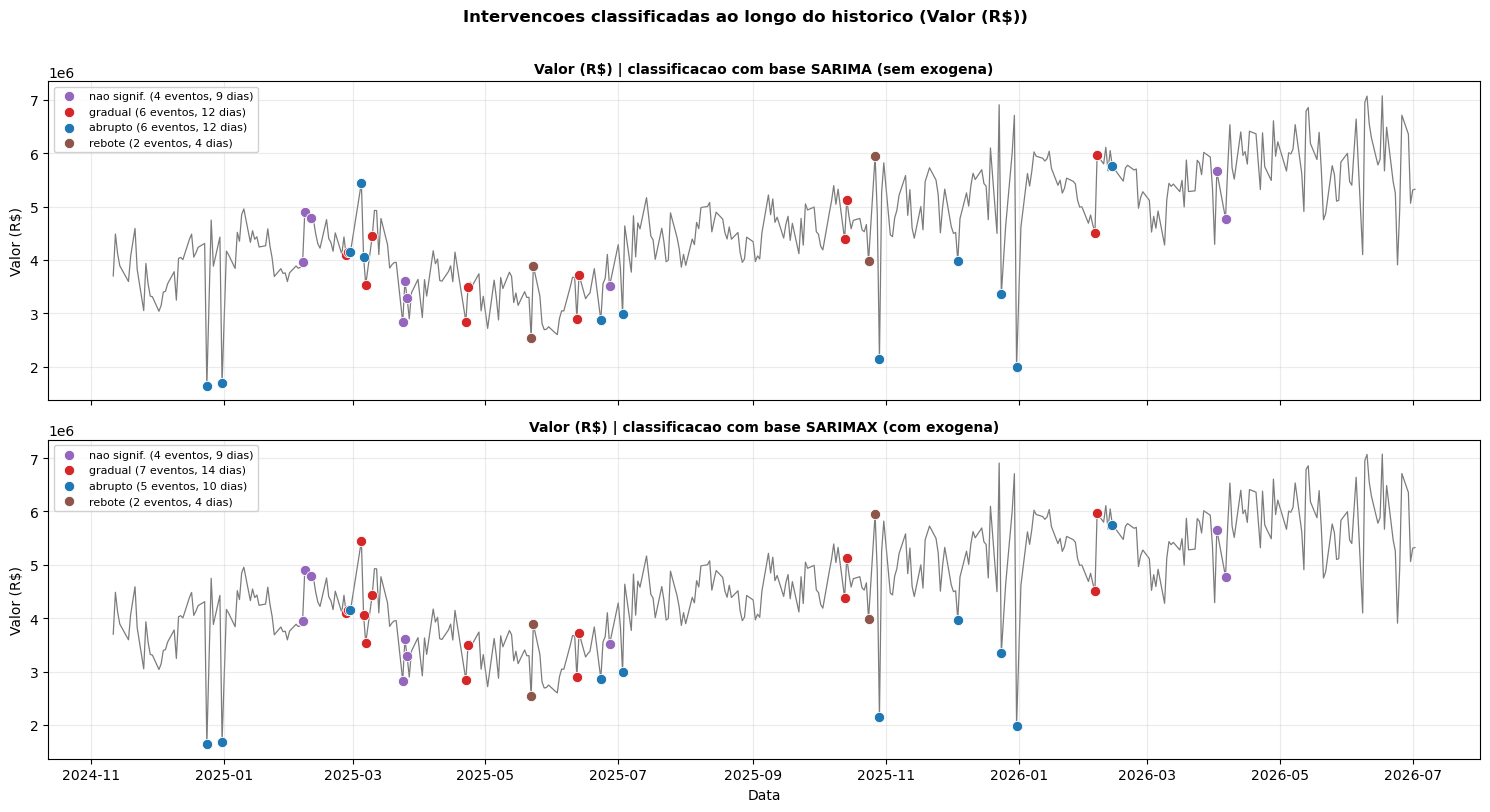

RESIDUO PRE x POS INTERVENCAO -- Valor (R$) -- SARIMA


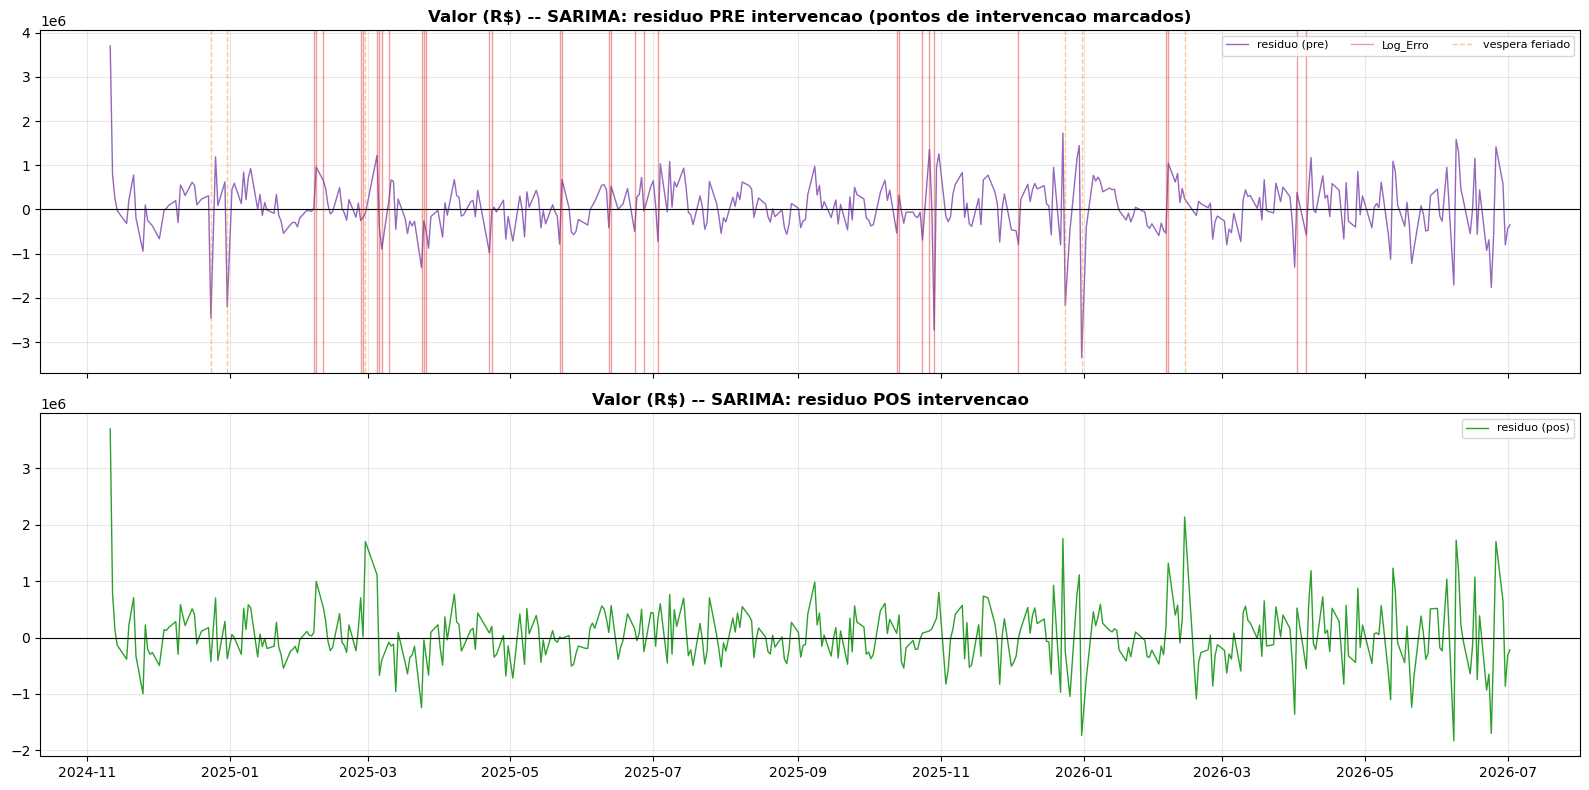

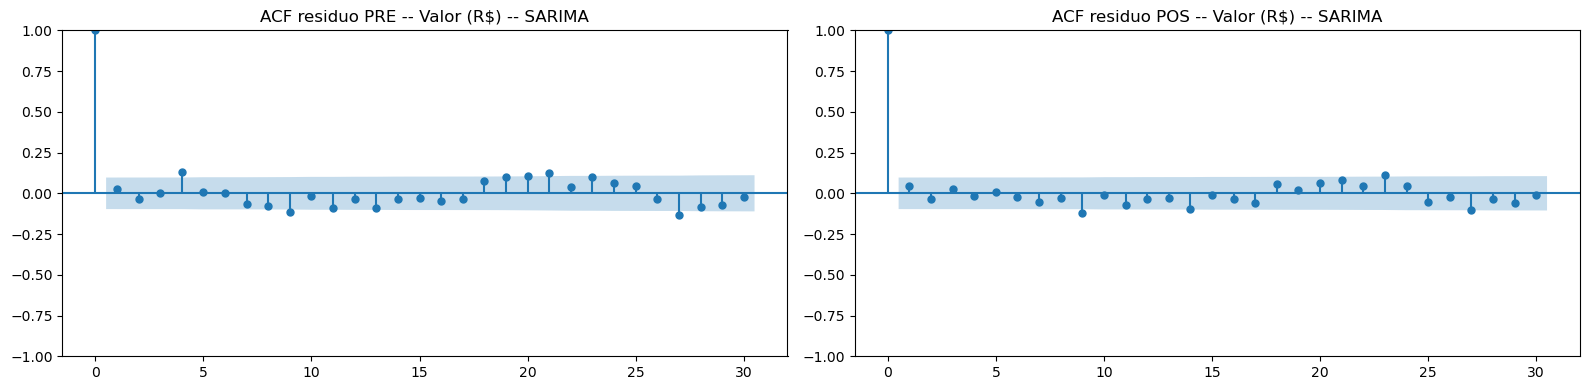

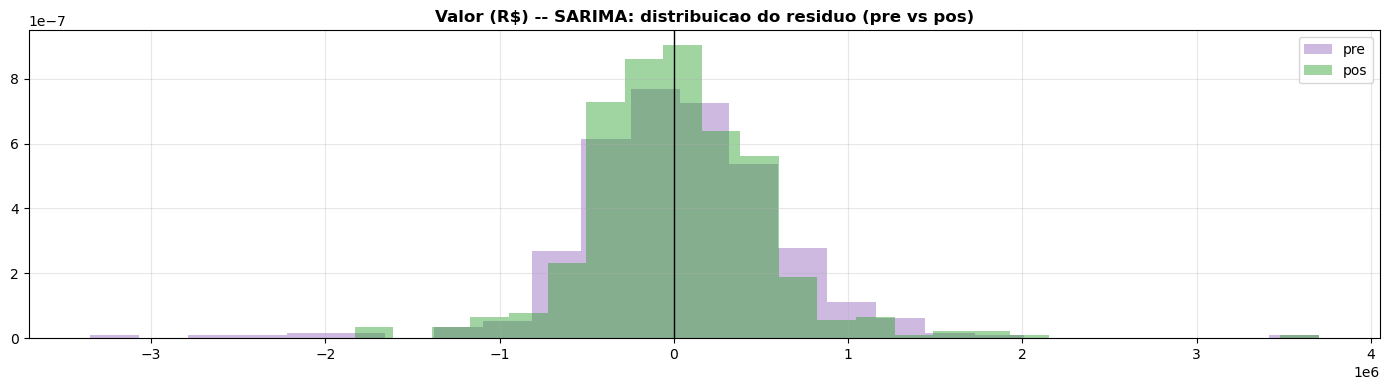

Resumo do residuo (pre vs pos):


,Modelo,n,AIC,BIC,DP residuo,MAE residuo,LB p(10),LB p(20),JB p (normal.)
0,PRE (sem intervencao),410,11684.90,11700.90,612732.53,432833.50,0.05,0.01,0.00
1,POS (com intervencao),410,11590.10,11669.70,533013.73,382901.42,0.50,0.37,0.00


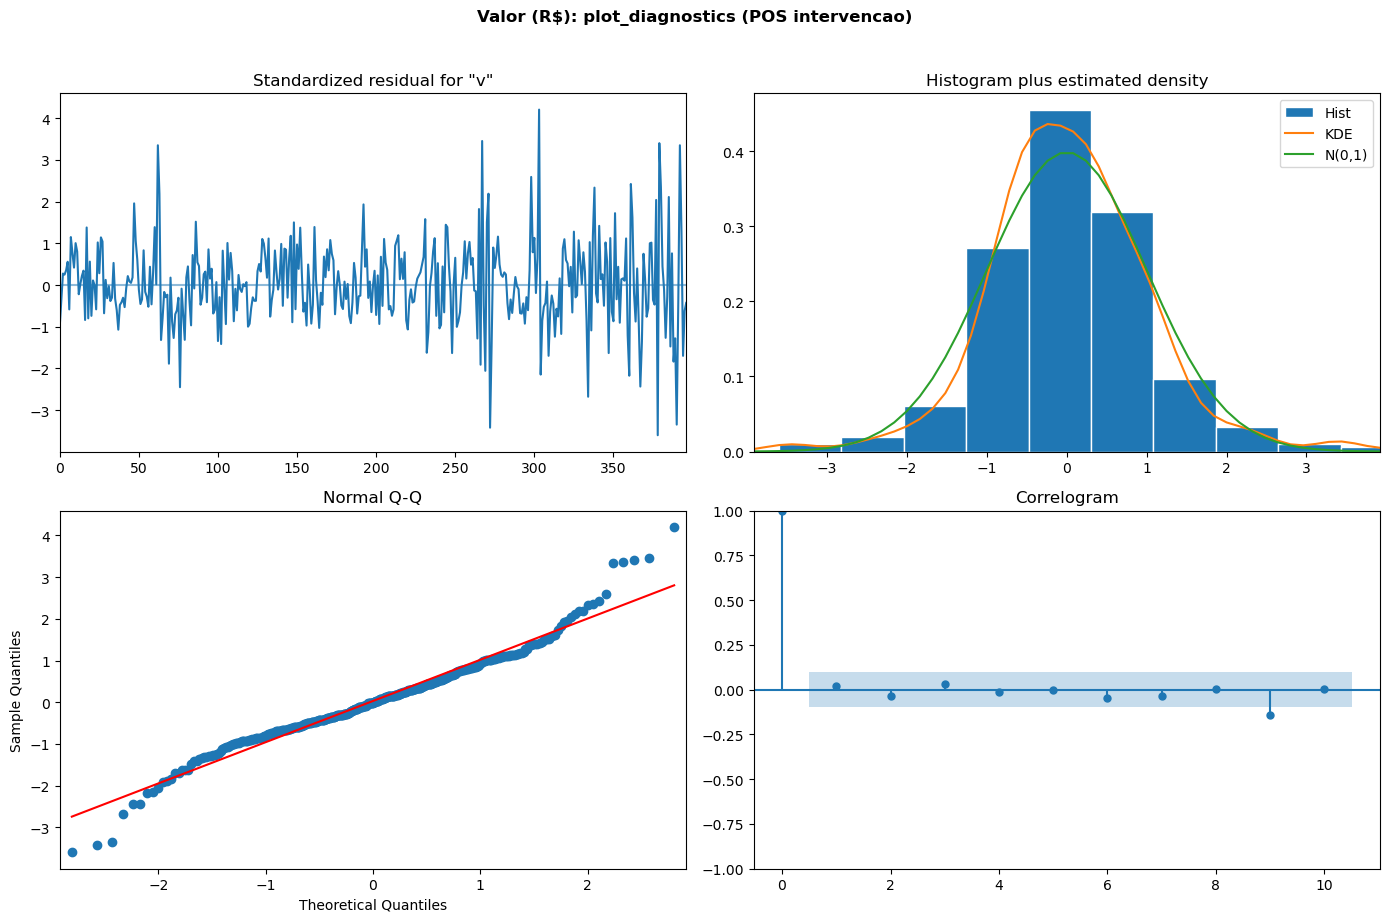


Ljung-Box (POS intervencao) -- Valor (R$) (H0 = residuos sem autocorrelacao):
    lb_stat  lb_pvalue
10     9.39       0.50
20    21.47       0.37


In [309]:
# ===== Analise classica + intervencao -- VALOR =====
# analise_classifica_intervencao junta: (1) analise classica (medias moveis, STL, ADF/KPSS,
# ACF/PACF), (2) classificacao da intervencao por evento -- SARIMA e SARIMAX -- + onde cada
# uma cai no historico, e (3) residuo PRE (sem intervencao) x POS (com intervencao). As
# matrizes X_int_* seguem sendo usadas na avaliacao (Secao 3) e na correcao de vies.
resultado_v = analise_classifica_intervencao(serie_v, order_v, seas_v, eventos_v,
                                             nome='Valor (R$)', exog=exog_v, res_pre=res_v)
interv_sarima_v,  classes_sarima_v,  X_int_sarima_v  = (resultado_v['interv_sarima'],
                                                        resultado_v['classes_sarima'], resultado_v['X_int_sarima'])
interv_sarimax_v, classes_sarimax_v, X_int_sarimax_v = (resultado_v['interv_sarimax'],
                                                        resultado_v['classes_sarimax'], resultado_v['X_int_sarimax'])

In [310]:
print(res_v.summary().tables[0])

                                       SARIMAX Results                                        
Dep. Variable:                                  valor   No. Observations:                  410
Model:             SARIMAX(0, 1, 1)x(0, 0, [1, 2], 5)   Log Likelihood               -5838.467
Date:                                sex, 03 jul 2026   AIC                          11684.935
Time:                                        10:31:17   BIC                          11700.870
Sample:                                             0   HQIC                         11691.247
                                                - 410                                         
Covariance Type:                                  opg                                         


In [ ]:
_df_db_valor, ranking_valor = avaliar_area(
    'valor', serie_v, exog_v, order_v, seas_v,
    'resultados/backup_valor.xlsx', 'Dia Referência', dfull_v,
    exog_int_u=X_int_sarima_v, exog_int_x=X_int_sarimax_v,
    eventos=eventos_v, interv_lr=interv_sarima_v)   # inclui LOG-RETORNO no ranking
print('\nRanking VALOR (ordenado por RMSPE):')
display(_com_modelo(ranking_valor))

### 3.E - Outras funcoes de transferencia (Box-Tiao): testando formas alternativas de intervencao

A analise de intervencao acima (`analise_intervencao`) so testa 3 formas de resposta ao
evento: abrupto (constante, retorno imediato a zero), gradual (decaimento LINEAR dentro da
janela de impacto) e rebote (bifasico). A literatura classica de intervencao (Box & Tiao,
1975) descreve a resposta a um indicador `I_t` (o mesmo indicador do "abrupto": 1 nos dias de
impacto do evento, 0 fora) como um operador racional `omega(B)/delta(B)` aplicado a `I_t`.
Testamos aqui as formas QUE NAO estao cobertas pelo par abrupto/gradual/rebote -- coeficientes
`omega` estimados por SARIMAX, parametro livre `delta` (decaimento geometrico, 0<delta<1)
escolhido por grid-search (menor AIC):

- **(a) Abrupto** `omega0 * I_t` -- efeito constante enquanto dura o evento, retorno abrupto a
  zero no fim (ja calculado em `analise_intervencao`; reaproveitado aqui so para comparacao no
  mesmo quadro).
- **(b) Pulso atrasado com decaimento** `(omega0*B)/(1-delta*B) * I_t` -- o efeito NAO aparece
  no(s) proprio(s) dia(s) do evento; comeca no dia UTIL seguinte com magnitude `omega0` e decai
  geometricamente (`x delta` a cada dia) ate se dissipar. Util quando o impacto e sentido com 1
  dia de atraso (ex.: erro que so aparece no backlog processado no dia seguinte).
- **(c) Degrau permanente** `omega0/(1-B) * I_t` -- a partir do 1o dia do evento a serie sobe
  (ou desce) para um NOVO NIVEL que persiste indefinidamente, sem retornar a media. Captura uma
  mudanca estrutural (nao uma perturbacao temporaria).
- **(d) Decaimento + degrau** `(omega0/(1-delta*B) + omega1/(1-B)) * I_t` -- combina um pico
  que decai geometricamente a partir do proprio dia do evento (`omega0`) com um degrau
  permanente (`omega1`): efeito inicial de `omega0+omega1` que relaxa ate estabilizar em
  `omega1` (a parte transitoria se dissipa, a permanente fica).
- **(e) Pico + decaimento** `(omega0 + omega1/(1-delta*B)) * I_t` -- um salto extra SO no(s)
  dia(s) do proprio evento (`omega0`, igual ao abrupto) somado a um efeito que decai
  geometricamente a partir do mesmo dia e se DISSIPA POR COMPLETO (sem degrau). Diferente do
  "gradual" (decaimento linear e finito, limitado a janela de impacto do evento), aqui o
  decaimento e geometrico e pode se estender alem da janela.
- **(f) Convergencia gradual** `omega0/((1-delta*B)*(1-B)) * I_t` -- em vez de saltar
  imediatamente para o novo nivel (como o degrau), o efeito CRESCE progressivamente dia a dia
  ate convergir, de forma suave, a um novo nivel permanente `omega0/(1-delta)`. E o analogo
  "suavizado" do degrau (c).

Classificacao: para cada evento, o candidato com menor AIC entre os SIGNIFICATIVOS (p<0.05 em
todos os coeficientes da funcao) vence; sem nenhum significativo -> `nao signif.`. Empate ->
funcao mais simples primeiro (a > c > b > f > d > e).


In [ ]:
# ===== Outras funcoes de transferencia (Box-Tiao) -- VALOR =====
interv_trf_v = analise_transferencia(serie_v, order_v, seas_v, eventos_v, exog=exog_v, verbose=True)
print('\nComparacao: classe (abrupto/gradual/rebote) x funcao vencedora (a-f):')
_comp_v = interv_sarimax_v[['Evento', 'Classe']].merge(
    interv_trf_v[['Evento', 'Classe_vencedora']], on='Evento', how='outer')
display(_comp_v)
display(interv_trf_v)
_plot_transferencia(interv_trf_v, title='VALOR: outras funcoes de transferencia -- efeito por evento')


#### Export das predicoes (p/ import no `experimento_valor`, Secao 4.A)

In [ ]:
# ==================== EXPORT: predicoes SARIMAX (valor) ====================
# Usado pela Secao 4.A do experimento_valor.ipynb para comparar o SARIMAX com os
# modelos de ML nas mesmas condicoes (mesma base comum de datas + remocao de
# Log_Erro/vesperas ja feita la). So a previsao crua e exportada (sem debias).
_export_v = _df_db_valor[_df_db_valor['Modelo'] == 'SARIMAX'][
    ['Dia Prevista', 'Valor Previsto', 'Valor Realizado']
].dropna().sort_values('Dia Prevista').reset_index(drop=True)
_export_v.insert(0, 'Modelo', 'SARIMAX')
os.makedirs('resultados', exist_ok=True)
_export_v.to_pickle(r'resultados\sarimax_valor_predicoes.pkl')
print(f'[export] SARIMAX (valor) -> resultados/sarimax_valor_predicoes.pkl | '
      f'{len(_export_v)} previsoes | '
      f'{_export_v["Dia Prevista"].min().date()} -> {_export_v["Dia Prevista"].max().date()}')


### 3.B - VALOR: comparacao de todos os modelos 

In [ ]:
comparar_todos_modelos(_df_db_valor, ranking_valor, 'Valor das Propostas (R$)', titulo='VALOR 5.C')

### 3.C - VALOR: comparacao individual de cada modelo (estilo 5.D)

In [313]:
# ===== Replica 5.D para a area VALOR =====
_df_db          = _df_db_valor.copy()
df_ranking_int  = ranking_valor.copy()
df_ranking_orig = None
_UNID           = 'Valor das Propostas (R$)'



#### SARIMAX


### 5.D - SARIMAX | Parte 1 - Historico completo


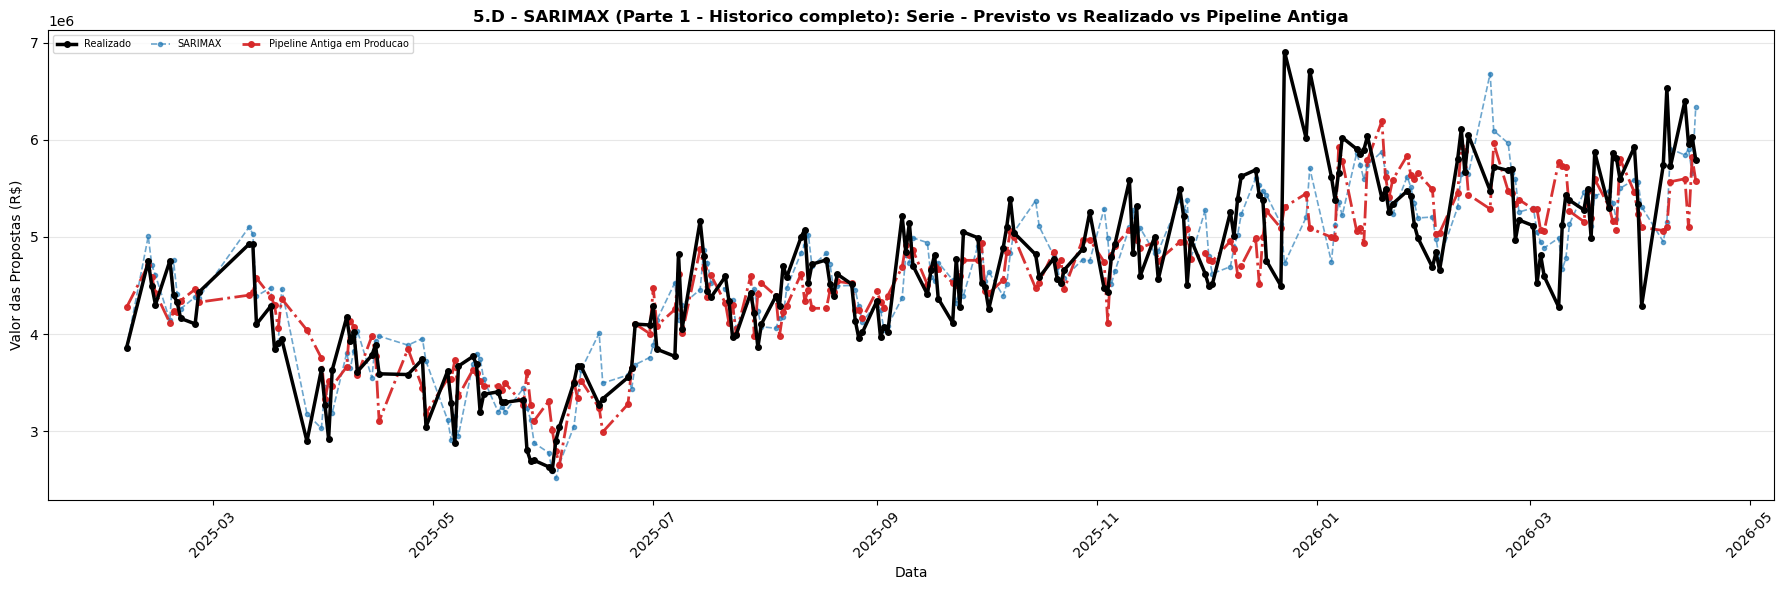

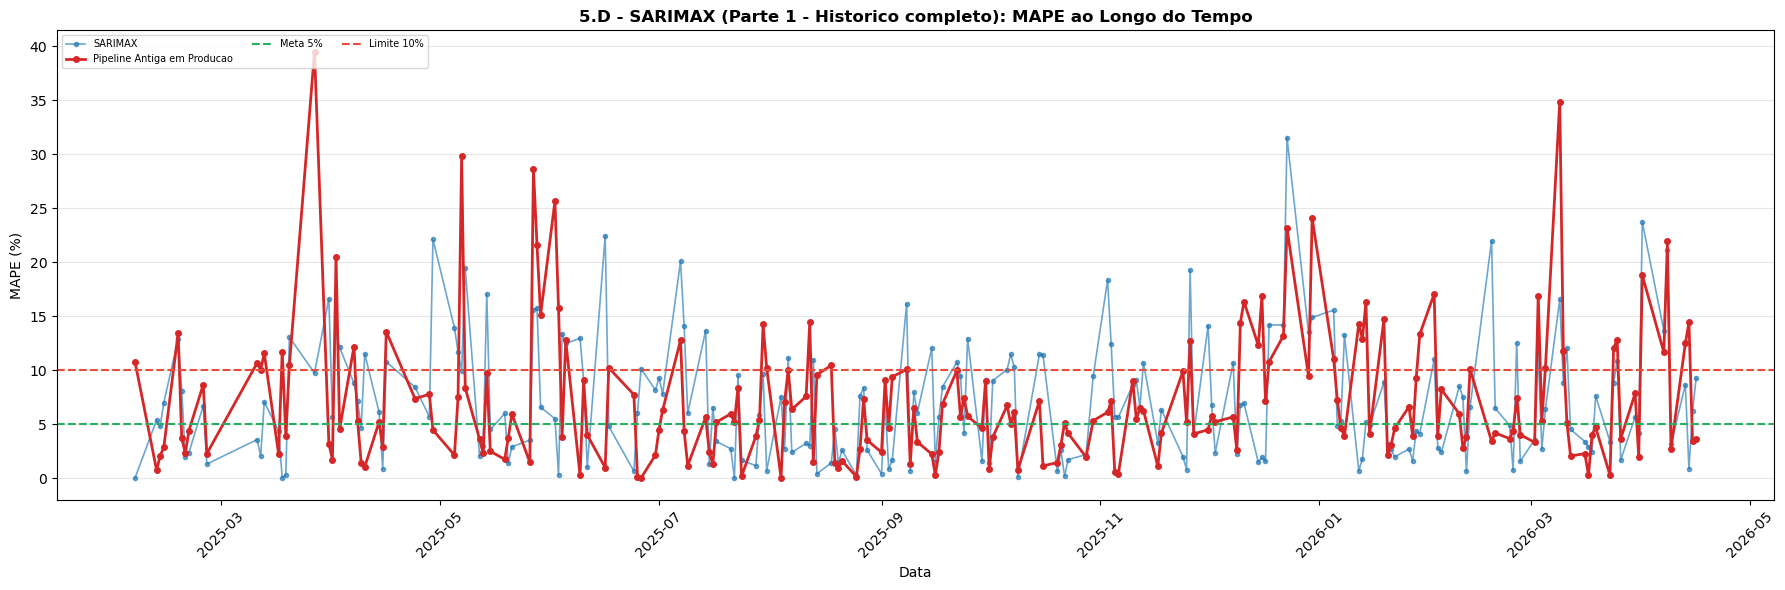

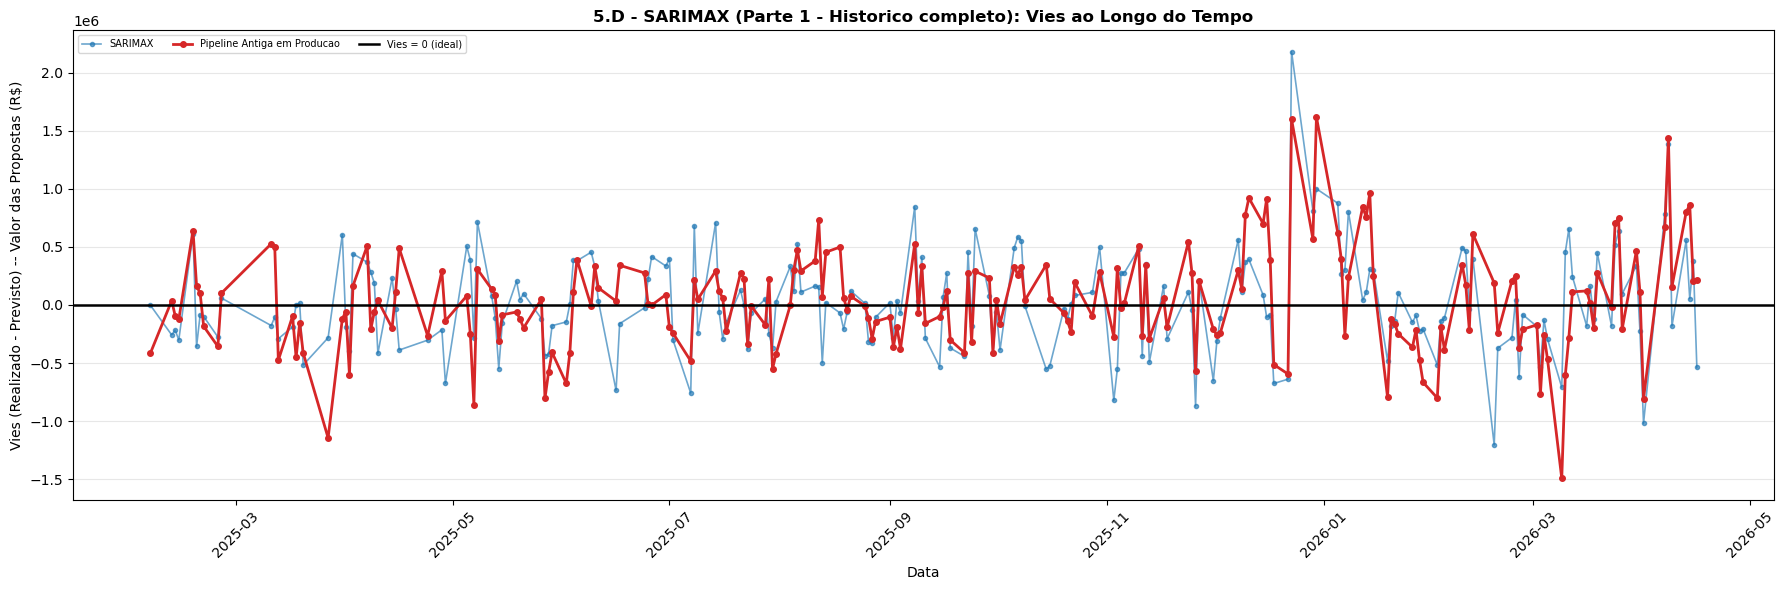


-- Metricas do periodo -- Parte 1 - Historico completo:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SARIMAX,7.09,9.02,0.76,8302.90,8302.90,-0.43,324518.20,426761.20,9.25,6.10,0.01,31.57,91/209,153/209,209
1,Pipeline Antiga em Producao,7.23,9.58,0.74,28437.90,28437.90,-0.33,330068.70,435533.90,9.44,5.35,0.05,39.52,95/209,154/209,209



### 5.D - SARIMAX | Parte 2 - Janeiro em diante


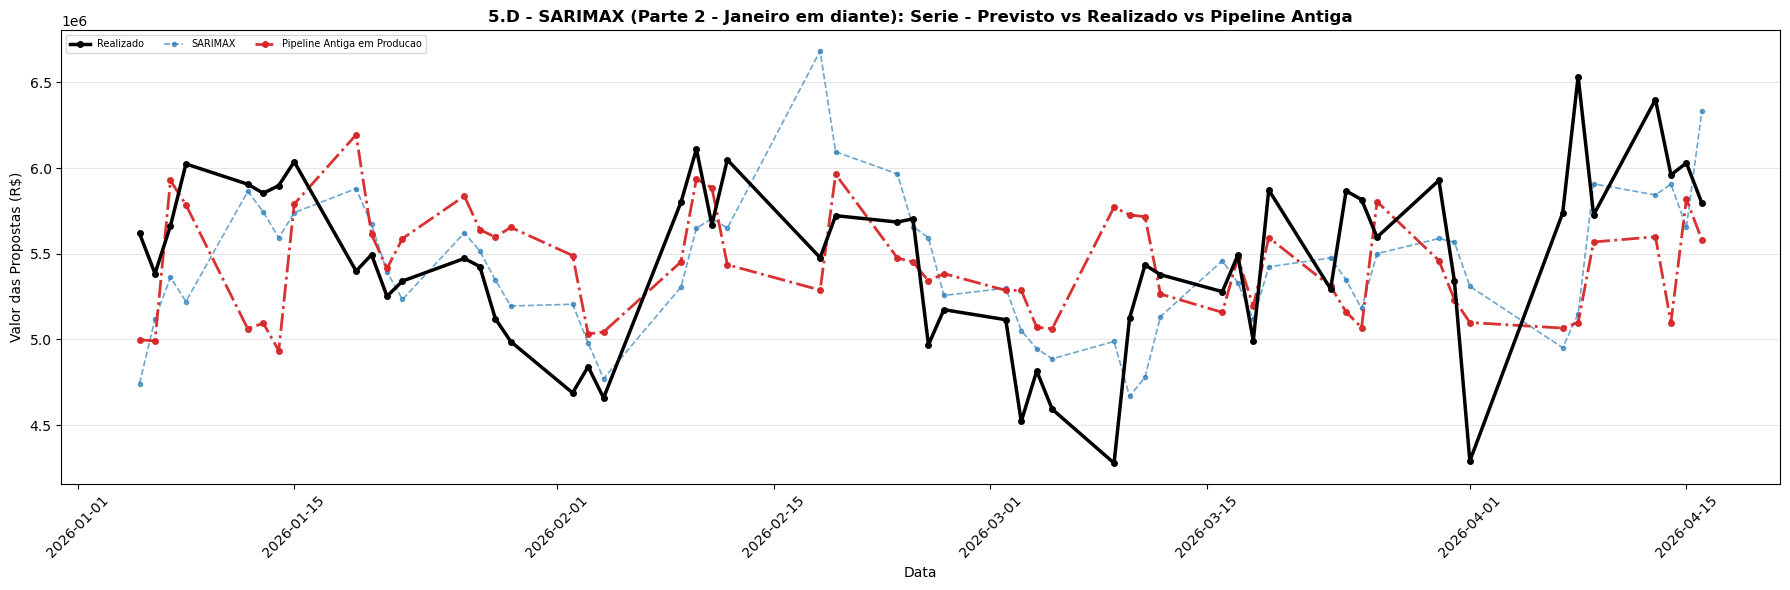

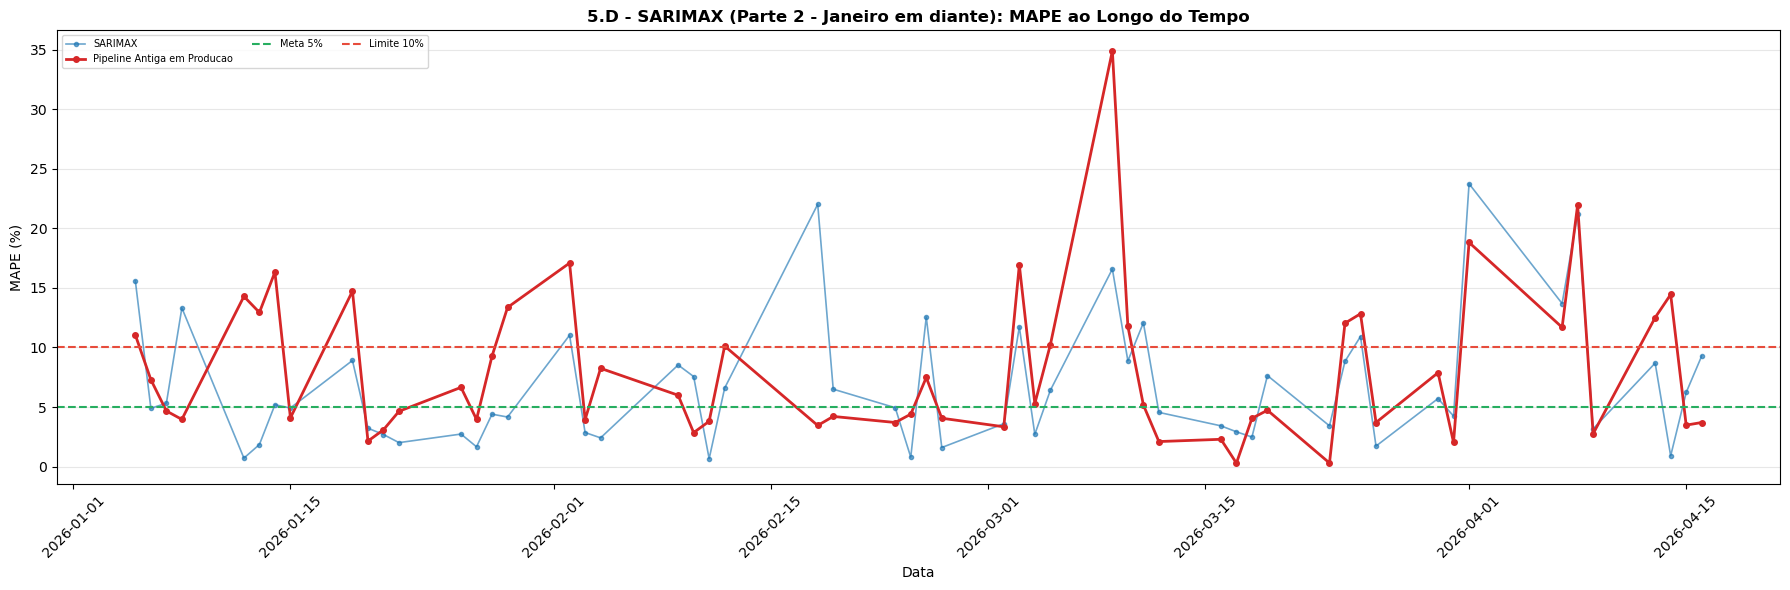

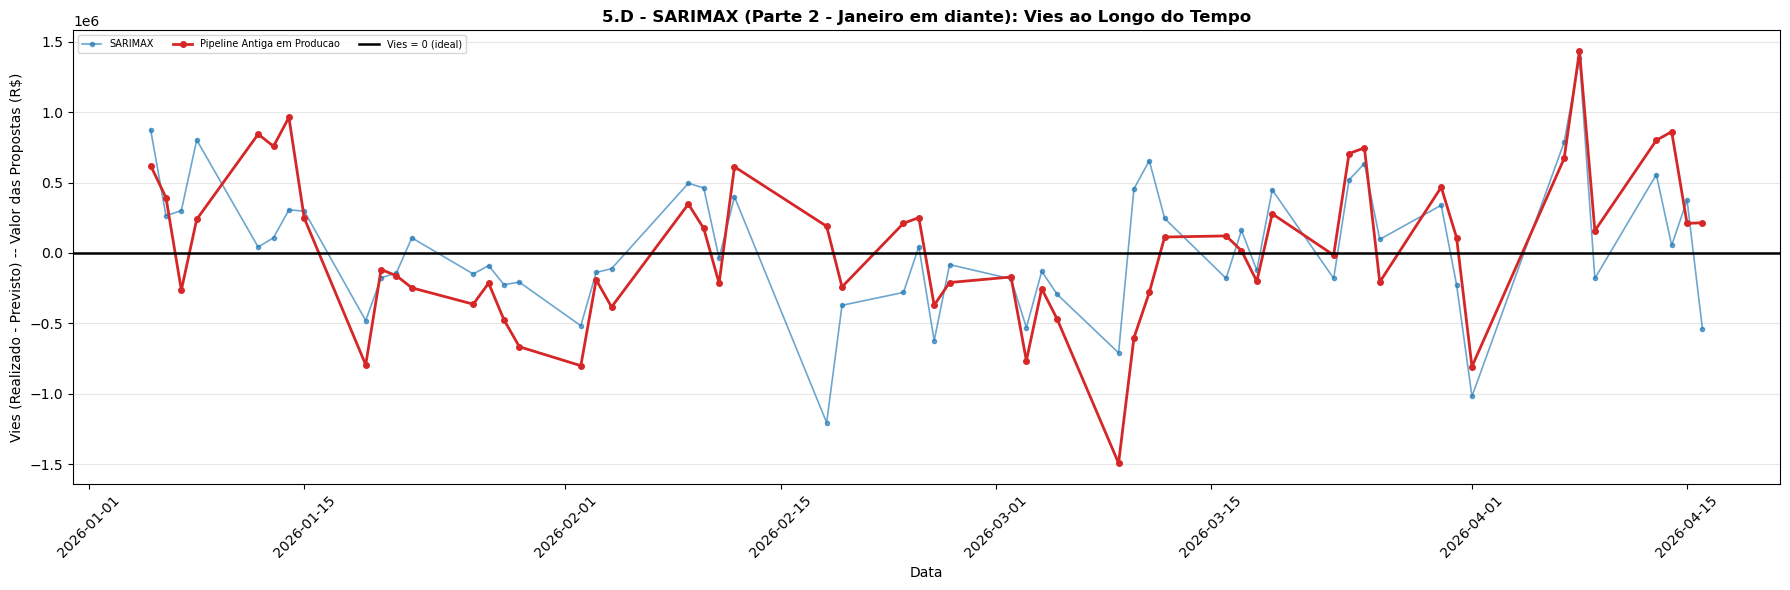


-- Metricas do periodo -- Parte 2 - Janeiro em diante:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SARIMAX,6.81,8.71,0.10,37632.70,37632.70,0.15,370059.00,471285.80,8.62,4.94,0.66,23.75,28/55,43/55,55
1,Pipeline Antiga em Producao,8.02,10.22,-0.17,32006.60,32006.60,-0.19,431761.20,538597.20,9.85,5.17,0.29,34.90,27/55,36/55,55



### 5.D - SARIMAX | Parte 3 - Recorte de marco


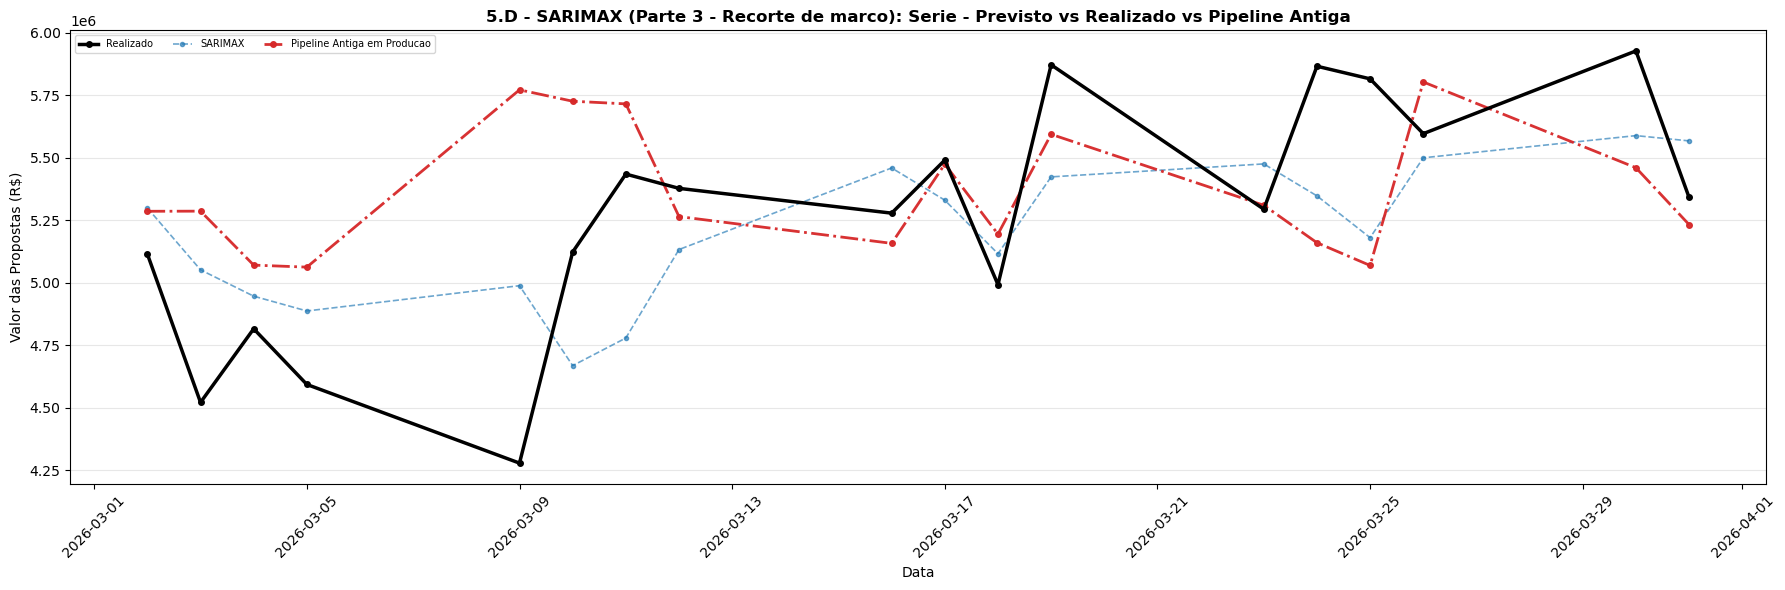

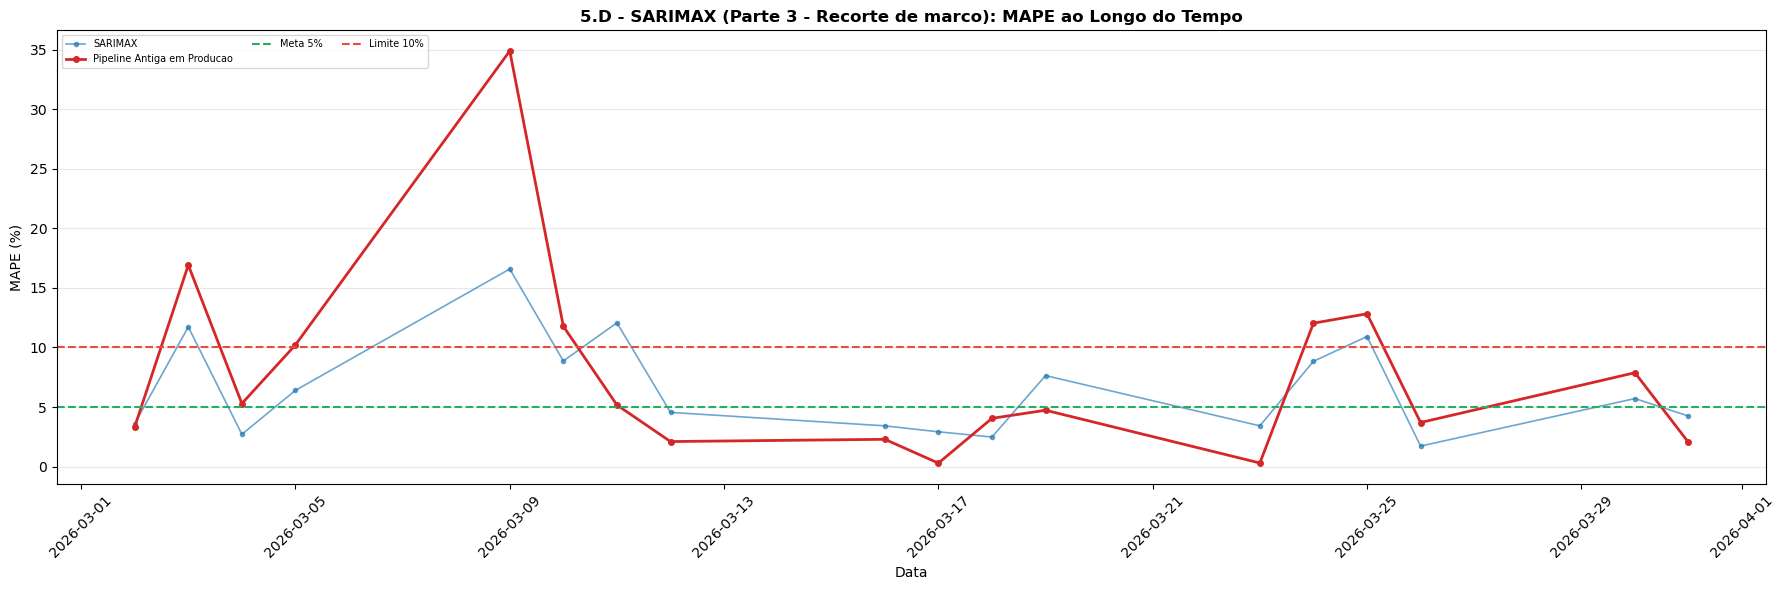

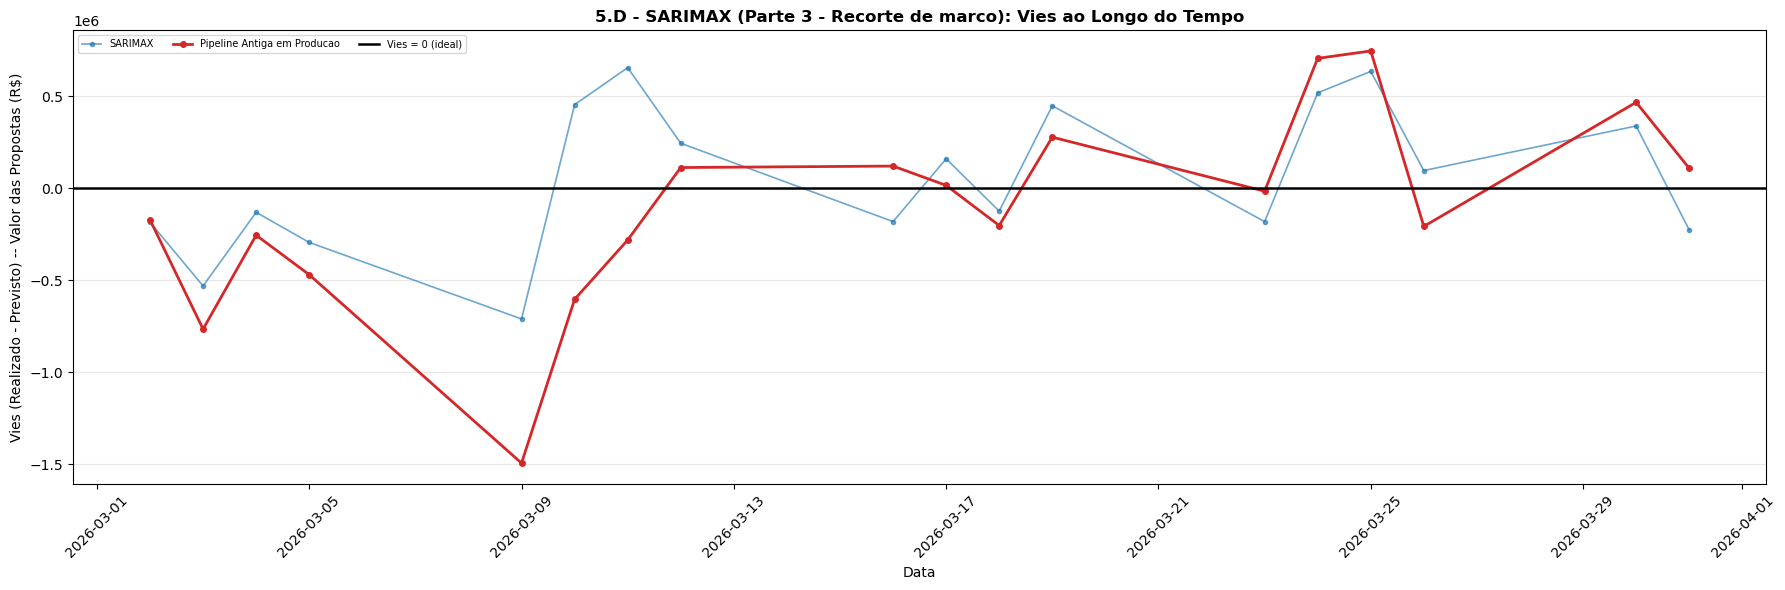


-- Metricas do periodo -- Parte 3 - Recorte de marco:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SARIMAX,6.55,7.70,0.30,55110.40,55110.40,0.48,339647.60,388705.90,7.39,5.13,1.72,16.59,9/18,14/18,18
1,Pipeline Antiga em Producao,7.77,11.18,-0.27,-105895.40,105895.40,-2.86,389934.60,518832.60,9.86,4.95,0.29,34.90,9/18,12/18,18



### 5.D - SARIMAX | Parte 4 - Distribuicoes, RMSPE e trade-off (base completa)


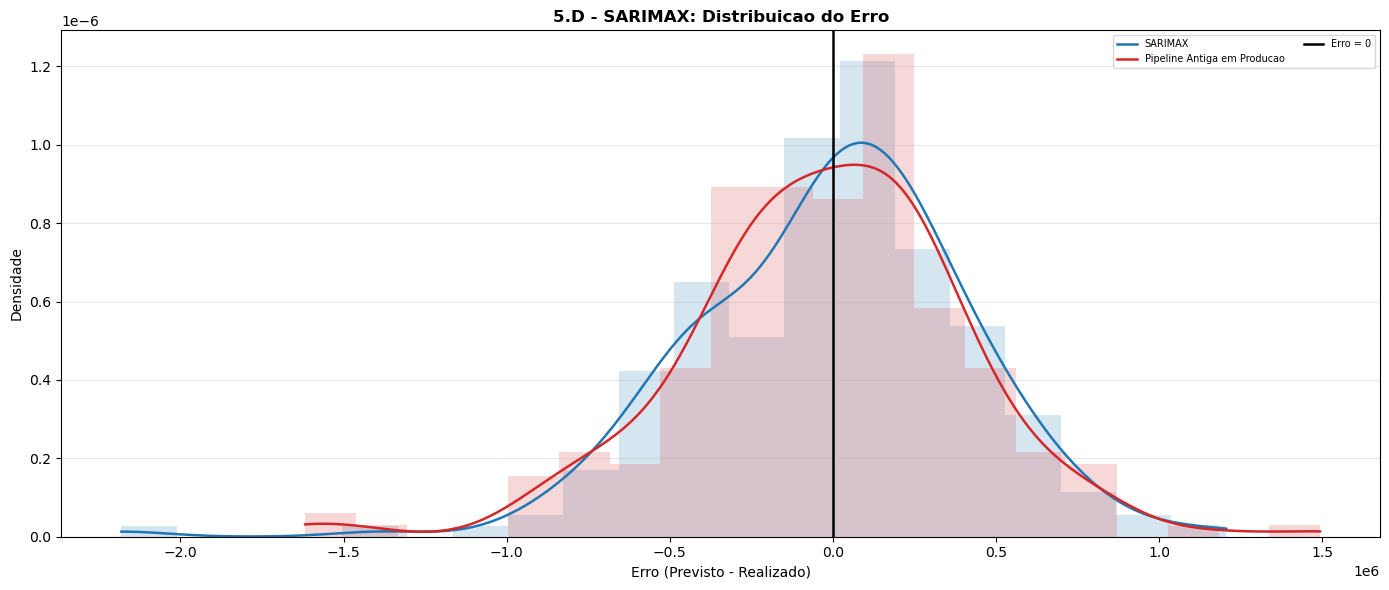

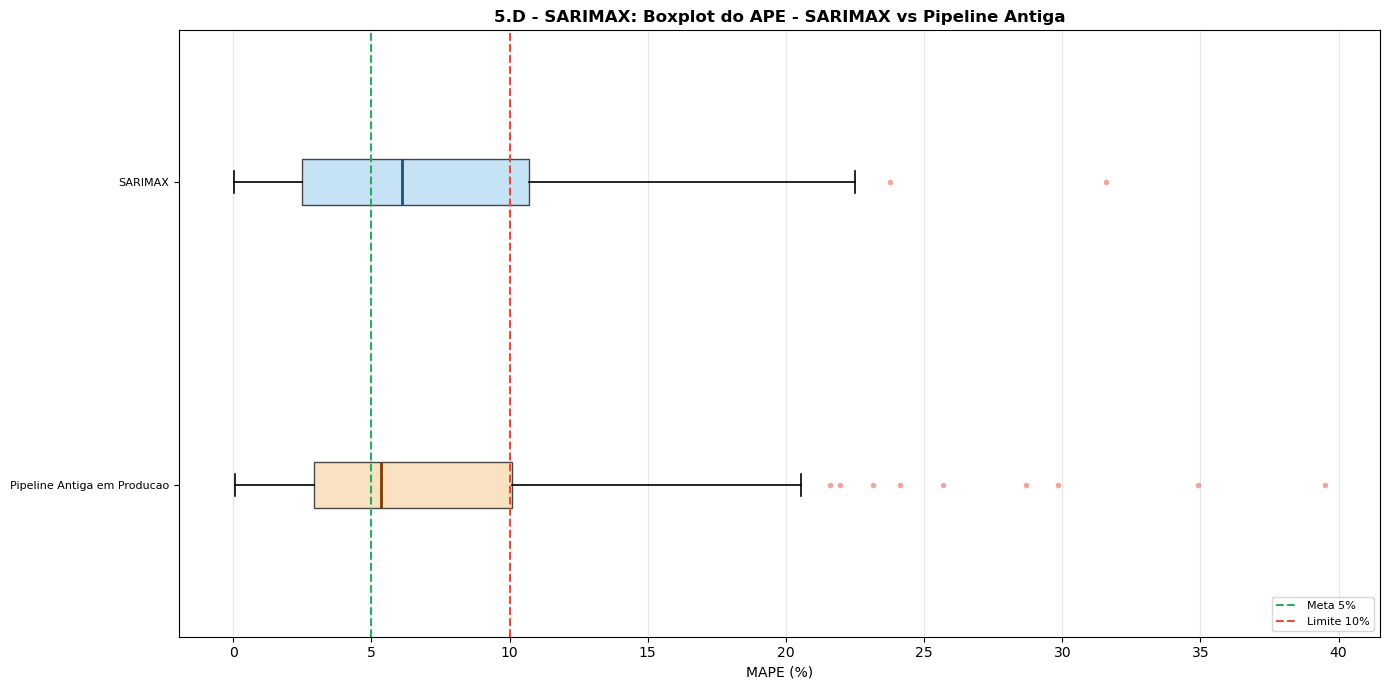

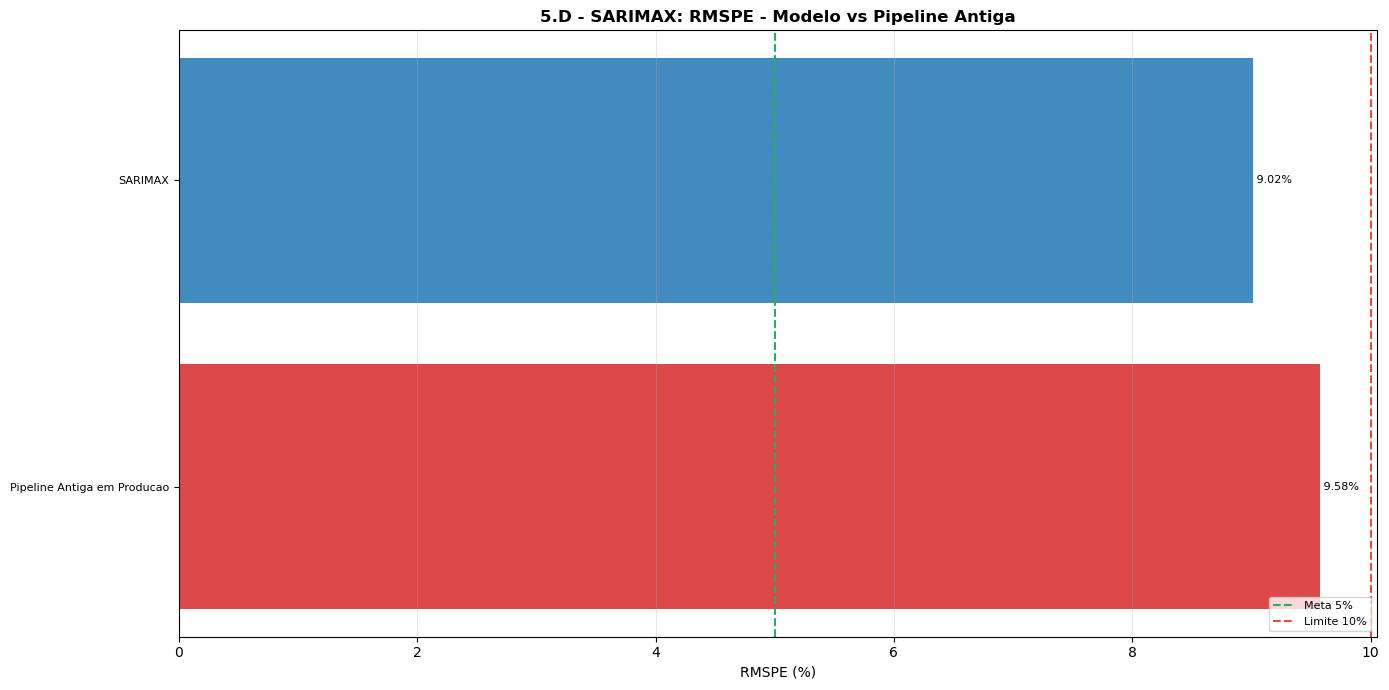

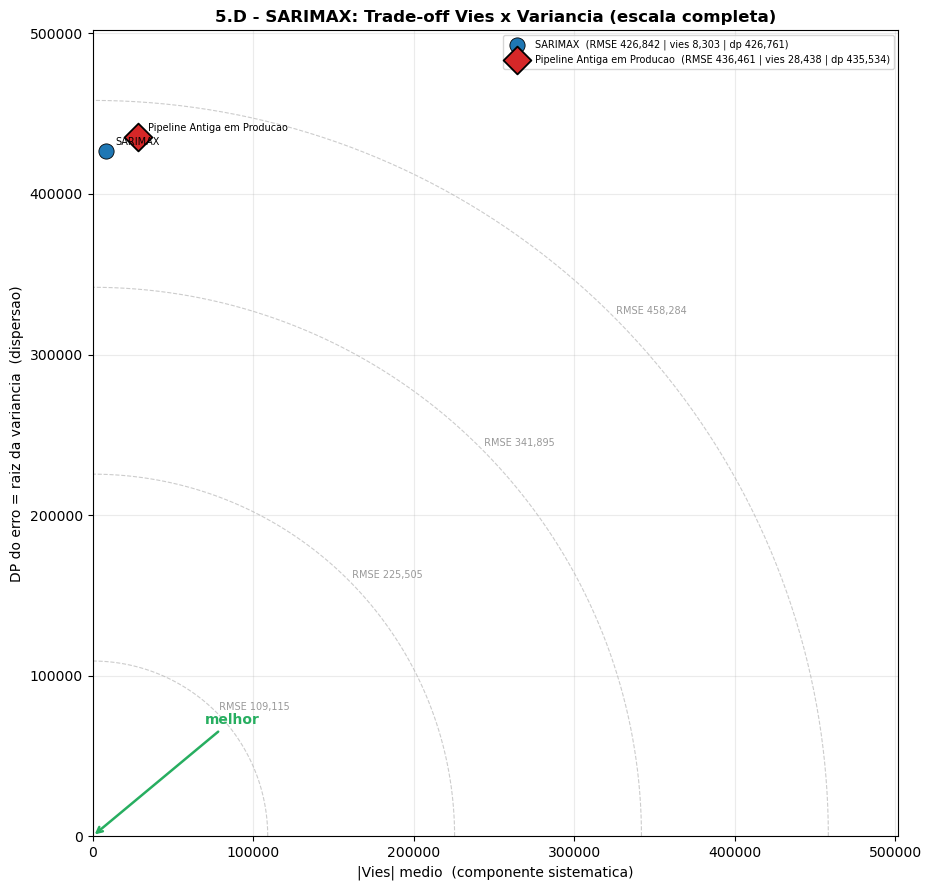


-- Metricas por mes -- SARIMAX:


,Modelo,Mes,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SARIMAX,2025-02,5.08,6.26,-0.17,-92301.50,92301.50,-2.23,227063.90,268674.30,6.16,5.13,0.05,12.92,5/10,9/10,10
1,SARIMAX,2025-03,6.34,8.37,0.72,-104104.30,104104.30,-2.55,242328.70,294104.30,7.26,4.39,0.08,16.66,5/9,7/9,9
2,SARIMAX,2025-04,9.06,10.37,0.01,-84581.70,84581.70,-3.06,317192.60,341327.30,9.41,8.46,0.88,22.15,2/13,8/13,13
3,SARIMAX,2025-05,8.92,10.75,-0.02,-14907.90,14907.90,-1.24,286071.30,347179.70,10.63,6.60,1.42,19.48,6/15,9/15,15
4,SARIMAX,2025-06,8.25,10.21,0.46,116140.50,116140.50,3.09,280378.20,323964.90,9.56,8.19,0.35,22.49,4/13,8/13,13
5,SARIMAX,2025-07,6.70,8.63,0.03,-51862.40,51862.40,-1.78,286719.60,366675.30,8.53,6.03,0.01,20.13,7/17,14/17,17
6,SARIMAX,2025-08,4.42,5.61,0.33,-2119.30,2119.30,-0.23,196689.00,249764.60,5.54,2.89,0.29,11.17,11/16,14/16,16
7,SARIMAX,2025-09,6.50,7.98,0.04,16924.50,16924.50,-0.11,302700.60,378893.50,8.29,6.59,0.44,16.20,7/18,14/18,18
8,SARIMAX,2025-10,5.89,7.52,-0.46,46173.80,46173.80,0.62,287133.60,366687.50,7.64,5.83,0.18,11.50,7/14,9/14,14
9,SARIMAX,2025-11,8.09,9.71,-0.51,-116947.60,116947.60,-2.93,384155.90,435770.10,8.88,6.50,0.82,19.30,4/14,10/14,14


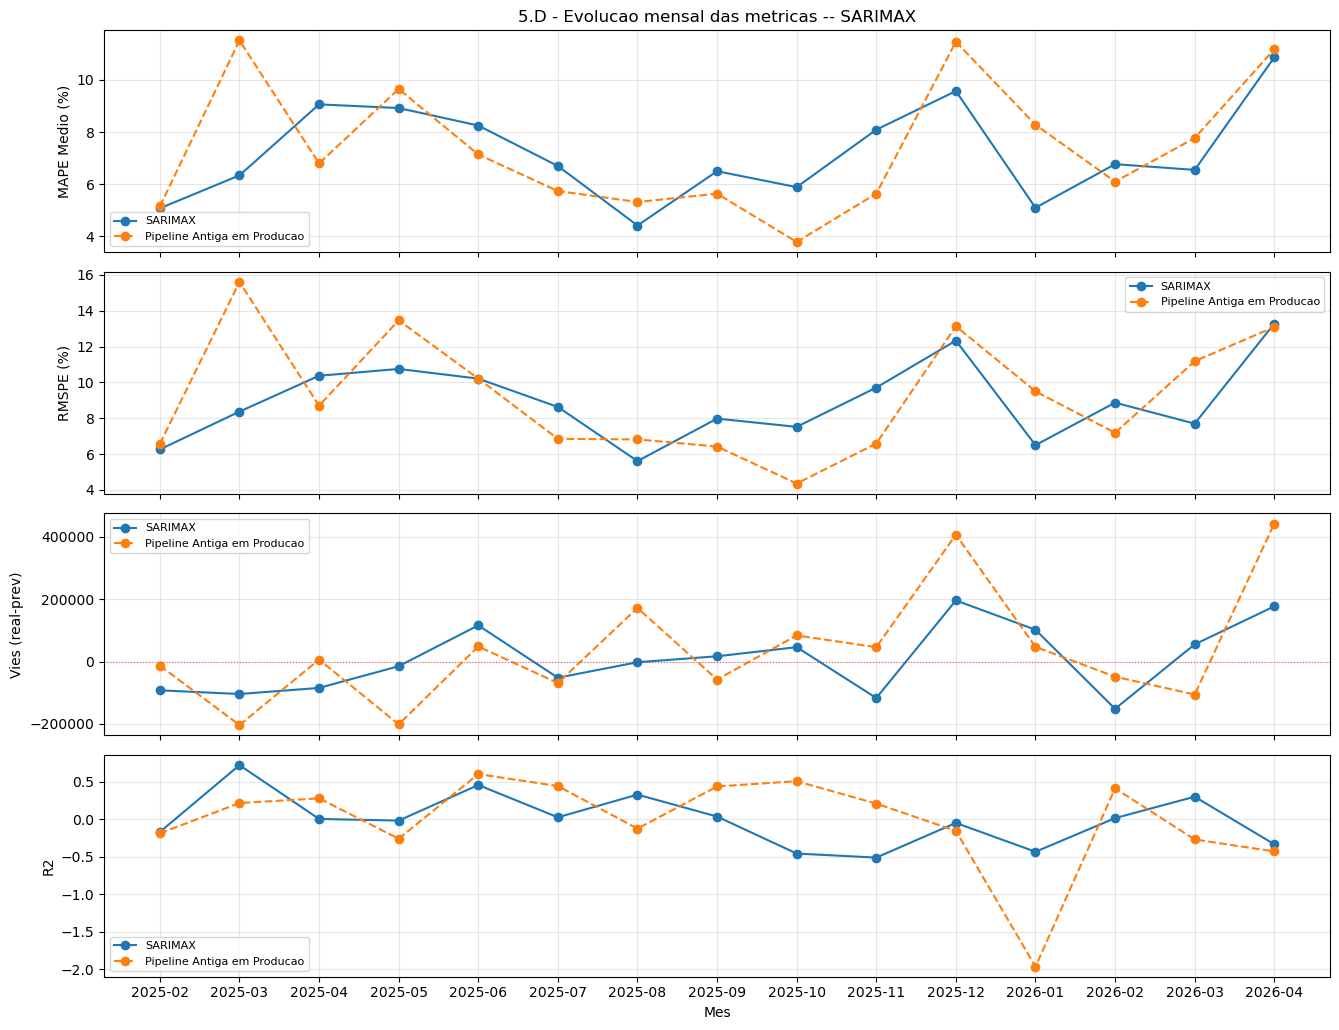

COMPARATIVO  |  SARIMAX   vs   Pipeline Antiga em Producao
Metrica                     Modelo   Pipeline Antiga         Delta   Resultado
------------------------------------------------------------------------------------
MAPE Medio (%)                7.09              7.23         -0.14   melhor
RMSPE (%)                     9.02              9.57         -0.55   melhor
R2                           0.756             0.745         +0.01   melhor
Vies (real-prev)            8302.9           28437.9     -20135.00   
|Vies|                      8302.9           28437.9     -20135.00   melhor
MAE                       324518.2          330068.7      -5550.50   melhor
DP Erro                   426761.2          435533.9      -8772.70   melhor
Mediana (%)                    6.1              5.35         +0.75   pior
N                            209.0             209.0         +0.00   


In [314]:
comparar_modelo('SARIMAX')

#### SARIMA

In [316]:
# comparar_modelo('SARIMA')

### 3.D - Teste exploratorio: `qtd_d1` como covariavel extra no SARIMAX (valor)

Valor e quantidade sao **cointegrados** (Secao 2) -- ou seja, existe um equilibrio de longo
prazo entre as duas series (o ticket medio e estacionario). Isso sugere que a **quantidade do
dia anterior** (`qtd_d1`) pode carregar informacao preditiva sobre o valor alem da que ja vem
de `fila_d1` (fila de analise, etapa 15). Este teste adiciona `qtd_d1` ao SARIMAX de valor e
compara com o modelo atual (so `fila_d1` + dummies de dia da semana), dentro e fora da amostra.

> **Cuidado de amostra:** `serie_q` so comeca em mai/2025 (bem mais curta que `serie_v`, que
> comeca em nov/2024). O teste restringe AMBOS os modelos ao periodo comum (`idx_comum`) para
> a comparacao ser justa -- caso contrario a diferenca de N inflaria/desinflaria as metricas
> por causa do periodo, nao da covariavel.

In [ ]:
# ===== Teste exploratorio: qtd_d1 como covariavel extra no SARIMAX (valor) =====
qtd_d1 = serie_q.shift(1).rename('qtd_d1')
exog_v_qtd  = exog_v.join(qtd_d1, how='inner').dropna()
idx_comum   = exog_v_qtd.index
print(f'Periodo comum p/ o teste: {idx_comum.min().date()} -> {idx_comum.max().date()} | '
      f'N={len(idx_comum)}  (serie_v completa tem N={len(serie_v)})')

serie_v_c   = serie_v.loc[idx_comum]
exog_v_base = exog_v.loc[idx_comum]   # baseline (fila_d1 + dow), MESMA amostra restrita

res_base = ajustar_sarimax(serie_v_c, order_v, seas_v, exog_v_base)
res_qtd  = ajustar_sarimax(serie_v_c, order_v, seas_v, exog_v_qtd)

print('\n--- Baseline (fila_d1 + dow), amostra restrita ao periodo comum ---')
print(f'AIC={res_base.aic:.1f} | BIC={res_base.bic:.1f}')
print('\n--- + qtd_d1 ---')
print(res_qtd.summary().tables[1])
print(f'AIC={res_qtd.aic:.1f} | BIC={res_qtd.bic:.1f}  '
      f'(delta AIC={res_qtd.aic - res_base.aic:+.1f}, delta BIC={res_qtd.bic - res_base.bic:+.1f})')

_p_qtd = float(res_qtd.pvalues.get('qtd_d1', np.nan))
_c_qtd = float(res_qtd.params.get('qtd_d1', np.nan))
print(f'\nqtd_d1: coef={_c_qtd:.4f} | p={_p_qtd:.4f} ->',
      'SIGNIFICATIVO (p<0.05)' if _p_qtd < 0.05 else 'NAO significativo')

In [ ]:
# ----- Comparacao out-of-sample (walk-forward), mesma janela de avaliacao do ranking oficial -----
datas_eval_qtd = sorted(
    d for d in set(_df_db_valor.loc[_df_db_valor['Modelo'] == 'SARIMAX', 'Dia Prevista'])
    if d in idx_comum
)
print(f'Datas de avaliacao (interseccao c/ ranking oficial + periodo comum de qtd_d1): '
      f'N={len(datas_eval_qtd)}')

X_int_c = (X_int_sarimax_v.loc[X_int_sarimax_v.index.isin(idx_comum)]
           if X_int_sarimax_v is not None else None)

det_base = walk_forward(serie_v_c, order_v, seas_v, exog_v_base, datas_eval_qtd, exog_int=X_int_c)
det_base['Modelo'] = 'SARIMAX (atual)'
det_qtd  = walk_forward(serie_v_c, order_v, seas_v, exog_v_qtd,  datas_eval_qtd, exog_int=X_int_c)
det_qtd['Modelo']  = 'SARIMAX + qtd_d1'

_cmp = pd.DataFrame({m: _linha_rank(g) for m, g in
                     pd.concat([det_base, det_qtd], ignore_index=True).groupby('Modelo')}).T
_cmp = _cmp.sort_values('RMSPE (%)')
display(_com_modelo(_cmp))

_delta_rmspe = float(_cmp.loc['SARIMAX + qtd_d1', 'RMSPE (%)']) - float(_cmp.loc['SARIMAX (atual)', 'RMSPE (%)'])
print(f"\nDelta RMSPE (+qtd_d1 - atual) = {_delta_rmspe:+.2f} p.p. ->",
      'qtd_d1 MELHORA o modelo out-of-sample' if _delta_rmspe < 0 else 'qtd_d1 NAO melhora (ou piora)')

## 4 - AREA QUANTIDADE

### 4.A Estimação

Ordem (auto_arima, univariado): SARIMA(0, 1, 1) x (0, 0, 2, 5)  | AIC=5916.2
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8177      0.033    -24.832      0.000      -0.882      -0.753
ma.S.L5       -0.0991      0.048     -2.073      0.038      -0.193      -0.005
ma.S.L10      -0.0680      0.058     -1.165      0.244      -0.182       0.046
sigma2      1.101e+05   5160.098     21.329      0.000    9.99e+04     1.2e+05


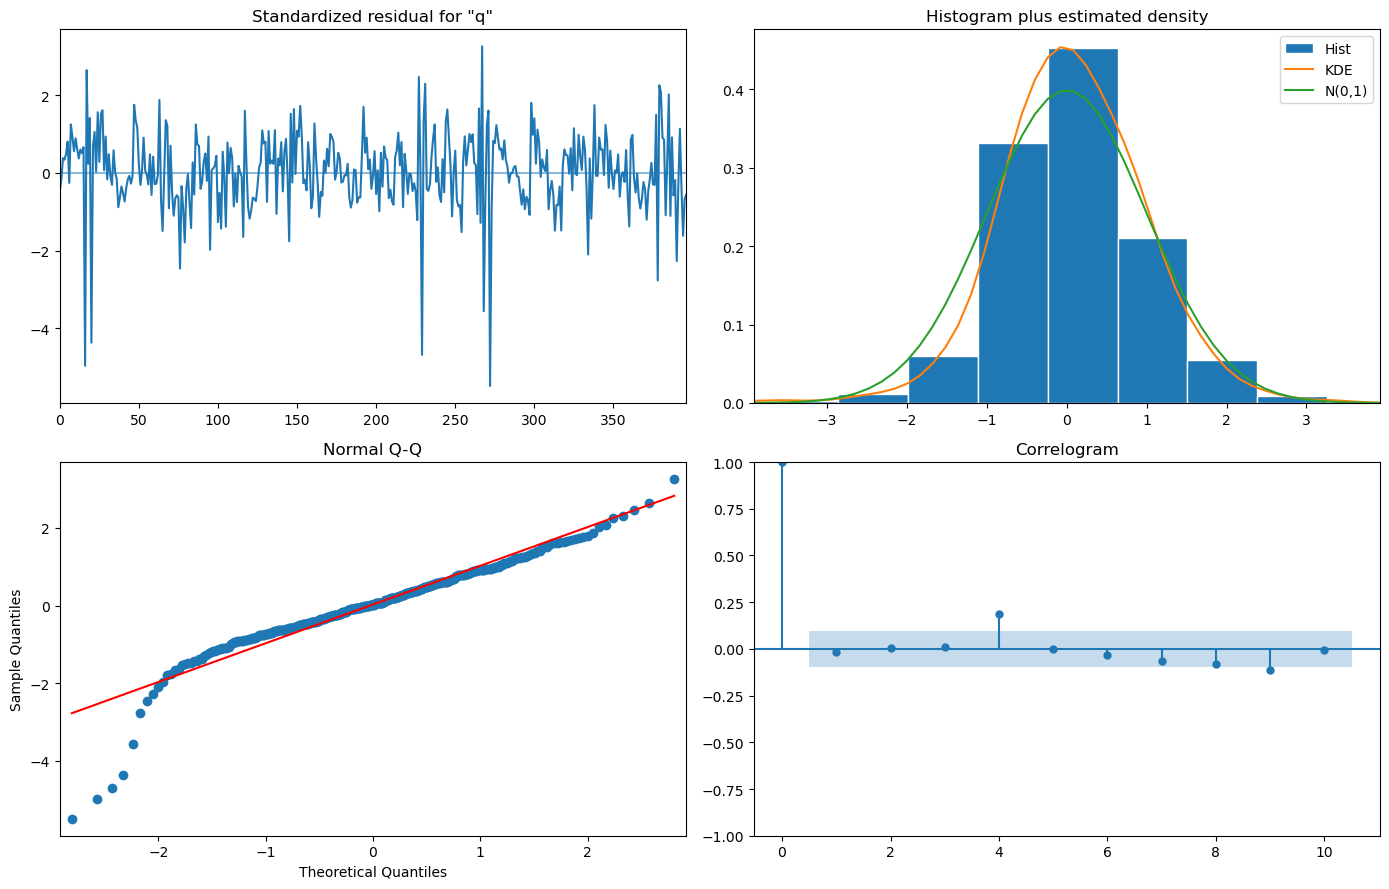

Ljung-Box (H0 = residuos sem autocorrelacao):
    lb_stat  lb_pvalue
10    18.82       0.04
20    40.37       0.00


In [318]:
order_q, seas_q, aic_q = selecionar_ordem(serie_q)
print(f'Ordem (auto_arima, univariado): SARIMA{order_q} x {seas_q}  | AIC={aic_q:.1f}')
res_q = ajustar_sarimax(serie_q, order_q, seas_q, None)
print(res_q.summary().tables[1])
try:
    res_q.plot_diagnostics(figsize=(14, 9)); plt.tight_layout(); plt.show()
except Exception as e:
    print('diagnostics:', e)
print('Ljung-Box (H0 = residuos sem autocorrelacao):')
print(acorr_ljungbox(res_q.resid, lags=[10, 20], return_df=True))

### Analise de intervencao (efeito por evento + residuo pre/pos)

Efeito dos **dias especiais** (eventos do `Log_Erro` e vesperas de feriado) sobre a serie de
quantidade, via **regressores de intervencao** (Box-Tiao) ja montados acima. Cada evento e
classificado em **abrupto** (efeito transitorio, constante nos dias de impacto) ou **gradual**
(efeito decaindo ao longo da janela de impacto), escolhendo por significancia (p<0.05) e menor
AIC; sem efeito significativo -> `nao signif.`. Abaixo: tabela por evento, barra de efeito
(SARIMAX) e comparacao do **residuo PRE x POS** intervencao (ajuste SARIMA univariado).

=== Analise classica: Quantidade de Propostas | n=410 | 2024-11-11 -> 2026-07-02 ===


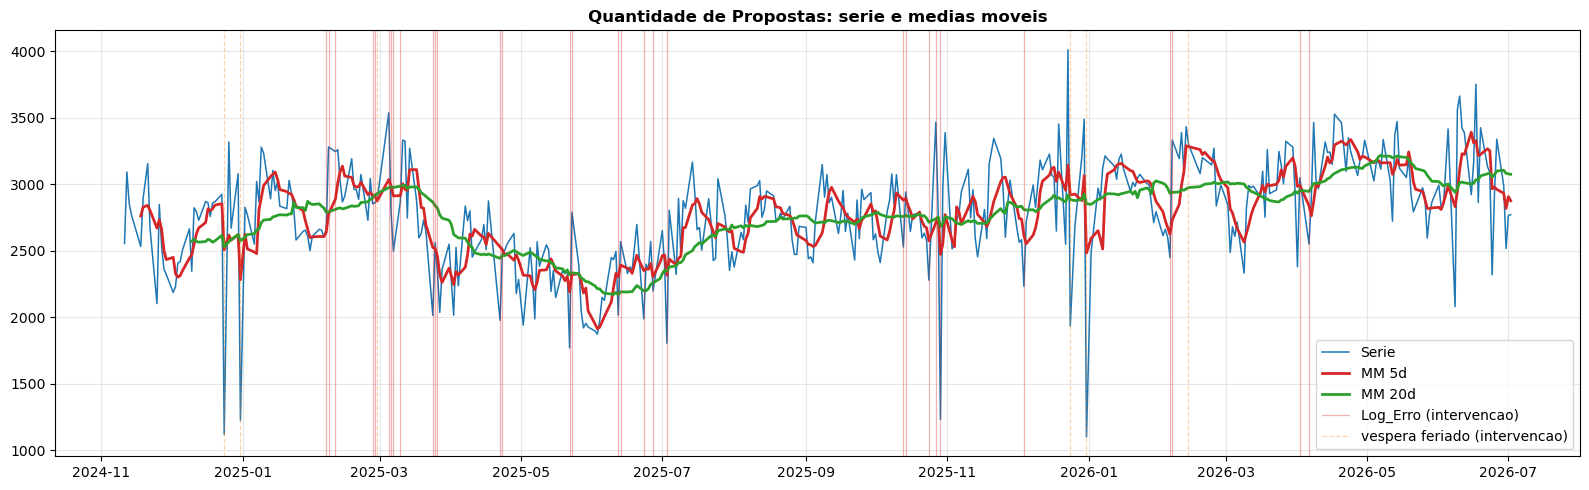

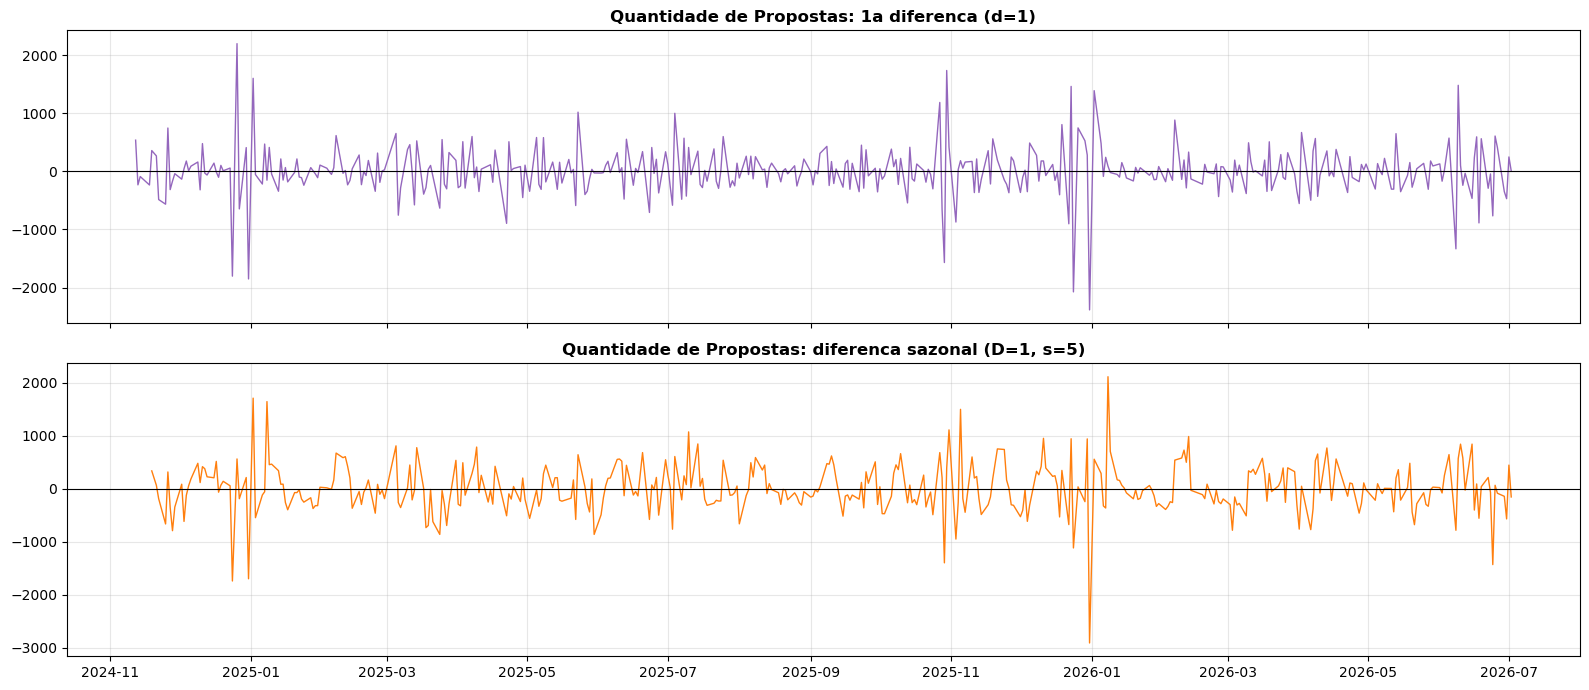

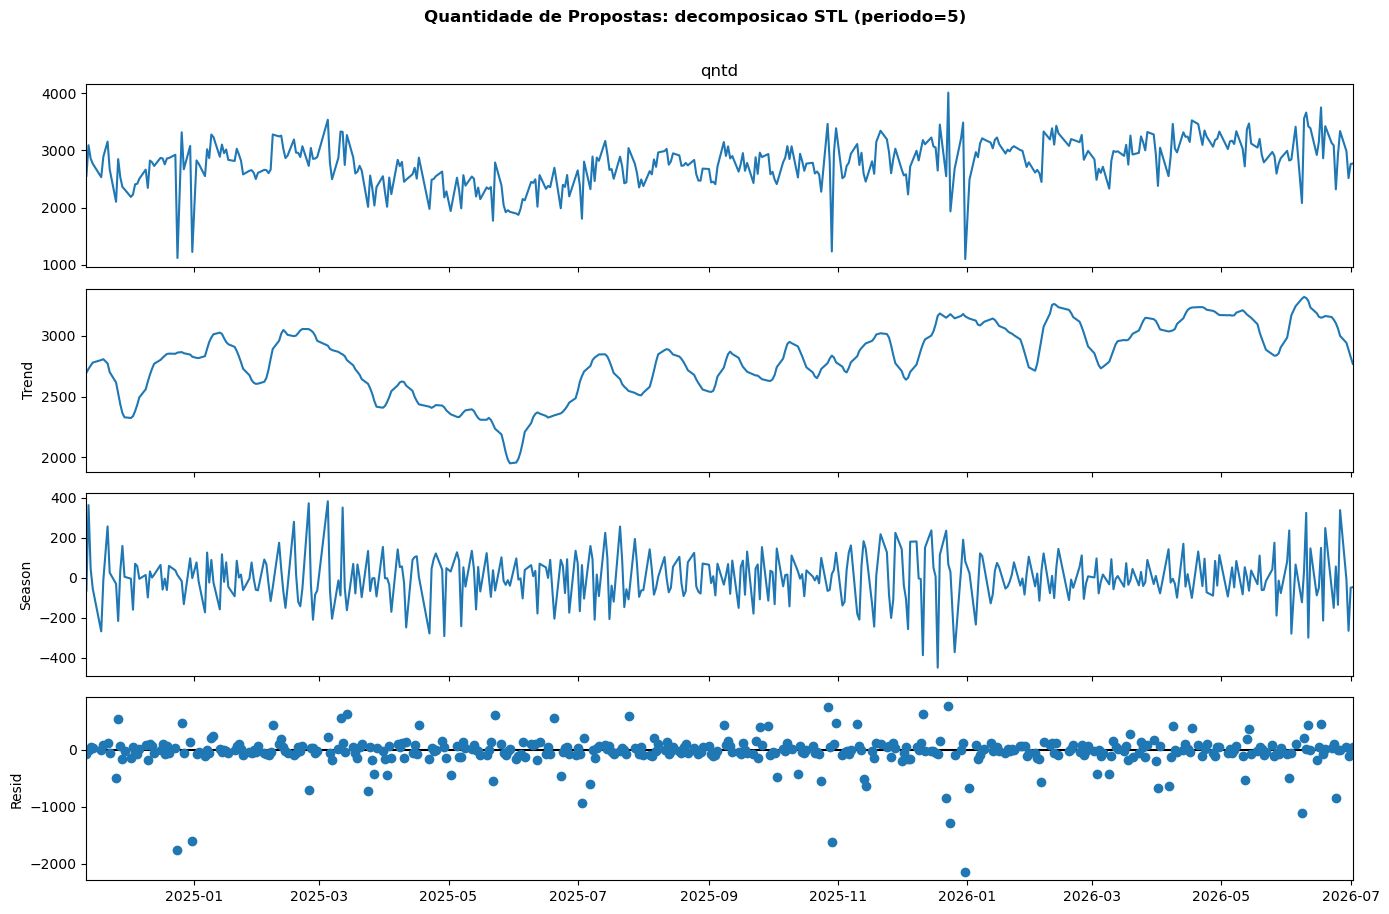

Estacionariedade (ADF H0=raiz unitaria | KPSS H0=estacionaria) -- ADF bruto x ajustado p/ intervencao (37 dias atipicos: Log_Erro + vespera Natal/AnoNovo/Carnaval):
  nivel              ADF bruto p=0.5129 (NAO estac.)  |  ADF ajustado p=0.0005 (estacionaria)  |  KPSS (bruto) p=0.0100 (NAO estac.)
  1a diferenca       ADF bruto p=0.0000 (estacionaria)  |  ADF ajustado p=0.0000 (estacionaria)  |  KPSS (bruto) p=0.1000 (estacionaria)
  diff sazonal(5)    ADF bruto p=0.0000 (estacionaria)  |  ADF ajustado p=0.0000 (estacionaria)  |  KPSS (bruto) p=0.1000 (estacionaria)


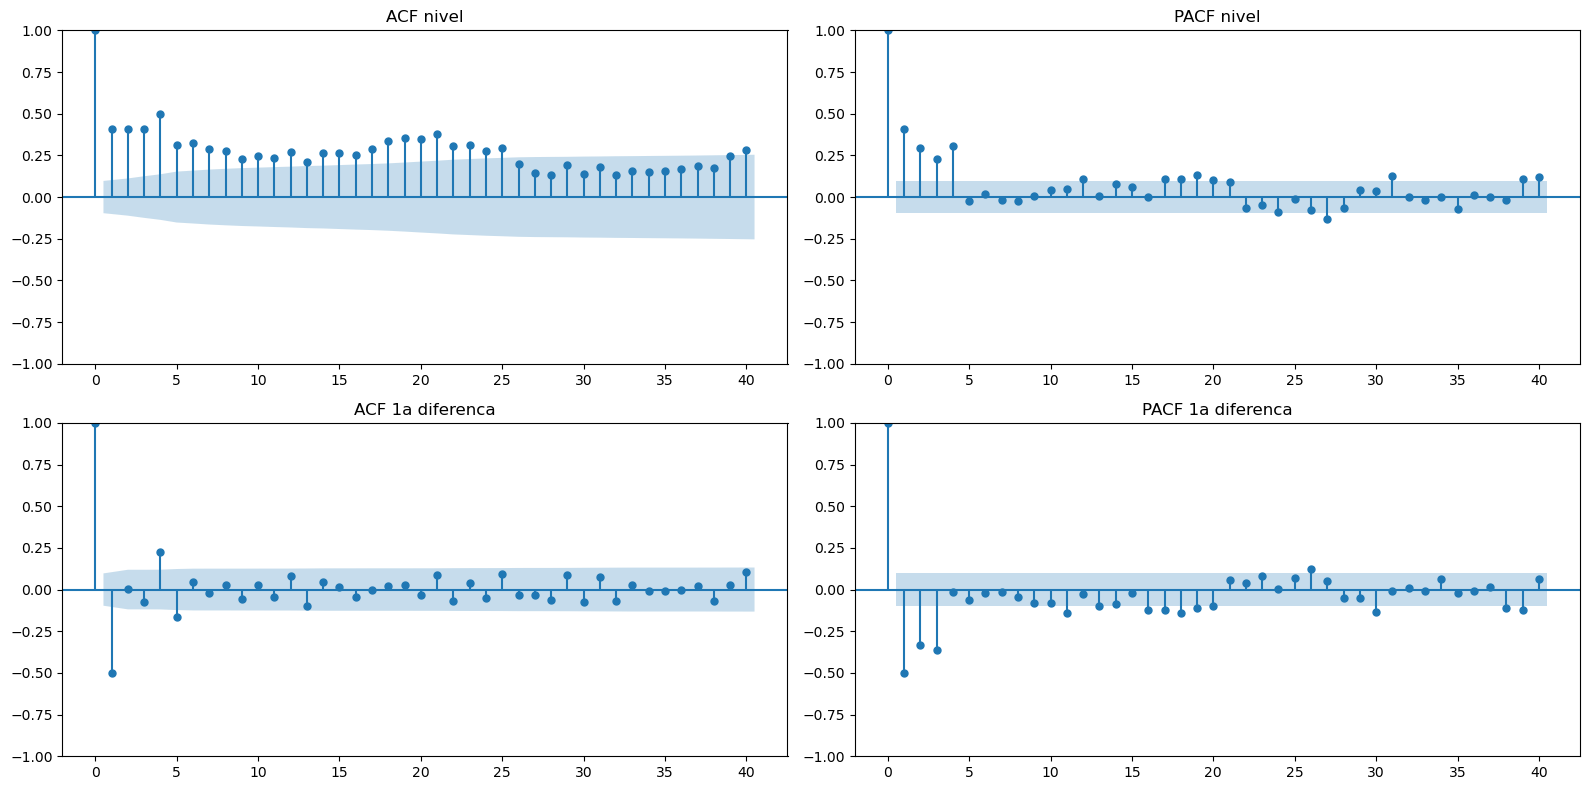

[cache saved] analise_intervencao -> analise_intervencao_e40a79e4066f1ade.pkl
[cache saved] analise_intervencao -> analise_intervencao_430503a58dee51ef.pkl

Quantidade de Propostas | SARIMA {'nao signif.': 15, 'abrupto': 3} -> 3 regressores | SARIMAX {'abrupto': 7, 'gradual': 6, 'nao signif.': 3, 'rebote': 2} -> 17 regressores

Tabela de intervencao -- Quantidade de Propostas / SARIMAX:


,Evento,Tipo,Inicio,n_dias,Impacto/dias,coef_abrupto,p_abrupto,AIC_abrupto,coef_gradual,p_gradual,AIC_gradual,coef_rebote_dia1,coef_rebote_pos,p_rebote_dia1,p_rebote_pos,AIC_rebote,Classe
0,vespera relevante Natal/AnoNovo/Carnaval (n=6),vespera,2024-12-24,6,1,-922.10,0.00,5718.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,abrupto
1,BrSCAM (2025-02-06),log_erro,2025-02-06,3,3,24.40,0.96,5793.40,-156.50,0.00,5793.70,-152.40,200.90,0.20,0.50,5793.40,gradual
2,CrefazOn (2025-02-26),log_erro,2025-02-26,2,2,0.60,1.00,5793.50,18.30,0.00,5793.60,18.30,-17.00,0.00,0.00,5795.50,gradual
3,Carnaval (2025-03-05),log_erro,2025-03-05,2,2,762.70,0.00,5790.00,895.60,0.08,5786.00,895.30,628.20,0.00,0.01,5789.70,abrupto
4,Bacen - Fila Pagamento (2025-03-07),log_erro,2025-03-07,2,2,-765.30,0.00,5786.50,-839.90,0.00,5785.90,-842.00,-687.80,0.00,0.00,5788.10,gradual
5,Enel - Mega (2025-03-24),log_erro,2025-03-24,3,3,-120.00,0.49,5793.00,-461.90,0.19,5791.80,-383.50,143.50,0.27,0.69,5792.50,nao signif.
6,CrefazOn (2025-04-22),log_erro,2025-04-22,2,2,-502.10,0.12,5790.30,-676.60,0.00,5788.20,-676.60,-328.30,0.00,0.00,5790.20,gradual
7,Kamunda- Enel (2025-05-22),log_erro,2025-05-22,2,2,-287.70,0.37,5794.70,-636.50,0.00,5794.10,-636.90,65.50,0.00,0.00,5791.60,rebote
8,Unico - CrefazOn (2025-06-12),log_erro,2025-06-12,2,2,-240.00,0.66,5793.40,-409.80,0.00,5793.20,-410.00,-69.40,0.00,0.00,5794.80,gradual
9,Code-Mega (2025-06-23),log_erro,2025-06-23,1,1,-382.20,0.00,5791.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,abrupto


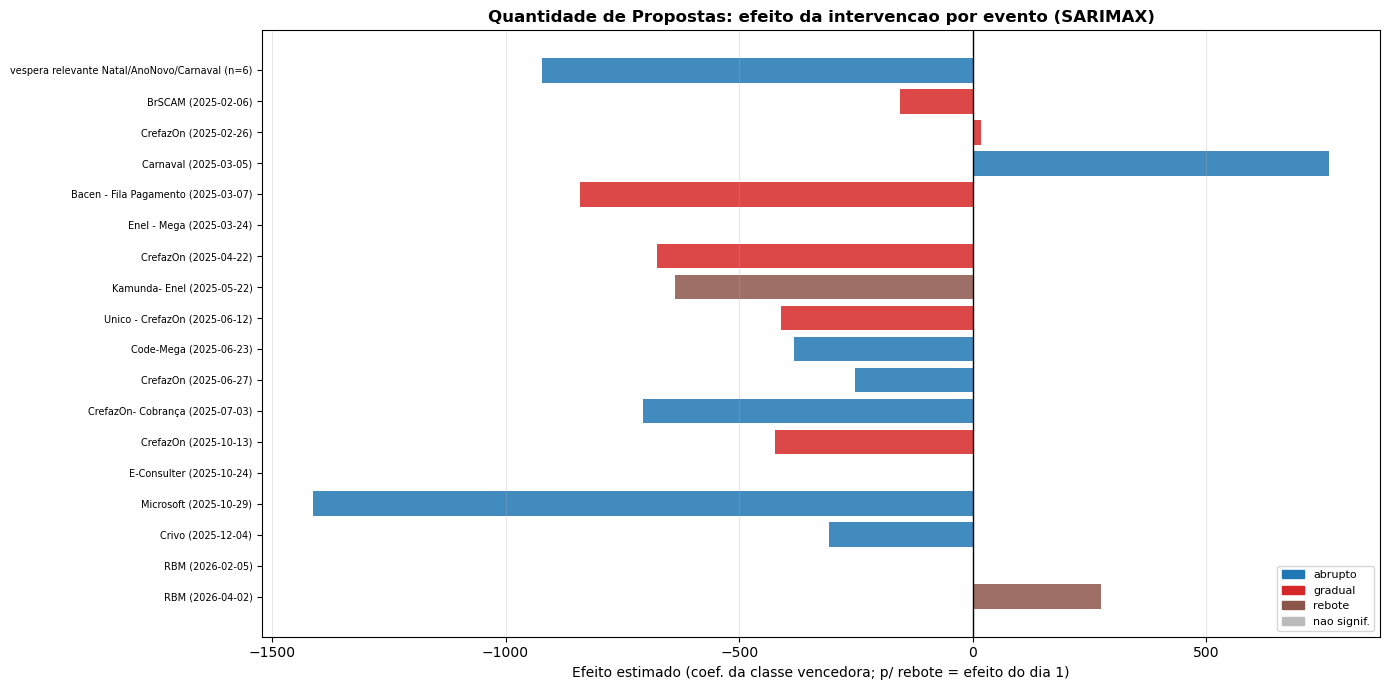

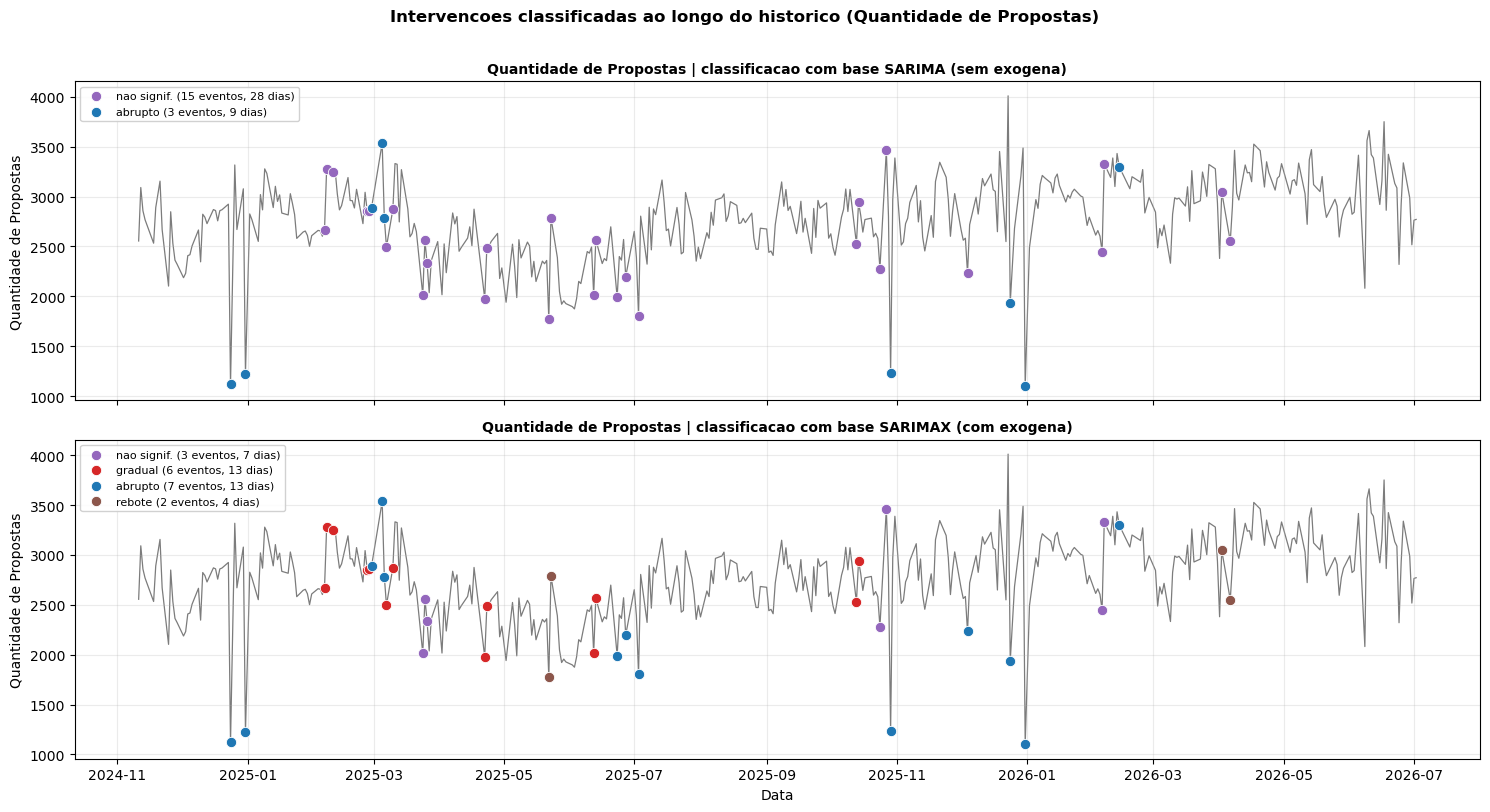

RESIDUO PRE x POS INTERVENCAO -- Quantidade de Propostas -- SARIMA


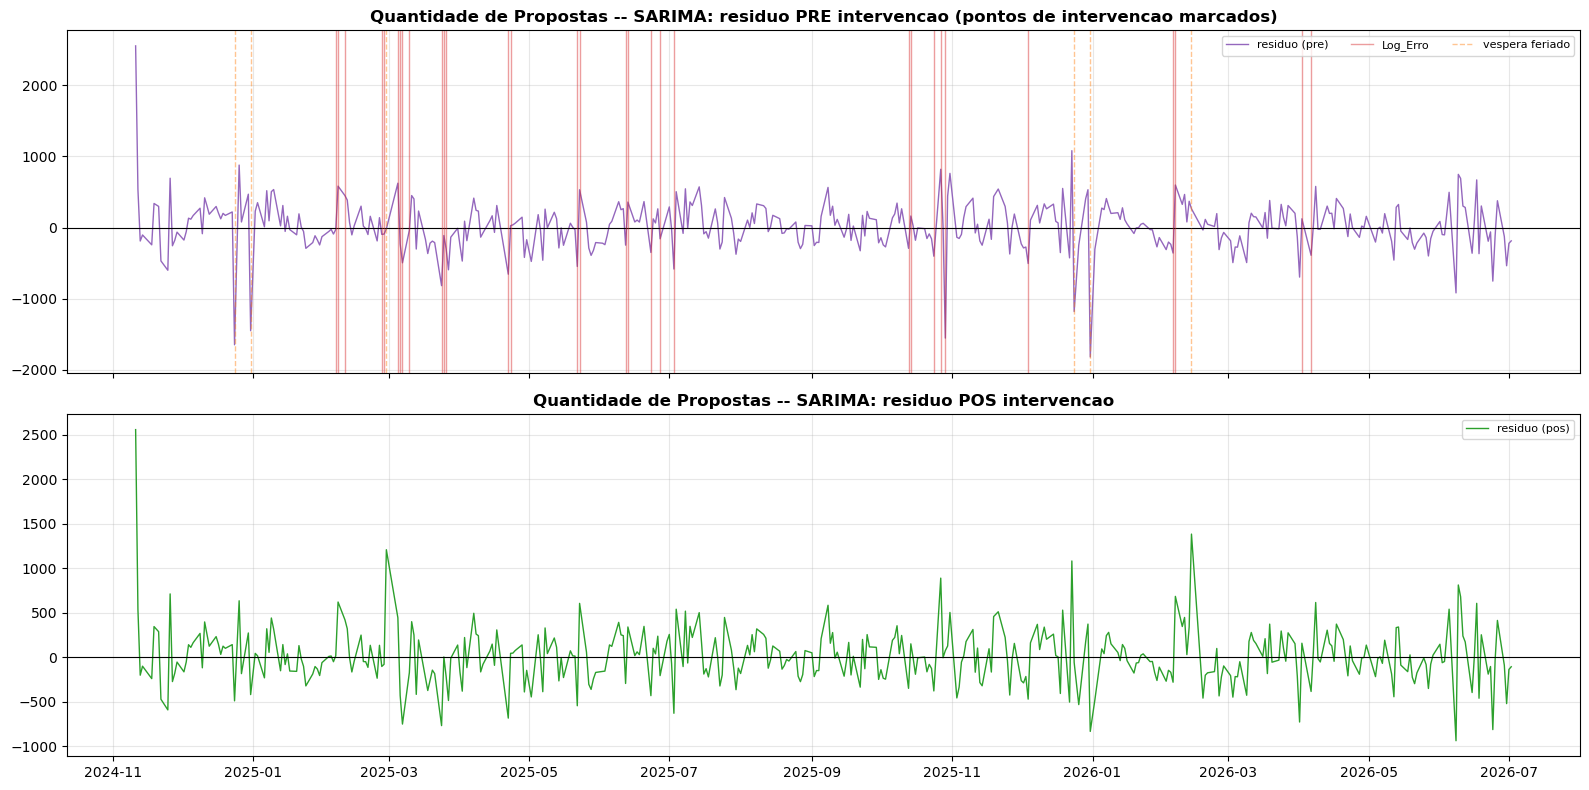

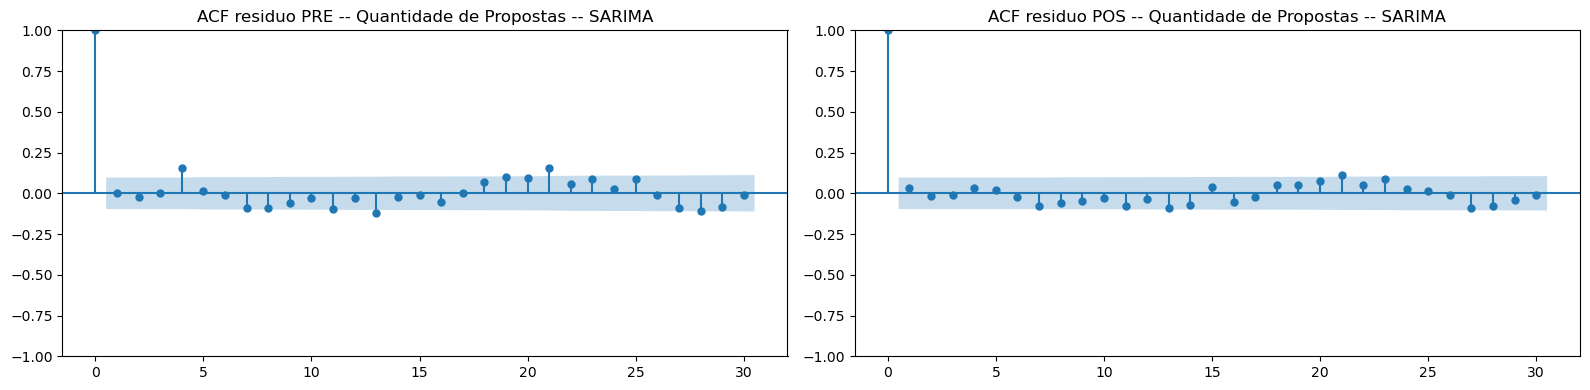

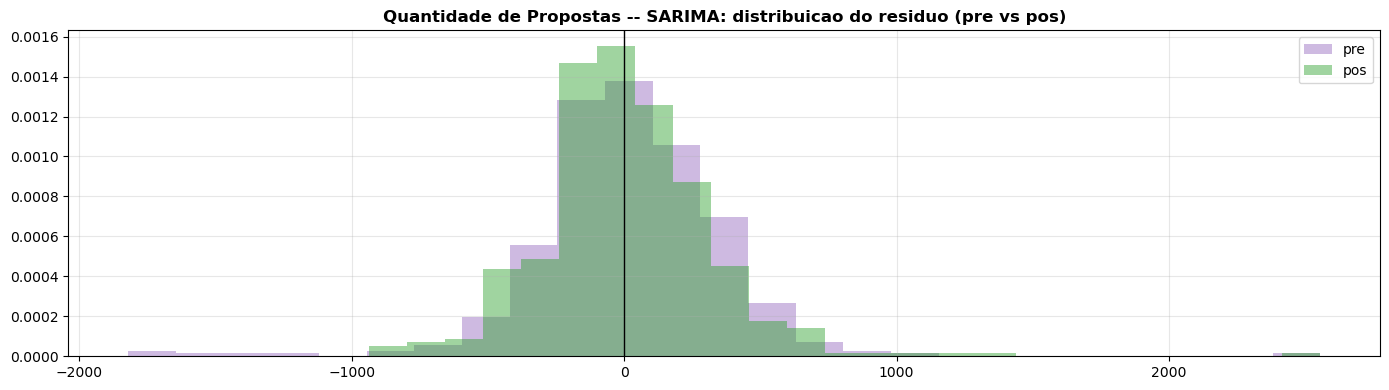

Resumo do residuo (pre vs pos):


,Modelo,n,AIC,BIC,DP residuo,MAE residuo,LB p(10),LB p(20),JB p (normal.)
0,PRE (sem intervencao),410,5742.50,5758.50,355.28,245.66,0.04,0.00,0.00
1,POS (com intervencao),410,5654.30,5682.10,322.46,229.66,0.73,0.34,0.00


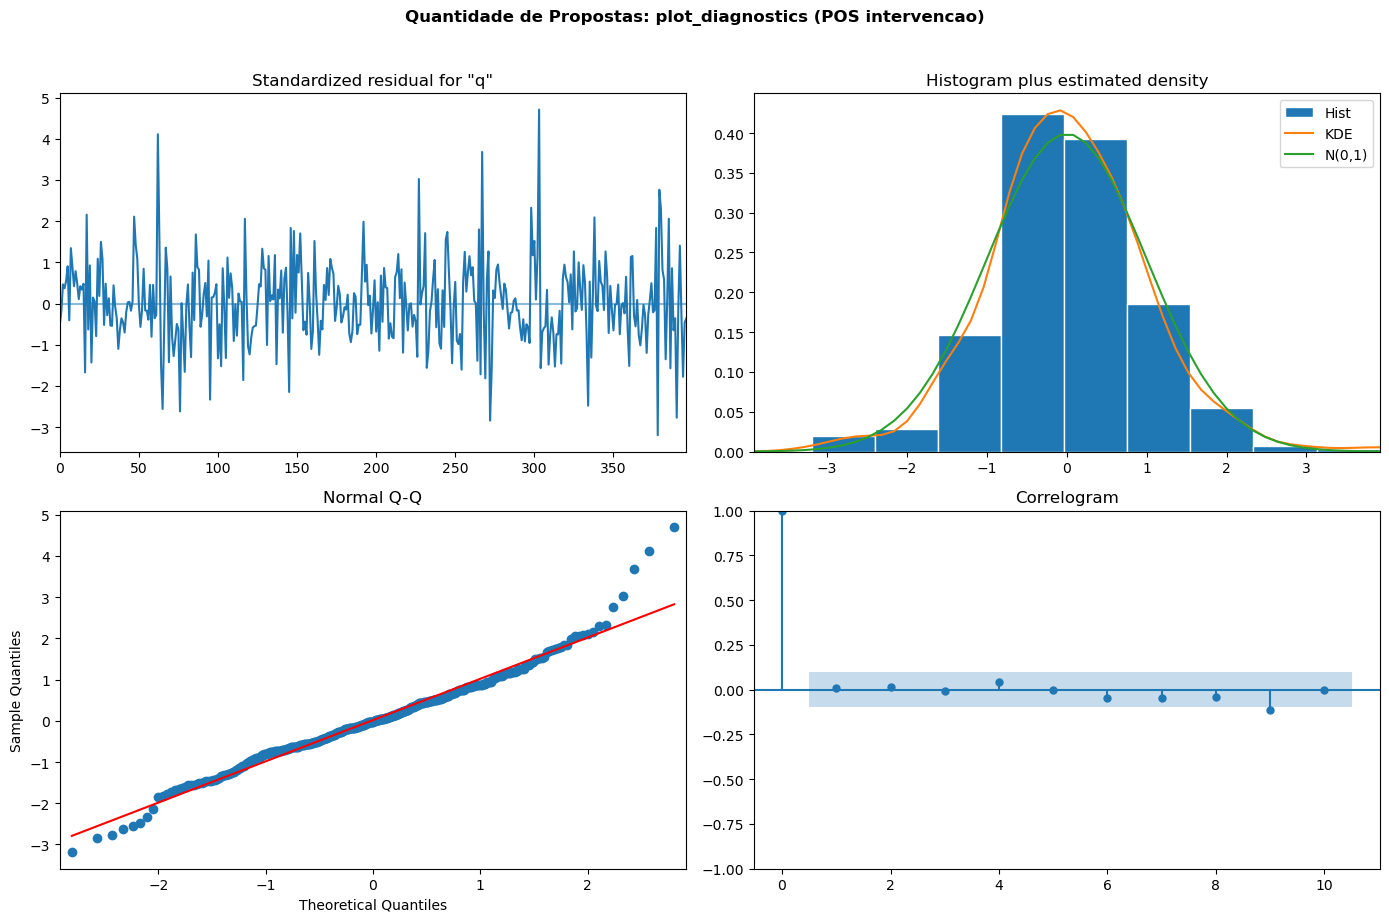


Ljung-Box (POS intervencao) -- Quantidade de Propostas (H0 = residuos sem autocorrelacao):
    lb_stat  lb_pvalue
10     6.90       0.73
20    22.06       0.34


In [319]:
# ===== Analise classica + intervencao -- QUANTIDADE =====
# analise_classifica_intervencao junta: (1) analise classica (medias moveis, STL, ADF/KPSS,
# ACF/PACF), (2) classificacao da intervencao por evento -- SARIMA e SARIMAX -- + onde cada
# uma cai no historico, e (3) residuo PRE (sem intervencao) x POS (com intervencao). As
# matrizes X_int_* seguem sendo usadas na avaliacao (Secao 4) e na correcao de vies.
resultado_q = analise_classifica_intervencao(serie_q, order_q, seas_q, eventos_q,
                                             nome='Quantidade de Propostas', exog=exog_q, res_pre=res_q)
interv_sarima_q,  classes_sarima_q,  X_int_sarima_q  = (resultado_q['interv_sarima'],
                                                        resultado_q['classes_sarima'], resultado_q['X_int_sarima'])
interv_sarimax_q, classes_sarimax_q, X_int_sarimax_q = (resultado_q['interv_sarimax'],
                                                        resultado_q['classes_sarimax'], resultado_q['X_int_sarimax'])

In [ ]:
_df_db_qtd, ranking_qtd = avaliar_area(
    'qntd', serie_q, exog_q, order_q, seas_q,
    'resultados/backup_qtd.xlsx', 'Data previsao', dfull_q,
    exog_int_u=X_int_sarima_q, exog_int_x=X_int_sarimax_q,
    eventos=eventos_q, interv_lr=interv_sarima_q)   # inclui LOG-RETORNO no ranking
print('\nRanking QUANTIDADE (ordenado por RMSPE):')
display(_com_modelo(ranking_qtd))

### 4.D - Outras funcoes de transferencia (Box-Tiao)

Mesmas funcoes (b) pulso atrasado+decaimento, (c) degrau permanente, (d) decaimento+degrau,
(e) pico+decaimento e (f) convergencia gradual descritas na Secao 3.E, aplicadas aqui a serie
de quantidade.


In [ ]:
# ===== Outras funcoes de transferencia (Box-Tiao) -- QUANTIDADE =====
interv_trf_q = analise_transferencia(serie_q, order_q, seas_q, eventos_q, exog=exog_q, verbose=True)
print('\nComparacao: classe (abrupto/gradual/rebote) x funcao vencedora (a-f):')
_comp_q = interv_sarimax_q[['Evento', 'Classe']].merge(
    interv_trf_q[['Evento', 'Classe_vencedora']], on='Evento', how='outer')
display(_comp_q)
display(interv_trf_q)
_plot_transferencia(interv_trf_q, title='QUANTIDADE: outras funcoes de transferencia -- efeito por evento')
